# Asset Failure - Survival Model - EDA
#### Author - Abhinav Paul

In [5]:
!pip install pandas numpy matplotlib seaborn lifelines scikit-survival

In [6]:
# Core
import pandas as pd
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", None)

import numpy as np
import re
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Survival Analysis
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import to_long_format, add_covariate_to_timeline
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from lifelines.statistics import logrank_test

# Dates
from datetime import datetime, timedelta

# Warnings
import warnings
warnings.filterwarnings("ignore")

## Load Data

In [7]:
def load_data(files):
    """
    ====================================================================
    FUNCTION: load_data
    ====================================================================
    PURPOSE: Load and organize IT operations data from Excel files
             and add a 'Year' column extracted from file names
    ====================================================================
    """

    # Load excel objects
    excel_files = [pd.ExcelFile(f) for f in files]

    # Find common sheets
    common_sheets = set.intersection(*(set(x.sheet_names) for x in excel_files))

    dfs = {}

    for sheet in common_sheets:
        temp = []

        for file in files:
            df = pd.read_excel(file, sheet_name=sheet)

            # --- Extract year from filename ---
            filename = file
            match = re.search(r'20\d{2}', filename)  # finds 2023, 2024, etc.

            if match:
                year = int(match.group())
            else:
                year = None  # fallback if not found

            # --- Add year column ---
            df['file_year'] = year

            temp.append(df)

        dfs[sheet] = pd.concat(temp, ignore_index=True)

    return dfs

In [8]:
# =============================================================================
# DATA LOADING PHASE
# =============================================================================
# Define file paths for IT operations data spanning multiple years
# Each Excel file contains standardized sheets for different data types
files = [
    "IT_Ops_Intern_Ready_2023 3.xlsx",
    "IT_Ops_Intern_Ready_2024 3.xlsx",
    "IT_Ops_Intern_Ready_2025 3.xlsx"
]

# Load and combine data from all Excel files
# Returns structured dictionary with organized DataFrames for each data type
data = load_data(files)


In [9]:
print("The Datasets in the appended Datasets are : \n", list(data.keys()))

# seperate out each DFs needed for survival analysis
inventory = data["INVENTORY_STOCK"]
maintenance = data["MAINTENANCE_HISTORY"]
telemetry = data["HARDWARE_TELEMETRY"]
assets = data["ASSET_MASTER"]
tickets = data["SERVICE_TICKETS"]

print("\nThe shape of the inventory dataset is : ", inventory.shape)
print("The shape of the maintenance dataset is : ", maintenance.shape)
print("The shape of the telemetry dataset is : ", telemetry.shape)
print("The shape of the assets dataset is : ", assets.shape)
print("The shape of the tickets dataset is : ", tickets.shape)

del data # clear memory


The Datasets in the appended Datasets are : 
 ['SLA_RULES', 'ASSET_MASTER', 'MAINTENANCE_HISTORY', 'SERVICE_TICKETS', 'CLIENT_MASTER', 'INVENTORY_TRANSACTIONS', 'ENGINEER_MASTER', 'HARDWARE_TELEMETRY', 'INVENTORY_STOCK']

The shape of the inventory dataset is :  (192, 11)
The shape of the maintenance dataset is :  (8772, 9)
The shape of the telemetry dataset is :  (45171, 12)
The shape of the assets dataset is :  (453, 10)
The shape of the tickets dataset is :  (22491, 20)


## EDA on base data

#### Data quality checks, De-duplication and missing value treatment

In [10]:
def data_quality_report(df, name):
    # Shape
    print("Shape:", df.shape)

    # Missing values
    print("\nMissing Values:\n", df.isnull().sum())

    # Duplicate rows
    dup = df.duplicated().sum()
    print(f"\nDuplicate Rows: {dup}")

    # Data types
    print("\nDtypes:\n", df.dtypes)

In [11]:
def check_issues(df, name):
    if df.duplicated().sum() > 0:
        print(f"⚠️ WARNING: {name} has duplicate rows")
    else:
        print(f"✅ {name} has no duplicate rows")

    if df.isnull().sum().sum() > 0:
        print(f"⚠️ WARNING: {name} has missing values")
    else:
        print(f"✅ {name} has no missing values")


In [12]:
check_issues(inventory, "Inventory")

✅ Inventory has no duplicate rows
✅ Inventory has no missing values


In [13]:
data_quality_report(inventory, "Inventory")

Shape: (192, 11)

Missing Values:
 asset_id                      0
device_type                   0
manufacturer                  0
model_number                  0
warehouse_location            0
current_stock_quantity        0
reorder_threshold_quantity    0
unit_cost                     0
safety_stock_quantity         0
lead_time_days                0
file_year                     0
dtype: int64

Duplicate Rows: 0

Dtypes:
 asset_id                       object
device_type                    object
manufacturer                   object
model_number                   object
warehouse_location             object
current_stock_quantity          int64
reorder_threshold_quantity      int64
unit_cost                     float64
safety_stock_quantity           int64
lead_time_days                  int64
file_year                       int64
dtype: object


In [14]:
shape_org = inventory.shape[0]

# De-Duplication and Missing value Treatment
inventory.drop_duplicates(inplace=True)

check_issues(inventory, "Inventory")
shape_fnl = inventory.shape[0]
print(f"\nShape before: {shape_org}, Shape after: {shape_fnl}, Dropped rows: {shape_fnl - shape_org} ({(shape_fnl - shape_org) / shape_org * 100:.2f}%)")
# print(f"\nNOTE : This is a Static Table copied 3 times in each Excel so the drop is expected to be 2/3 of the data")
inventory.head()

✅ Inventory has no duplicate rows
✅ Inventory has no missing values

Shape before: 192, Shape after: 192, Dropped rows: 0 (0.00%)


,asset_id,device_type,manufacturer,model_number,warehouse_location,current_stock_quantity,reorder_threshold_quantity,unit_cost,safety_stock_quantity,lead_time_days,file_year
0,AID_001,Server,Dell,M001,WH1,56,40,2753.0,17,6,2023
1,AID_002,Server,Dell,M002,WH1,76,40,4967.0,12,12,2023
2,AID_003,Server,Dell,M003,WH2,58,40,744.0,12,6,2023
3,AID_004,Server,Dell,M004,WH1,179,40,717.0,27,6,2023
4,AID_005,Server,Cisco,M001,WH2,106,40,4179.0,28,7,2023


In [15]:
check_issues(maintenance, "Maintenance")


⚠️ WARNING: Maintenance has duplicate rows
⚠️ WARNING: Maintenance has missing values


In [16]:
data_quality_report(maintenance, "Maintenance")

Shape: (8772, 9)

Missing Values:
 maintenance_id         0
client_id              0
maintenance_date      21
maintenance_type      18
failure_type          18
downtime_minutes      10
replaced_component    10
cost                  14
file_year              0
dtype: int64

Duplicate Rows: 31

Dtypes:
 maintenance_id                object
client_id                     object
maintenance_date      datetime64[ns]
maintenance_type              object
failure_type                  object
downtime_minutes             float64
replaced_component            object
cost                         float64
file_year                      int64
dtype: object


In [17]:
shape_org = maintenance.shape[0]

# De-Duplication and Missing value Treatment
maintenance.drop_duplicates(inplace=True)
maintenance.dropna(inplace=True)

check_issues(maintenance, "Maintenance")
shape_fnl = maintenance.shape[0]
print(f"\nShape before: {shape_org}, Shape after: {shape_fnl}, Dropped rows: {shape_fnl - shape_org} ({(shape_fnl - shape_org) / shape_org * 100:.2f}%)")
print(f"\nNOTE :  Drop within 2% of the total data and rows with nulls have all critical column's data missing. \n\tDropping the rows with nulls would be the best course of action here")
maintenance.head()

✅ Maintenance has no duplicate rows
✅ Maintenance has no missing values

Shape before: 8772, Shape after: 8650, Dropped rows: -122 (-1.39%)

NOTE :  Drop within 2% of the total data and rows with nulls have all critical column's data missing. 
	Dropping the rows with nulls would be the best course of action here


,maintenance_id,client_id,maintenance_date,maintenance_type,failure_type,downtime_minutes,replaced_component,cost,file_year
0,M001,C017,2023-05-01 23:05:54,Corrective,Disk,67.0,SSD,854.0,2023
1,M002,C018,2023-07-29 06:14:19,Preventive,Network,118.0,SSD,130.0,2023
2,M002,C001,2023-11-25 23:11:31,Preventive,Network,60.0,NIC,765.0,2023
3,M003,C003,2023-07-28 13:45:00,Preventive,Memory,160.0,RAM,928.0,2023
4,M004,C011,2023-09-29 22:24:29,Corrective,Memory,81.0,SSD,320.0,2023


In [18]:
check_issues(telemetry, "telemetry")

⚠️ WARNING: telemetry has duplicate rows
⚠️ WARNING: telemetry has missing values


In [19]:
data_quality_report(telemetry, "telemetry")

Shape: (45171, 12)

Missing Values:
 asset_id                      0
client_id                     0
timestamp                     4
cpu_utilization_percent       3
memory_utilization_percent    9
disk_utilization_percent      6
temperature_celsius           4
network_latency_ms            8
packet_loss_percent           4
error_count                   4
failure_flag                  0
file_year                     0
dtype: int64

Duplicate Rows: 21

Dtypes:
 asset_id                              object
client_id                             object
timestamp                     datetime64[ns]
cpu_utilization_percent              float64
memory_utilization_percent           float64
disk_utilization_percent             float64
temperature_celsius                  float64
network_latency_ms                   float64
packet_loss_percent                  float64
error_count                          float64
failure_flag                           int64
file_year                              in

In [20]:
org = telemetry.failure_flag.value_counts(normalize=False).reset_index().merge(telemetry.failure_flag.value_counts(normalize=True), left_index=True, right_index=True)
shape_org = telemetry.shape[0]

# De-Duplication and Missing Value Treatment
telemetry.drop_duplicates(inplace=True)
telemetry.dropna(inplace=True)

check_issues(telemetry, "telemetry")

fnl = telemetry.failure_flag.value_counts(normalize=False).reset_index().merge(telemetry.failure_flag.value_counts(normalize=True), left_index=True, right_index=True)
shape_fnl = telemetry.shape[0]
print(f"\nShape before: {shape_org}, Shape after: {shape_fnl}, Dropped rows: {shape_fnl - shape_org} ({(shape_fnl - shape_org) / shape_org * 100:.2f}%)")
org_fnl = org.merge(fnl, on="failure_flag", how="outer").rename(columns={"count_x": "count_org", "count_y": "count_fnl", "proportion_x": "proportion_org", "proportion_y": "proportion_fnl"})
org_fnl['delta_count'] = org_fnl['count_fnl'] - org_fnl['count_org']
org_fnl['delta_proportion'] = org_fnl['proportion_fnl'] - org_fnl['proportion_org']
print("\n", org_fnl)
print(f"\nNOTE : Drop in rows and data within 2% hence dropping null and duplicated rows is the best course of action")

del org, fnl, org_fnl # clear memory

telemetry.head()

✅ telemetry has no duplicate rows
✅ telemetry has no missing values

Shape before: 45171, Shape after: 45109, Dropped rows: -62 (-0.14%)

    failure_flag  count_org  proportion_org  count_fnl  proportion_fnl  delta_count  delta_proportion
0             0      39525        0.875008      39467        0.874925          -58         -0.000083
1             1       5646        0.124992       5642        0.125075           -4          0.000083

NOTE : Drop in rows and data within 2% hence dropping null and duplicated rows is the best course of action


,asset_id,client_id,timestamp,cpu_utilization_percent,memory_utilization_percent,disk_utilization_percent,temperature_celsius,network_latency_ms,packet_loss_percent,error_count,failure_flag,file_year
0,AID_053,C021,2023-01-01 05:00:36,81.222113,32.889289,90.954855,47.190867,107.243675,1.716625,19.0,0,2023
1,AID_053,C013,2023-01-15 07:00:55,76.506526,94.357196,57.836093,65.796344,64.770704,1.829021,20.0,0,2023
2,AID_053,C025,2023-01-29 12:00:54,64.638071,61.901368,21.172431,52.624278,78.287573,3.400515,8.0,0,2023
3,AID_053,C025,2023-02-12 20:00:39,56.193088,28.998333,70.657003,63.177061,90.775041,4.631593,3.0,0,2023
4,AID_053,C025,2023-02-26 05:00:03,91.559545,34.936086,82.476840,53.348832,43.042522,3.967257,2.0,1,2023


In [21]:
check_issues(assets, "assets")

⚠️ WARNING: assets has duplicate rows
⚠️ WARNING: assets has missing values


In [22]:
data_quality_report(assets, "assets")

Shape: (453, 10)

Missing Values:
 asset_id                0
device_type             0
manufacturer            0
model_number            1
client_id               0
installation_date       1
warranty_expiry_date    1
criticality_level       0
active_year             0
file_year               0
dtype: int64

Duplicate Rows: 3

Dtypes:
 asset_id                        object
device_type                     object
manufacturer                    object
model_number                    object
client_id                       object
installation_date       datetime64[ns]
warranty_expiry_date    datetime64[ns]
criticality_level               object
active_year                      int64
file_year                        int64
dtype: object


In [23]:
shape_org = assets.shape[0]

# De-Duplication and Missing Value Treatment
assets.drop_duplicates(inplace=True)
assets.dropna(inplace=True)

check_issues(assets, "assets")

shape_fnl = assets.shape[0]
print(f"\nShape before: {shape_org}, Shape after: {shape_fnl}, Dropped rows: {shape_fnl - shape_org} ({(shape_fnl - shape_org) / shape_org * 100:.2f}%)")
print(f"\nNOTE : Drop in rows and data within 2% hence dropping null and duplicated rows is the best course of action")

assets.head()

✅ assets has no duplicate rows
✅ assets has no missing values

Shape before: 453, Shape after: 447, Dropped rows: -6 (-1.32%)

NOTE : Drop in rows and data within 2% hence dropping null and duplicated rows is the best course of action


,asset_id,device_type,manufacturer,model_number,client_id,installation_date,warranty_expiry_date,criticality_level,active_year,file_year
0,AID_053,Switch,Cisco,M001,C013,2022-11-07,2025-11-06,Medium,2023,2023
1,AID_027,Router,HP,M003,C003,2022-05-28,2025-05-27,Medium,2023,2023
2,AID_028,Router,HP,M004,C017,2022-06-21,2025-06-20,Medium,2023,2023
3,AID_031,Router,Fortinet,M003,C018,2022-11-27,2025-11-26,Medium,2023,2023
4,AID_034,Firewall,Dell,M002,C009,2022-01-04,2025-01-03,High,2023,2023


In [24]:
check_issues(tickets, "tickets")

✅ tickets has no duplicate rows
⚠️ WARNING: tickets has missing values


In [25]:
data_quality_report(tickets, "tickets")

Shape: (22491, 20)

Missing Values:
 ticket_id                         0
client_id                         0
asset_id                          0
engineer_id                       0
ticket_created_timestamp         22
ticket_close_timestamp           10
ticket_category                  17
issue_type                       14
ticket_priority                  13
ticket_status                    11
ticket_channel                   22
escalation_flag                  15
ticket_reopen_flag               19
first_response_time_minutes      13
resolution_time_minutes          17
sla_breach_flag                  15
ticket_description               16
resolution_notes                 16
ticket_detailed_description    7128
file_year                         0
dtype: int64

Duplicate Rows: 0

Dtypes:
 ticket_id                              object
client_id                              object
asset_id                               object
engineer_id                            object
ticket_created_ti

In [26]:
tickets['cnt'] = 1
org = tickets.groupby(['ticket_priority','issue_type']).size().to_frame('cnt').assign(proportion=lambda x: x['cnt'] / x['cnt'].sum()).reset_index()
shape_org = tickets.shape[0]

# De-Duplication and Missing Value Treatment
tickets.drop(columns=['ticket_status','ticket_detailed_description'], inplace=True, errors='ignore')
tickets.drop_duplicates(inplace=True)
tickets.dropna(inplace=True)

check_issues(tickets, "tickets")

fnl = tickets.groupby(['ticket_priority','issue_type']).size().to_frame('cnt').assign(proportion=lambda x: x['cnt'] / x['cnt'].sum()).reset_index()
shape_fnl = tickets.shape[0]
print(f"\nShape before: {shape_org}, Shape after: {shape_fnl}, Dropped rows: {shape_fnl - shape_org} ({(shape_fnl - shape_org) / shape_org * 100:.2f}%)")
org_fnl = org.merge(fnl, on=['ticket_priority','issue_type'], how="outer").rename(columns={"cnt_x": "count_org", "cnt_y": "count_fnl", "proportion_x": "proportion_org", "proportion_y": "proportion_fnl"})
org_fnl['delta_count'] = org_fnl['count_fnl'] - org_fnl['count_org']
org_fnl['delta_proportion'] = org_fnl['proportion_fnl'] - org_fnl['proportion_org']
print("\n", org_fnl)
print(f"\nNOTE : Drop in rows and data within 2% hence dropping null and duplicated rows is the best course of action")

del org, fnl, org_fnl # clear memory

tickets.head()

✅ tickets has no duplicate rows
✅ tickets has no missing values

Shape before: 22491, Shape after: 22283, Dropped rows: -208 (-0.92%)

    ticket_priority issue_type  count_org  proportion_org  count_fnl  proportion_fnl  delta_count  delta_proportion
0               P1     Access       1412        0.062856       1401        0.062873          -11          0.000017
1               P1      Crash       1480        0.065883       1464        0.065700          -16         -0.000183
2               P1    Failure       1426        0.063479       1413        0.063412          -13         -0.000068
3               P1       Slow       1319        0.058716       1304        0.058520          -15         -0.000196
4               P2     Access       1381        0.061476       1369        0.061437          -12         -0.000039
5               P2      Crash       1380        0.061432       1372        0.061572           -8          0.000140
6               P2    Failure       1477        0.065750   

,ticket_id,client_id,asset_id,engineer_id,ticket_created_timestamp,ticket_close_timestamp,ticket_category,issue_type,ticket_priority,ticket_channel,escalation_flag,ticket_reopen_flag,first_response_time_minutes,resolution_time_minutes,sla_breach_flag,ticket_description,resolution_notes,file_year,cnt
0,T0000001,C011,AID_063,E003,2023-08-10 23:20:38,2023-08-11 11:19:55,Hardware,Failure,P1,Email,0.0,0.0,53.0,719.28,0.0,Server 04 failing to POST.,Motherboard replaced.,2023,1
1,T0000002,C004,AID_055,E006,2023-03-31 15:33:41,2023-04-02 14:59:28,Hardware,Access,P3,Portal,0.0,1.0,10.0,2845.78,0.0,Server 04 failing to POST.,Motherboard replaced.,2023,1
2,T0000003,C008,AID_033,E014,2023-06-20 10:42:06,2023-06-22 04:39:09,Network,Access,P4,Portal,0.0,1.0,47.0,2517.05,0.0,Total loss of connectivity in Sector B.,Replaced faulty NIC and patched firmware.,2023,1
3,T0000004,C008,AID_049,E011,2023-10-09 01:29:05,2023-10-11 06:36:37,Hardware,Access,P4,Email,1.0,1.0,60.0,3187.53,1.0,Server 04 failing to POST.,Motherboard replaced.,2023,1
4,T0000005,C004,AID_055,E020,2023-10-05 14:26:03,2023-10-06 02:46:48,Network,Access,P1,Portal,1.0,1.0,53.0,740.75,1.0,Total loss of connectivity in Sector B.,Replaced faulty NIC and patched firmware.,2023,1


In [27]:
print("Final shape of the inventory dataset is : ", inventory.shape)
print("Final shape of the telemetry dataset is : ", telemetry.shape)
print("Final shape of the assets dataset is : ", assets.shape)
print("Final shape of the tickets dataset is : ", tickets.shape)

Final shape of the inventory dataset is :  (192, 11)
Final shape of the telemetry dataset is :  (45109, 12)
Final shape of the assets dataset is :  (447, 10)
Final shape of the tickets dataset is :  (22283, 19)


In [28]:
# function to visualization

def plot_grouped_bar(
    df,
    group_cols,
    agg_col,
    agg_func='mean',
    figsize=(25, 12),
    title=None,
    xlabel=None,
    ylabel=None,
    rotation=45,
    annotate=True
):
    """
    Plots a grouped bar chart with aggregation.

    Parameters:
    ----------
    df : pandas.DataFrame
        Input dataframe
    group_cols : list
        Columns to group by (last column will be unstacked)
    agg_col : str
        Column to aggregate
    agg_func : str or function, default='mean'
        Aggregation function (mean, sum, median, etc.)
    figsize : tuple
        Figure size
    title : str
        Plot title
    xlabel : str
        X-axis label
    ylabel : str
        Y-axis label
    rotation : int
        Rotation of x-axis labels
    annotate : bool
        Whether to show value labels on bars

    Returns:
    -------
    fig, ax : matplotlib objects
    """

    # Validate inputs
    if len(group_cols) < 2:
        raise ValueError("Provide at least 2 columns for grouping (one for unstacking).")

    # Group and aggregate
    grouped = (
        df.groupby(group_cols)[agg_col]
        .agg(agg_func)
        .unstack(fill_value=0)
    )

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    grouped.plot(
        kind='bar',
        ax=ax,
        width=0.85,
        edgecolor='black'
    )

    # Titles and labels
    if title:
        ax.set_title(title, fontsize=22, weight='bold', pad=20)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=16)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=16)

    # X tick formatting
    ax.set_xticklabels(
        [' | '.join(map(str, idx)) for idx in grouped.index],
        rotation=rotation,
        ha='right',
        fontsize=11
    )

    # Grid
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Legend
    ax.legend(
        title=group_cols[-1],
        title_fontsize=14,
        fontsize=10,
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )

    # Annotations
    if annotate:
        for container in ax.containers:
            ax.bar_label(
                container,
                fmt='%.0f',
                label_type='edge',
                fontsize=9,
                padding=2
            )

    # Clean look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    return fig, ax

#### Inventory EDA

In [29]:
inventory.head()

,asset_id,device_type,manufacturer,model_number,warehouse_location,current_stock_quantity,reorder_threshold_quantity,unit_cost,safety_stock_quantity,lead_time_days,file_year
0,AID_001,Server,Dell,M001,WH1,56,40,2753.0,17,6,2023
1,AID_002,Server,Dell,M002,WH1,76,40,4967.0,12,12,2023
2,AID_003,Server,Dell,M003,WH2,58,40,744.0,12,6,2023
3,AID_004,Server,Dell,M004,WH1,179,40,717.0,27,6,2023
4,AID_005,Server,Cisco,M001,WH2,106,40,4179.0,28,7,2023


In [30]:
csq = inventory.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['current_stock_quantity'].sum().reset_index()

csq.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['current_stock_quantity'].sum().unstack()

model_number              M001  M002  M003  M004
device_type manufacturer                        
Firewall    Cisco          544   213   613   312
            Dell           205   225   541   375
            Fortinet       510   193   286   456
            HP             489   332   349   205
Router      Cisco          580   297   184   497
            Dell           405   461   319   258
            Fortinet       373   425   427   393
            HP             552   579   386   339
Server      Cisco          321   281   316   207
            Dell           155   226   173   498
            Fortinet       355   452   180   258
            HP             195   205   534   370
Switch      Cisco          376   268   593   189
            Dell           189   561   467   186
            Fortinet       381   380   482   483
            HP             192   192   593   590

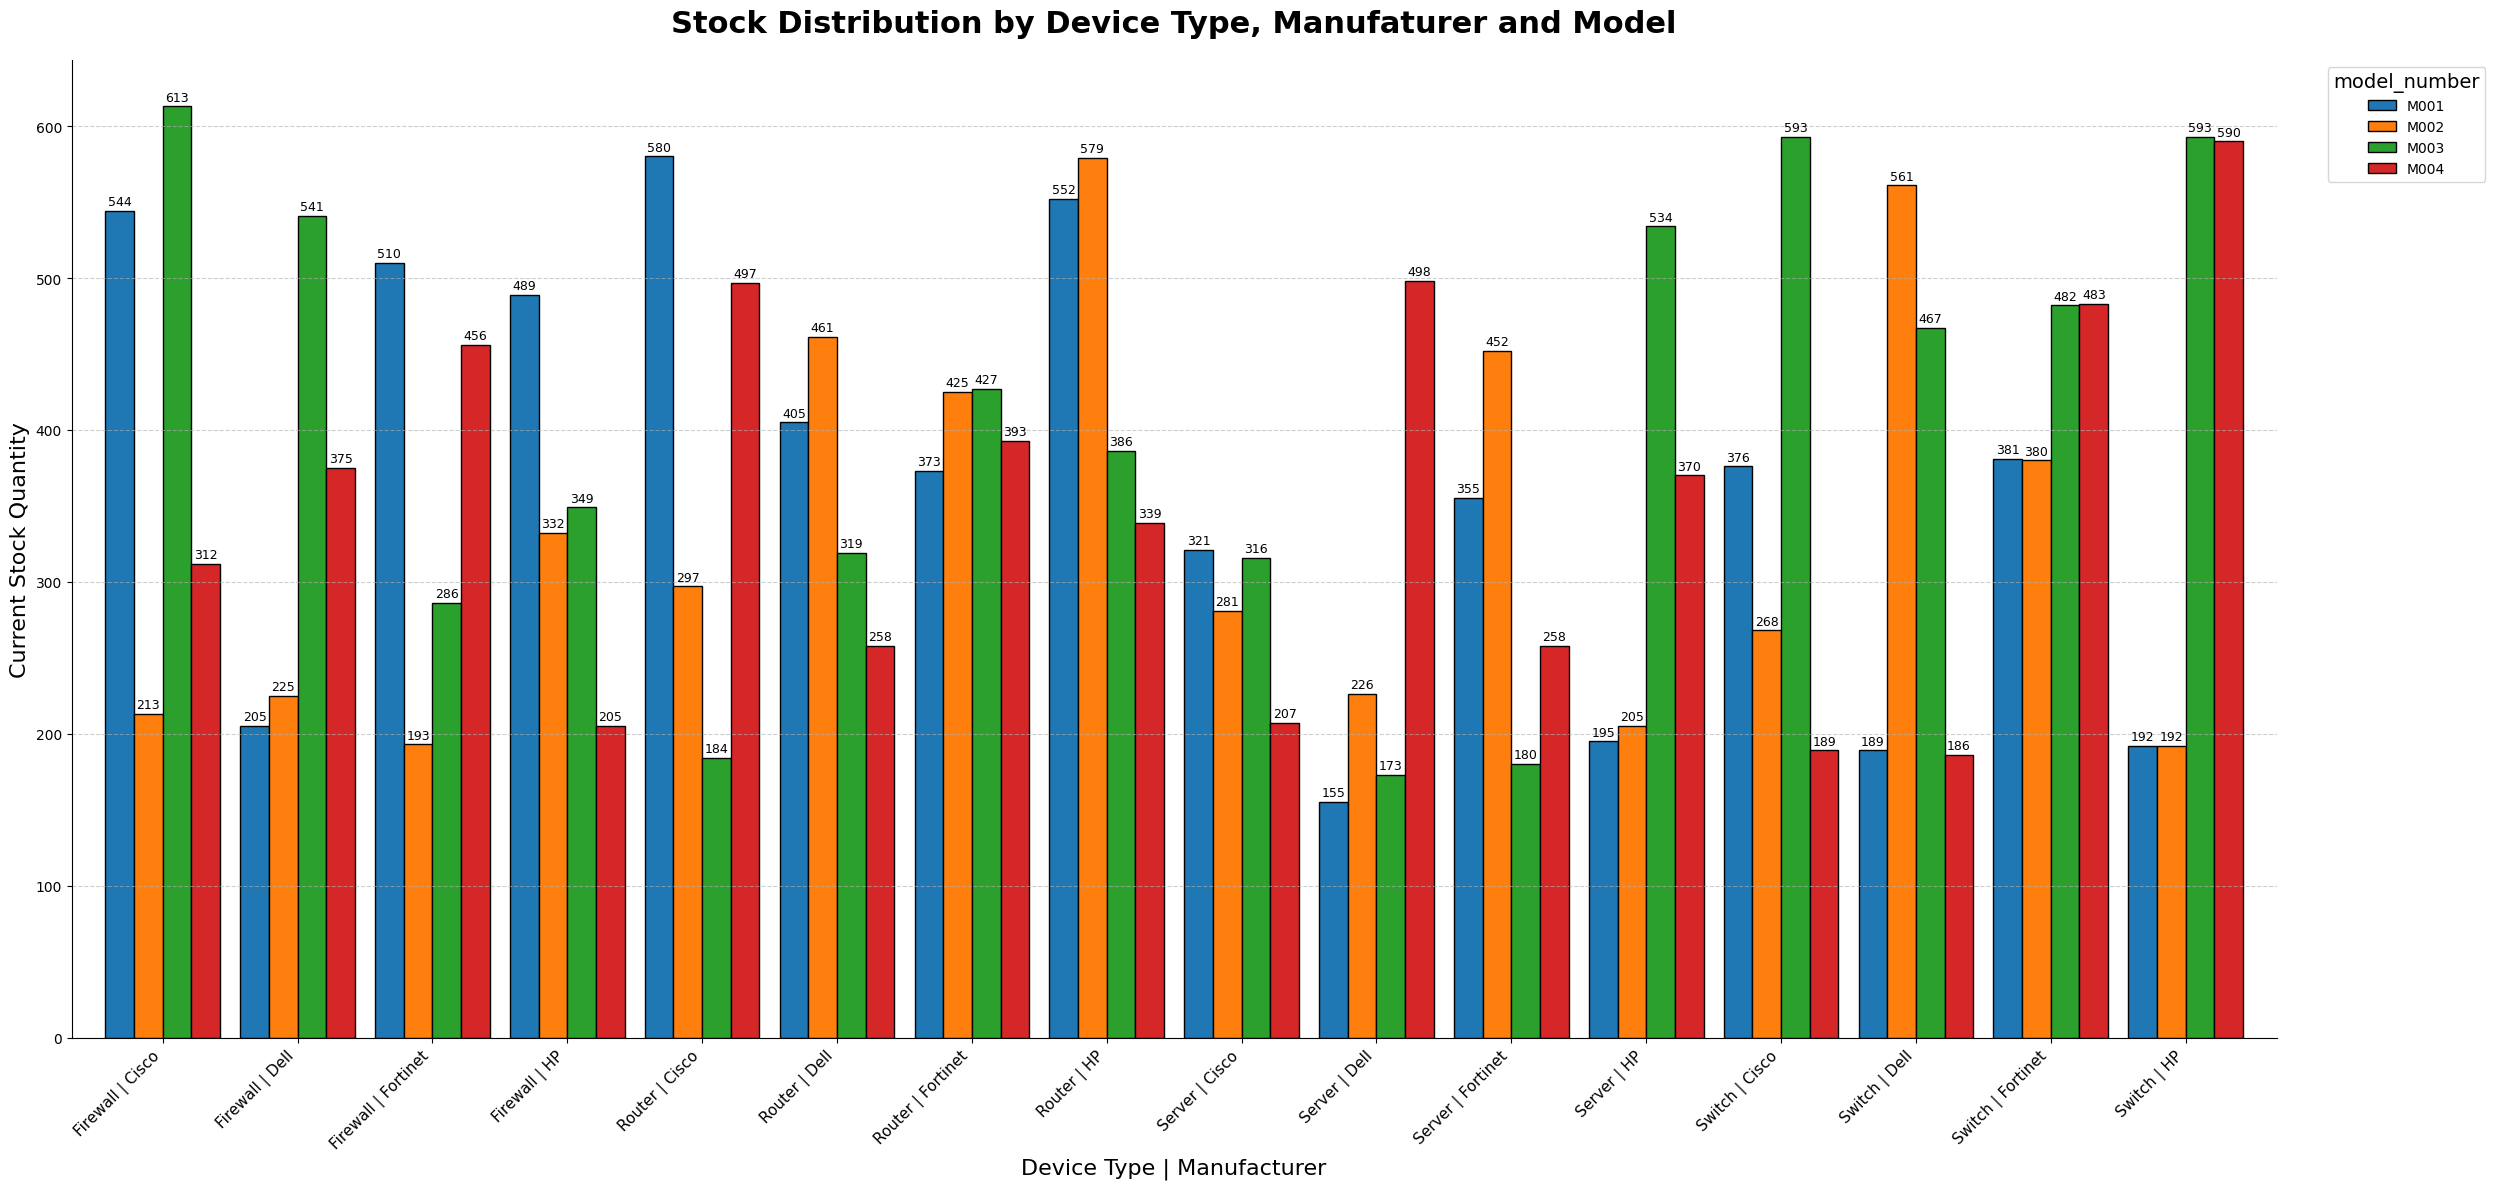

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Stock Distribution by Device Type, Manufaturer and Model'}, xlabel='Device Type | Manufacturer', ylabel='Current Stock Quantity'>)

In [31]:
plot_grouped_bar(
    df = inventory,
    group_cols = ['device_type', 'manufacturer', 'model_number'],
    agg_col = 'current_stock_quantity',
    agg_func='sum',
    figsize=(25, 12),
    title='Stock Distribution by Device Type, Manufaturer and Model',
    xlabel='Device Type | Manufacturer',
    ylabel='Current Stock Quantity',
    rotation=45,
    annotate=True
)

In [32]:
print("The reorder threshold across all manunfacturers and device types are set to 40")

rop = inventory.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['reorder_threshold_quantity'].mean().reset_index()

inventory.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['reorder_threshold_quantity'].mean().unstack()

The reorder threshold across all manunfacturers and device types are set to 40


model_number              M001  M002  M003  M004
device_type manufacturer                        
Firewall    Cisco         40.0  40.0  40.0  40.0
            Dell          40.0  40.0  40.0  40.0
            Fortinet      40.0  40.0  40.0  40.0
            HP            40.0  40.0  40.0  40.0
Router      Cisco         40.0  40.0  40.0  40.0
            Dell          40.0  40.0  40.0  40.0
            Fortinet      40.0  40.0  40.0  40.0
            HP            40.0  40.0  40.0  40.0
Server      Cisco         40.0  40.0  40.0  40.0
            Dell          40.0  40.0  40.0  40.0
            Fortinet      40.0  40.0  40.0  40.0
            HP            40.0  40.0  40.0  40.0
Switch      Cisco         40.0  40.0  40.0  40.0
            Dell          40.0  40.0  40.0  40.0
            Fortinet      40.0  40.0  40.0  40.0
            HP            40.0  40.0  40.0  40.0

In [33]:
ssq = inventory.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['safety_stock_quantity'].mean().reset_index().sort_values(['device_type', 'manufacturer', 'model_number'])

ssq.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['safety_stock_quantity'].mean().unstack()

model_number              M001  M002  M003  M004
device_type manufacturer                        
Firewall    Cisco         13.0  10.0  10.0  11.0
            Dell          12.0  27.0  16.0  30.0
            Fortinet      30.0  20.0  27.0  18.0
            HP            18.0  14.0  23.0  21.0
Router      Cisco         28.0  26.0  14.0  22.0
            Dell          17.0  12.0  22.0  14.0
            Fortinet      29.0  27.0  10.0  11.0
            HP            27.0  30.0  15.0  15.0
Server      Cisco         28.0  20.0  13.0  21.0
            Dell          17.0  12.0  12.0  27.0
            Fortinet      30.0  16.0  27.0  22.0
            HP            27.0  30.0  12.0  17.0
Switch      Cisco         19.0  19.0  11.0  28.0
            Dell          27.0  12.0  25.0  22.0
            Fortinet      18.0  20.0  12.0  14.0
            HP            12.0  22.0  29.0  20.0

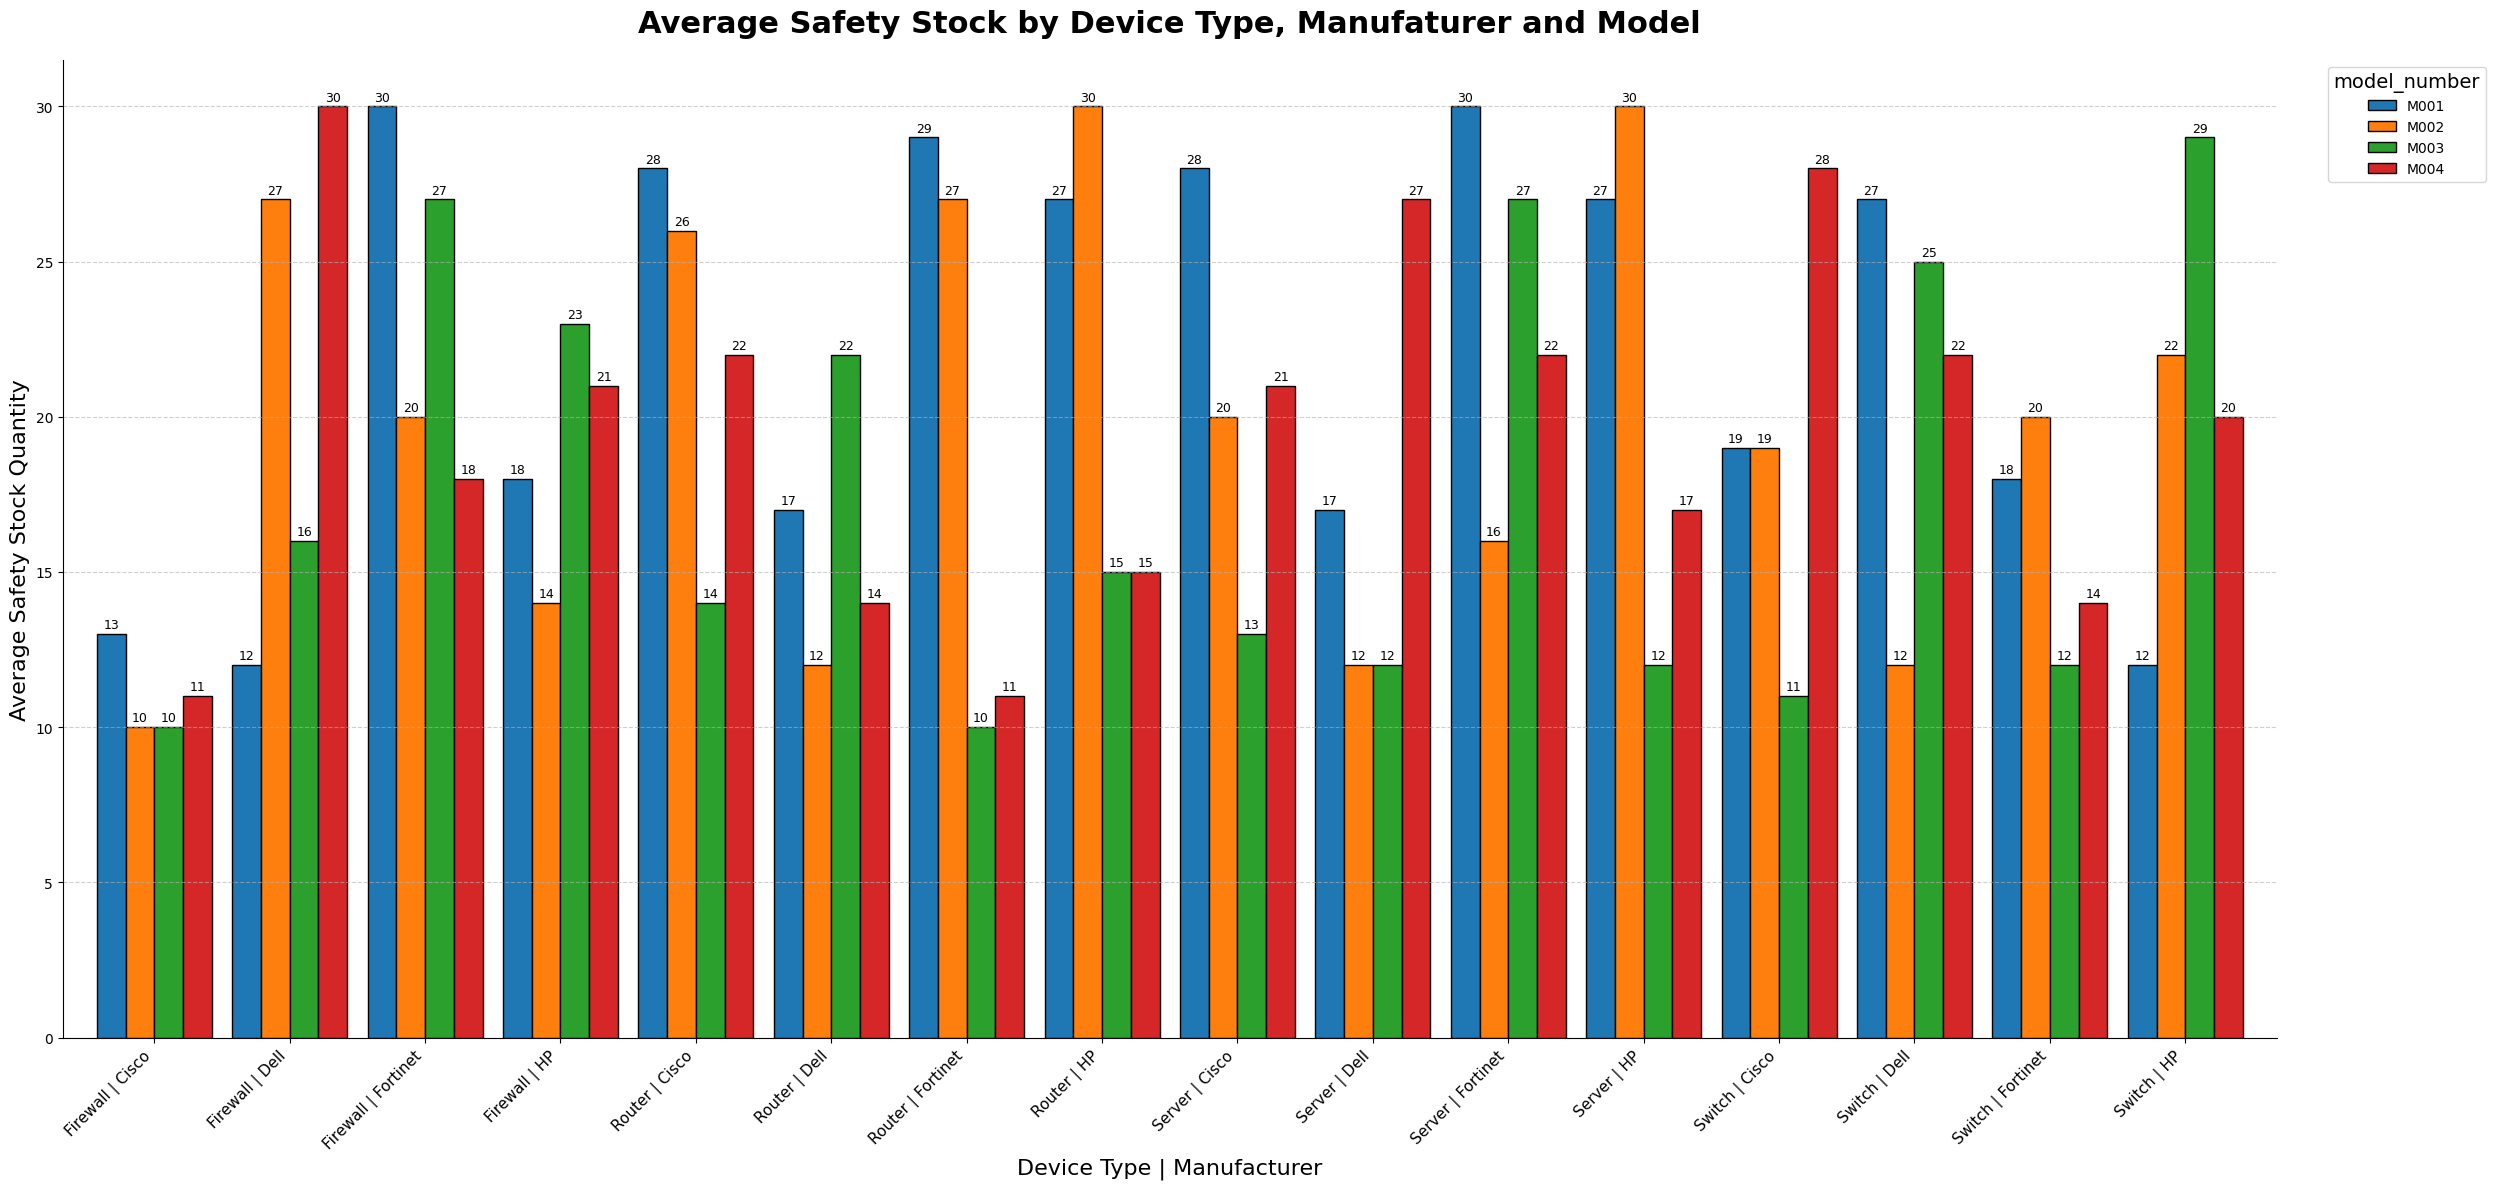

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Average Safety Stock by Device Type, Manufaturer and Model'}, xlabel='Device Type | Manufacturer', ylabel='Average Safety Stock Quantity'>)

In [34]:
plot_grouped_bar(
    df = inventory,
    group_cols = ['device_type', 'manufacturer', 'model_number'],
    agg_col = 'safety_stock_quantity',
    agg_func='mean',
    figsize=(25, 12),
    title='Average Safety Stock by Device Type, Manufaturer and Model',
    xlabel='Device Type | Manufacturer',
    ylabel='Average Safety Stock Quantity',
    rotation=45,
    annotate=True
)

In [35]:
unit_cost = inventory.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['unit_cost'].mean().reset_index().sort_values(['device_type', 'manufacturer', 'model_number'])

unit_cost.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['unit_cost'].mean().unstack()

model_number                     M001         M002         M003         M004
device_type manufacturer                                                    
Firewall    Cisco         4176.036667  3351.056667  2247.756667  1020.273333
            Dell          4351.886667  4398.396667  3991.660000  3623.373333
            Fortinet       970.196667  3662.240000  2040.450000  1913.890000
            HP            2459.953333  4880.433333  4217.563333  4075.443333
Router      Cisco         3866.226667  1588.666667  1407.873333  1023.873333
            Dell           946.483333  2665.733333  4672.690000  2723.743333
            Fortinet      4645.386667  1811.203333  4546.373333  2510.980000
            HP            2457.556667  2765.950000  3968.666667  4560.106667
Server      Cisco         4426.266667  3916.580000  3361.746667  3377.060000
            Dell          2634.036667  4942.676667   755.130000   719.170000
            Fortinet      3968.186667  3226.680000  1892.950000  4483.536667
            HP            4355.096667  2802.400000  2146.906667  1151.360000
Switch      Cisco         4241.920000  2104.430000  4892.560000   886.483333
            Dell          4338.166667   627.646667  4534.876667  1904.216667
            Fortinet      2445.723333  4166.310000  1343.120000  2613.360000
            HP            4698.463333  2413.683333   805.290000  4814.066667

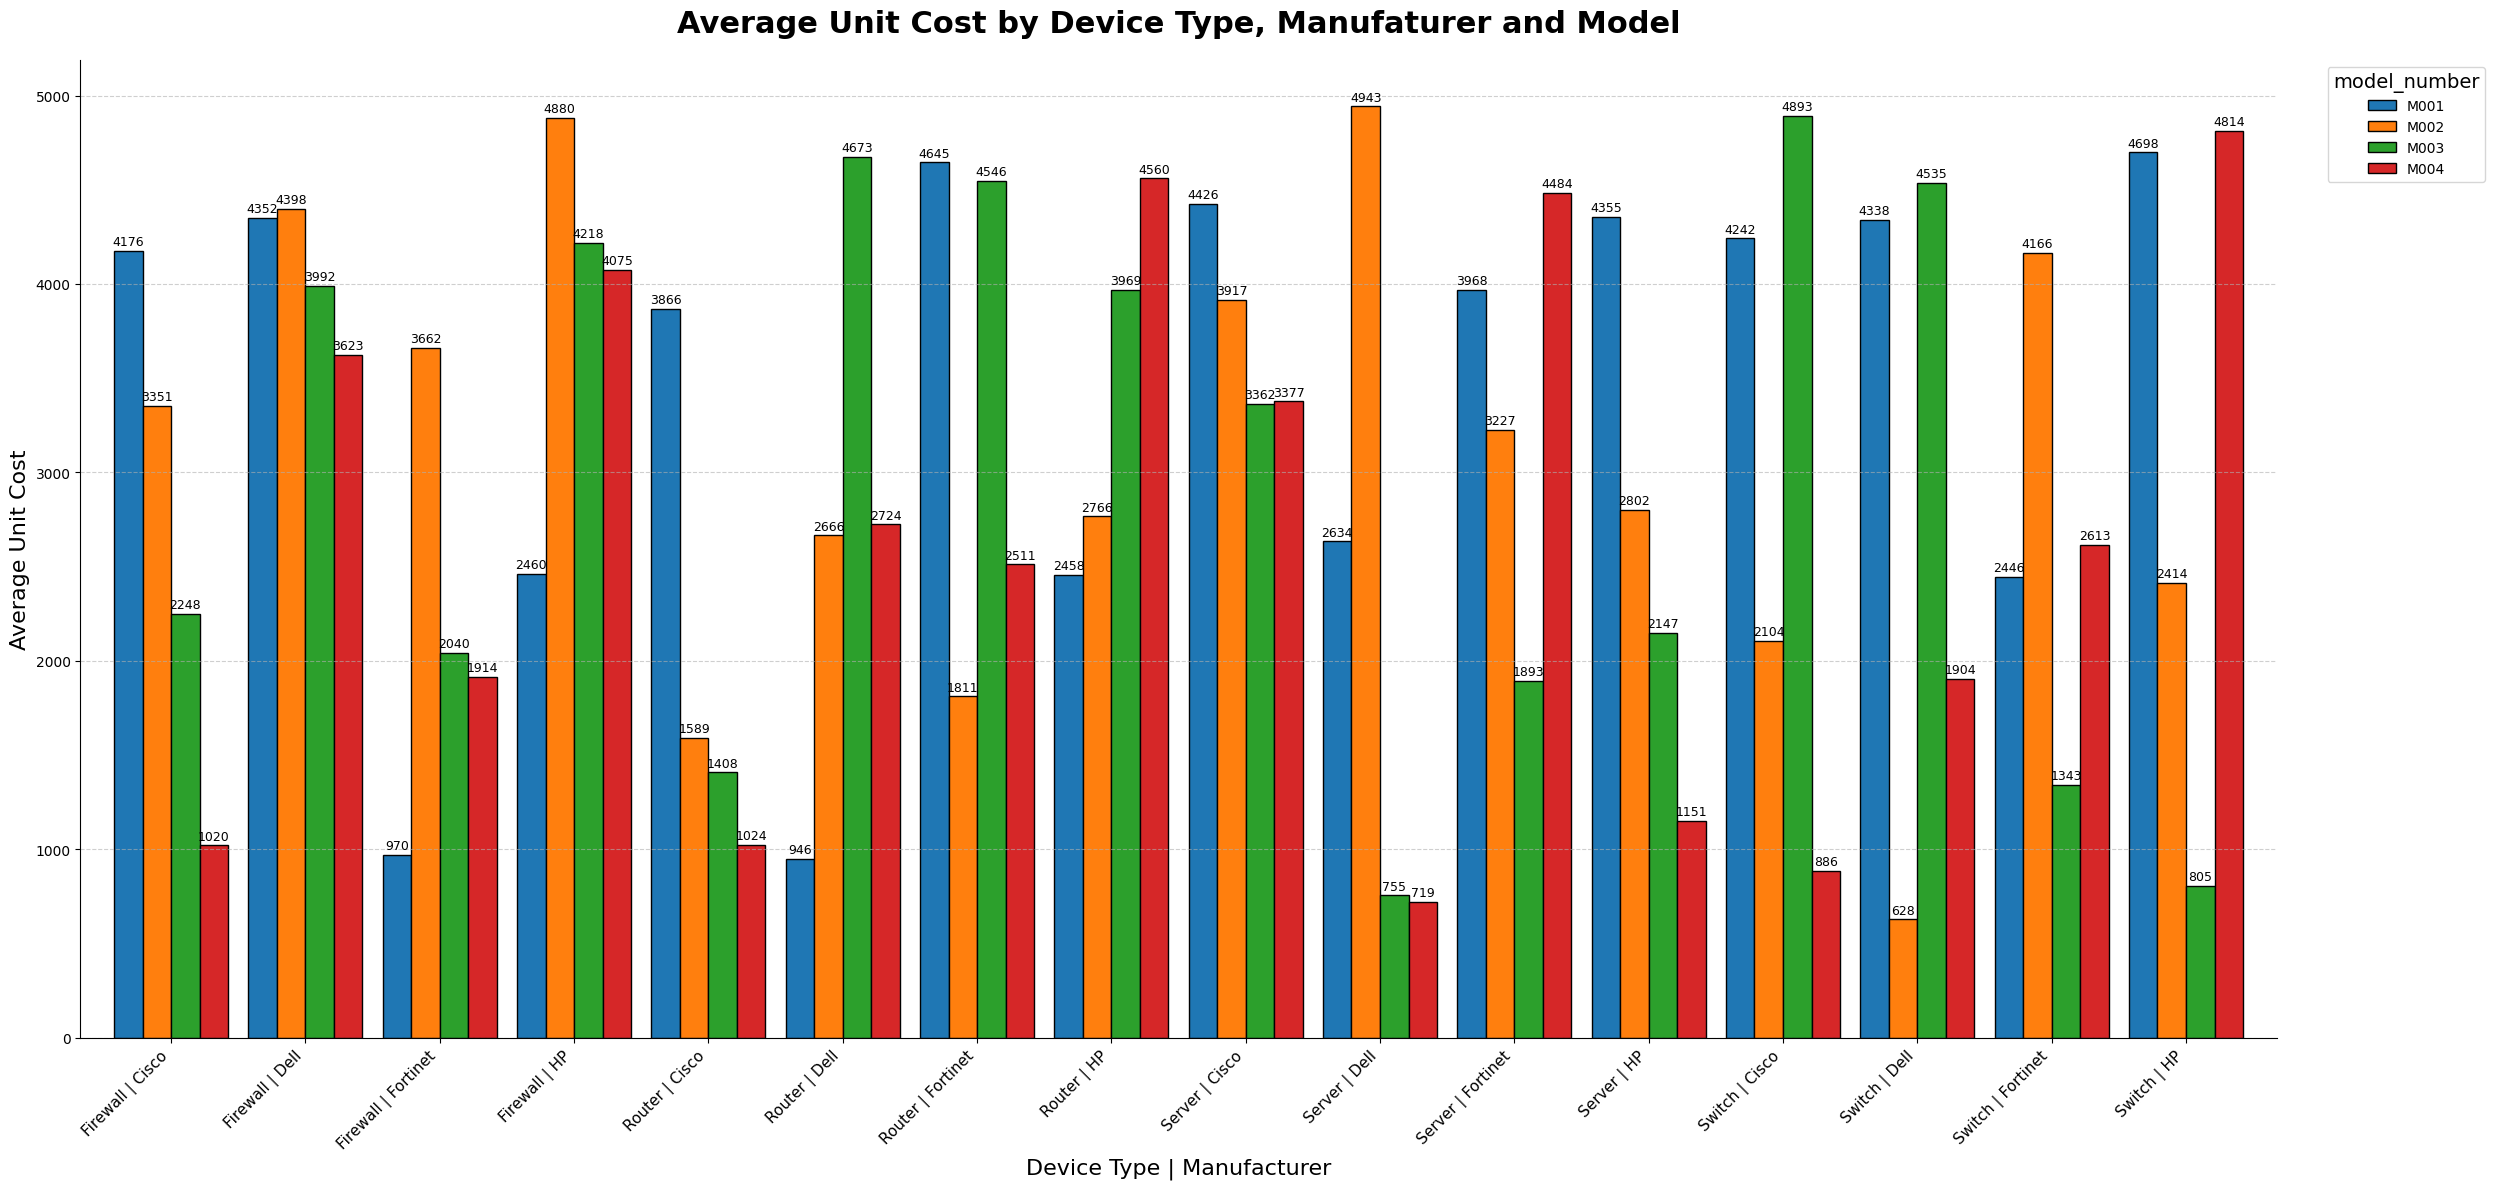

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Average Unit Cost by Device Type, Manufaturer and Model'}, xlabel='Device Type | Manufacturer', ylabel='Average Unit Cost'>)

In [36]:
plot_grouped_bar(
    df = inventory,
    group_cols = ['device_type', 'manufacturer', 'model_number'],
    agg_col = 'unit_cost',
    agg_func='mean',
    figsize=(25, 12),
    title='Average Unit Cost by Device Type, Manufaturer and Model',
    xlabel='Device Type | Manufacturer',
    ylabel='Average Unit Cost',
    rotation=45,
    annotate=True
)

In [37]:
ltd = inventory.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['lead_time_days'].mean().reset_index()

ltd.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['lead_time_days'].mean().unstack()

model_number                   M001       M002       M003       M004
device_type manufacturer                                            
Firewall    Cisco          5.333333  13.000000   4.666667   7.333333
            Dell          10.666667   5.666667  12.333333   8.333333
            Fortinet      12.666667   3.666667  11.000000  11.000000
            HP            14.333333  14.333333   6.333333   9.000000
Router      Cisco          9.666667   9.333333  12.666667   9.333333
            Dell           1.666667   7.333333  12.333333   5.666667
            Fortinet       4.666667  11.333333   3.666667   5.000000
            HP             4.000000   7.666667   9.333333  11.666667
Server      Cisco          8.333333   7.666667   5.000000  13.000000
            Dell           6.000000  10.666667   5.666667   6.000000
            Fortinet       7.666667  13.333333  14.666667   7.000000
            HP             3.666667  13.000000   2.333333   2.666667
Switch      Cisco          8.666667   5.666667  14.333333   9.333333
            Dell           4.000000   7.000000   5.000000   4.333333
            Fortinet       9.666667   4.000000  12.333333   8.000000
            HP             4.666667   3.666667   4.000000   6.333333

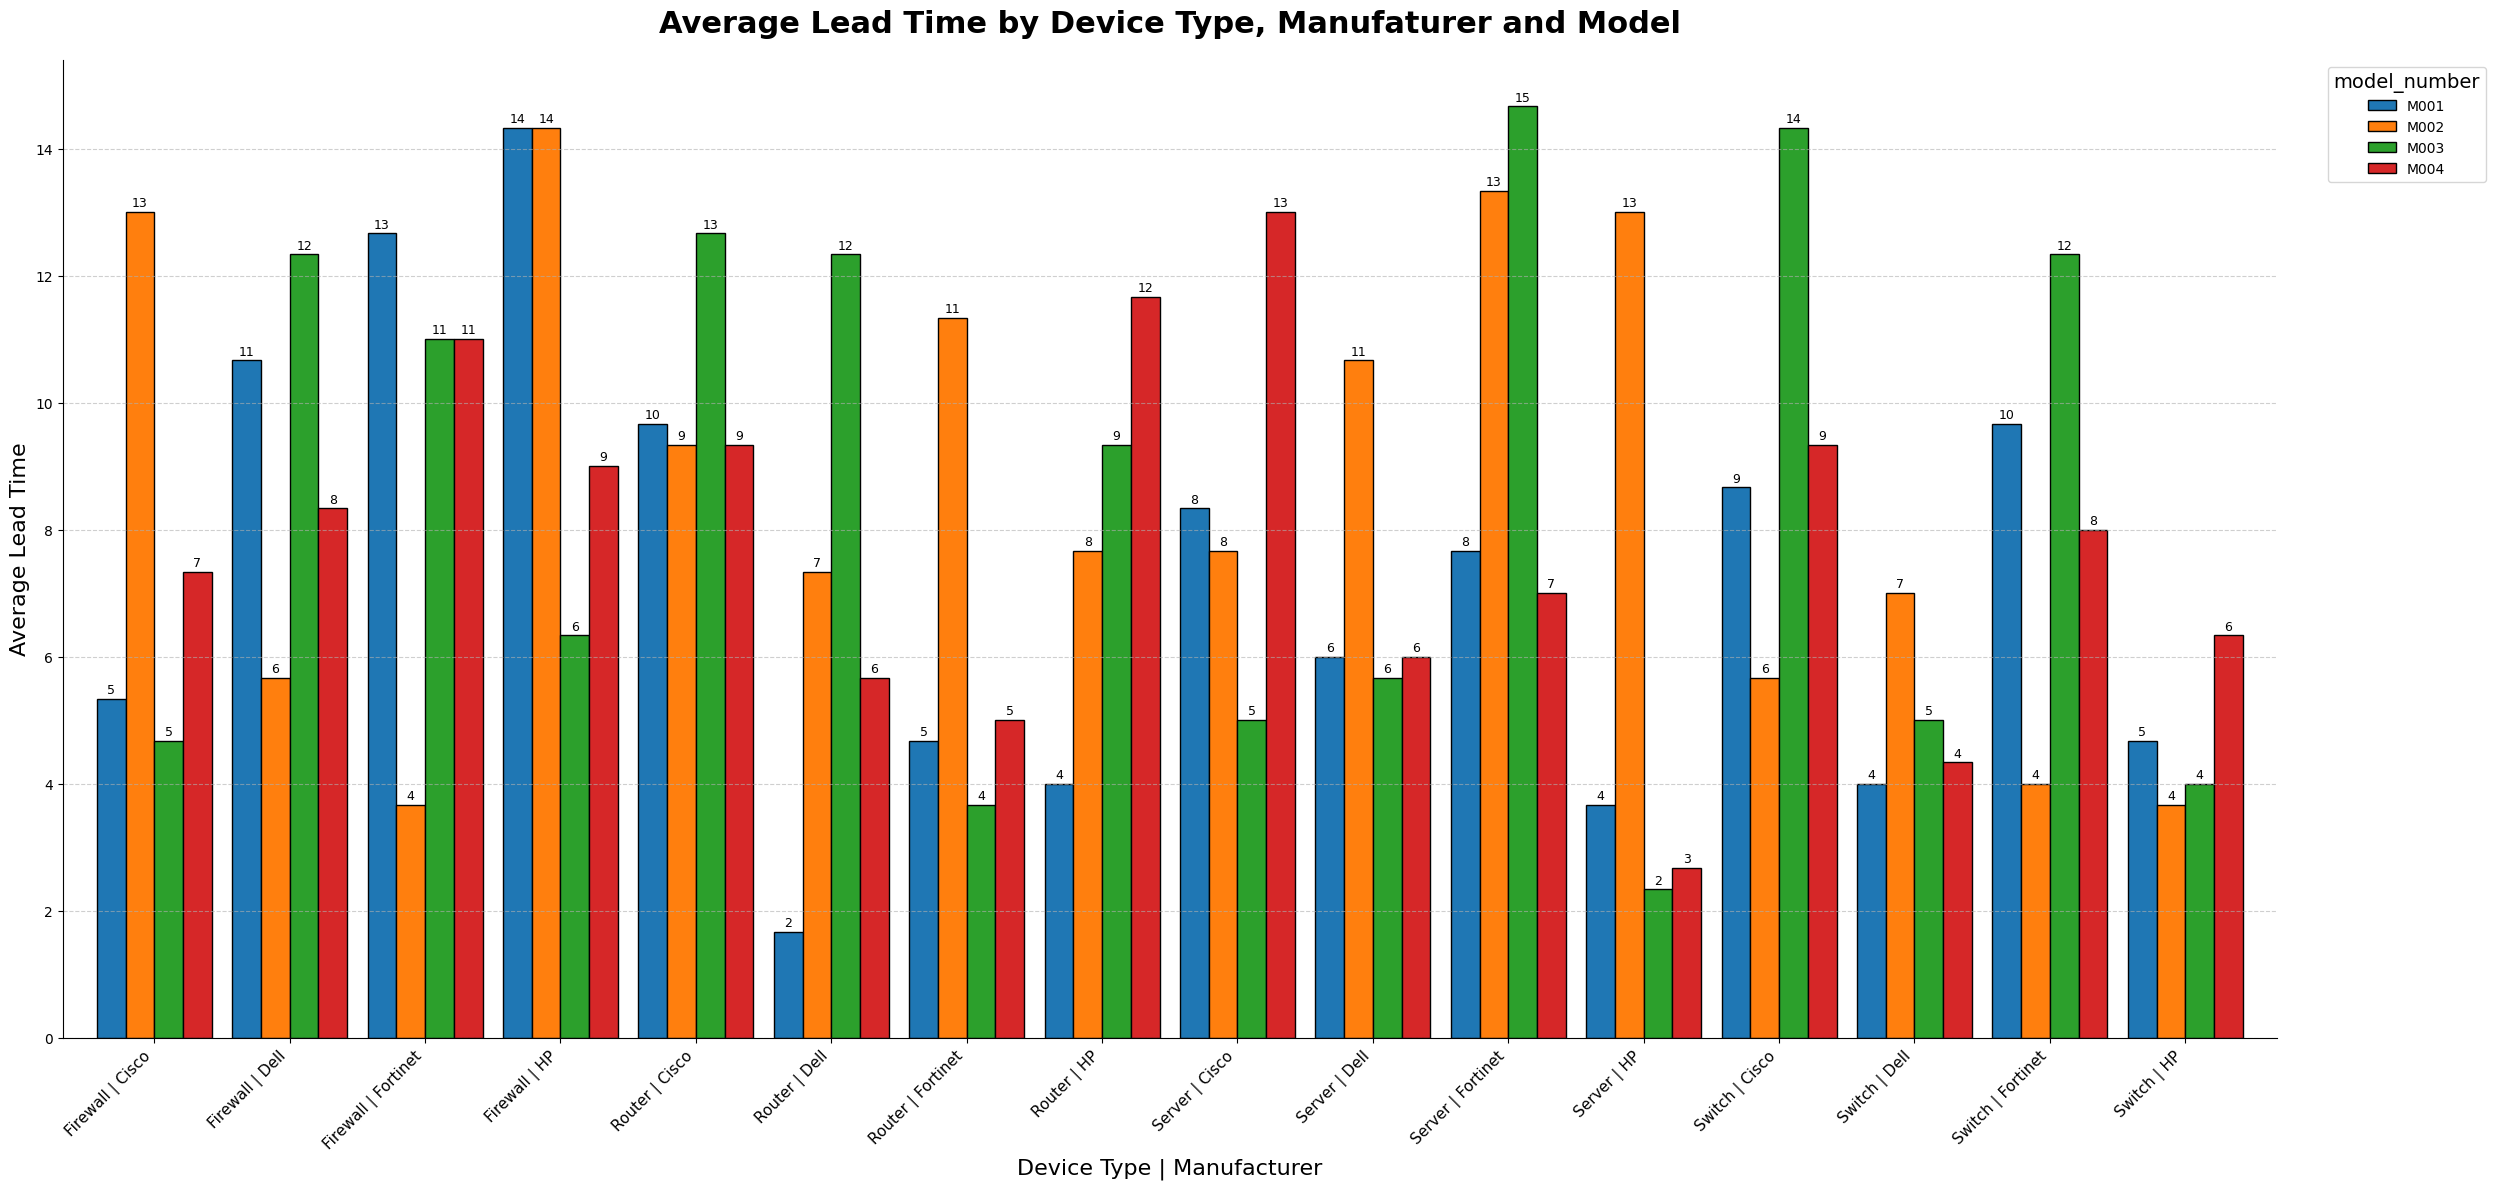

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Average Lead Time by Device Type, Manufaturer and Model'}, xlabel='Device Type | Manufacturer', ylabel='Average Lead Time'>)

In [38]:
plot_grouped_bar(
    df = inventory,
    group_cols = ['device_type', 'manufacturer', 'model_number'],
    agg_col = 'lead_time_days',
    agg_func='mean',
    figsize=(25, 12),
    title='Average Lead Time by Device Type, Manufaturer and Model',
    xlabel='Device Type | Manufacturer',
    ylabel='Average Lead Time',
    rotation=45,
    annotate=True
)

### Maintenance EDA

In [39]:
maintenance.head()

,maintenance_id,client_id,maintenance_date,maintenance_type,failure_type,downtime_minutes,replaced_component,cost,file_year
0,M001,C017,2023-05-01 23:05:54,Corrective,Disk,67.0,SSD,854.0,2023
1,M002,C018,2023-07-29 06:14:19,Preventive,Network,118.0,SSD,130.0,2023
2,M002,C001,2023-11-25 23:11:31,Preventive,Network,60.0,NIC,765.0,2023
3,M003,C003,2023-07-28 13:45:00,Preventive,Memory,160.0,RAM,928.0,2023
4,M004,C011,2023-09-29 22:24:29,Corrective,Memory,81.0,SSD,320.0,2023


In [40]:
cost = maintenance.groupby(
    ['maintenance_type', 'failure_type', 'replaced_component']
)['cost'].mean().reset_index()

cost.groupby(
    ['maintenance_type', 'failure_type', 'replaced_component']
)['cost'].mean().unstack()

replaced_component                    NIC         RAM         SSD
maintenance_type failure_type                                    
Corrective       Disk          549.485030  558.325103  556.478632
                 Memory        575.013187  555.806742  551.855159
                 Network       550.635294  558.168539  531.157787
Preventive       Disk          550.924051  532.811321  547.478170
                 Memory        556.435730  565.042146  537.684760
                 Network       575.821138  535.180361  550.277419

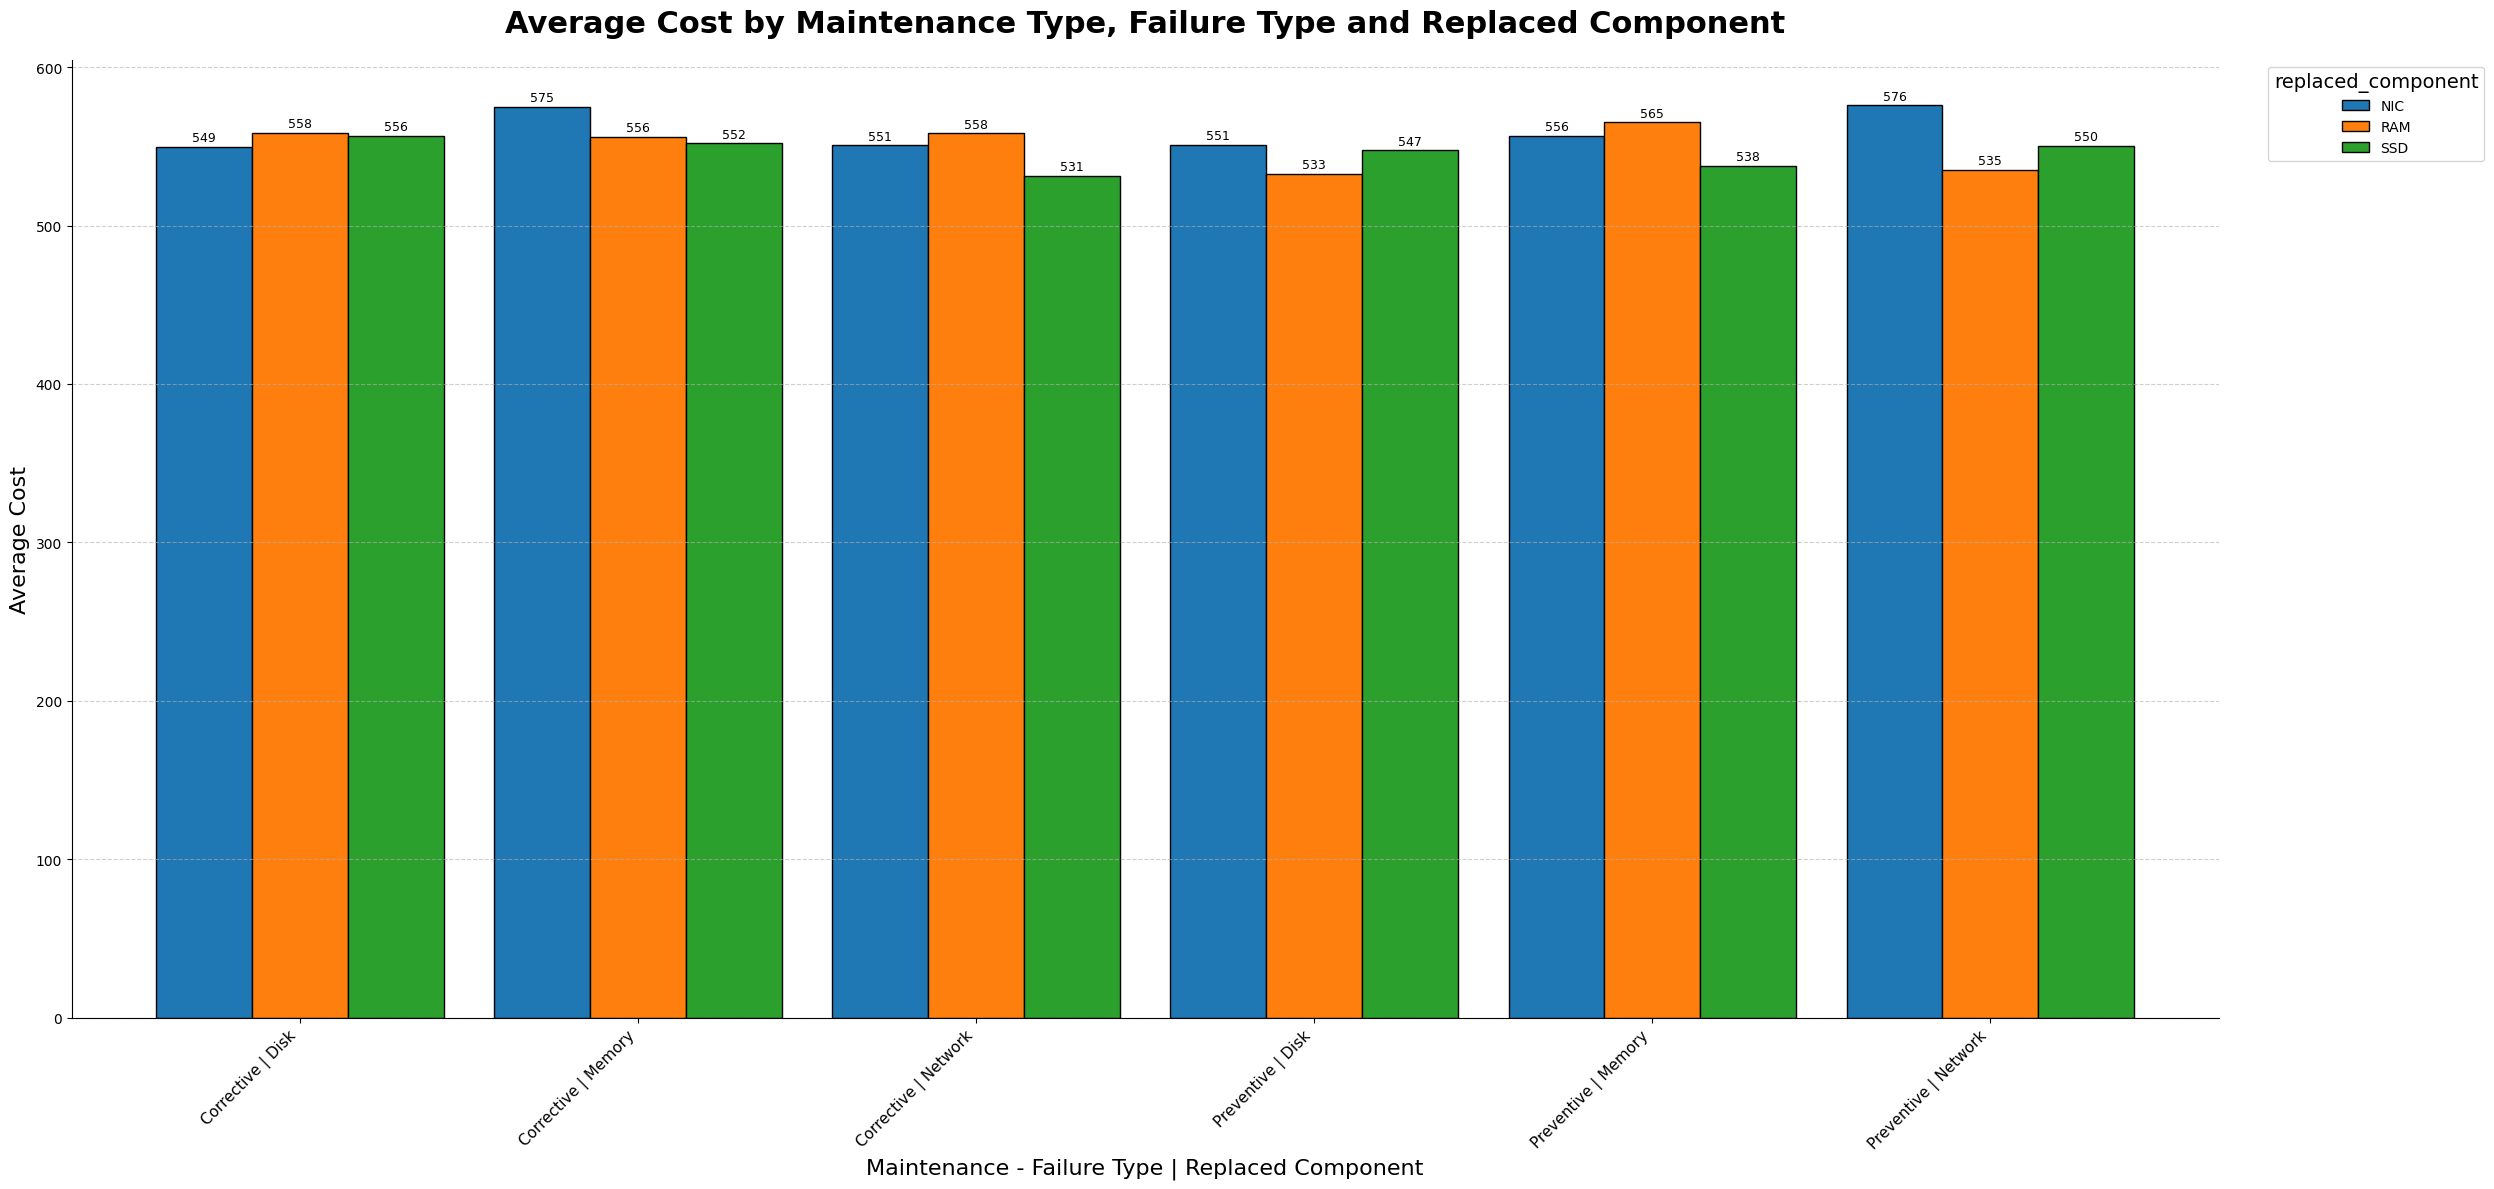

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Average Cost by Maintenance Type, Failure Type and Replaced Component'}, xlabel='Maintenance - Failure Type | Replaced Component', ylabel='Average Cost'>)

In [41]:
plot_grouped_bar(
    df = maintenance,
    group_cols = ['maintenance_type', 'failure_type', 'replaced_component'],
    agg_col = 'cost',
    agg_func='mean',
    figsize=(25, 12),
    title='Average Cost by Maintenance Type, Failure Type and Replaced Component',
    xlabel='Maintenance - Failure Type | Replaced Component',
    ylabel='Average Cost',
    rotation=45,
    annotate=True
)

In [42]:
cost = maintenance.groupby(
    ['maintenance_type', 'failure_type', 'replaced_component']
)['cost'].std().reset_index()

cost.groupby(
    ['maintenance_type', 'failure_type', 'replaced_component']
)['cost'].mean().unstack()

replaced_component                    NIC         RAM         SSD
maintenance_type failure_type                                    
Corrective       Disk          266.071777  255.145136  264.729537
                 Memory        263.107438  266.046054  260.887362
                 Network       263.094947  263.615551  260.303680
Preventive       Disk          263.289249  261.317376  250.850528
                 Memory        254.147530  253.829265  265.159356
                 Network       254.363077  254.586545  256.359986

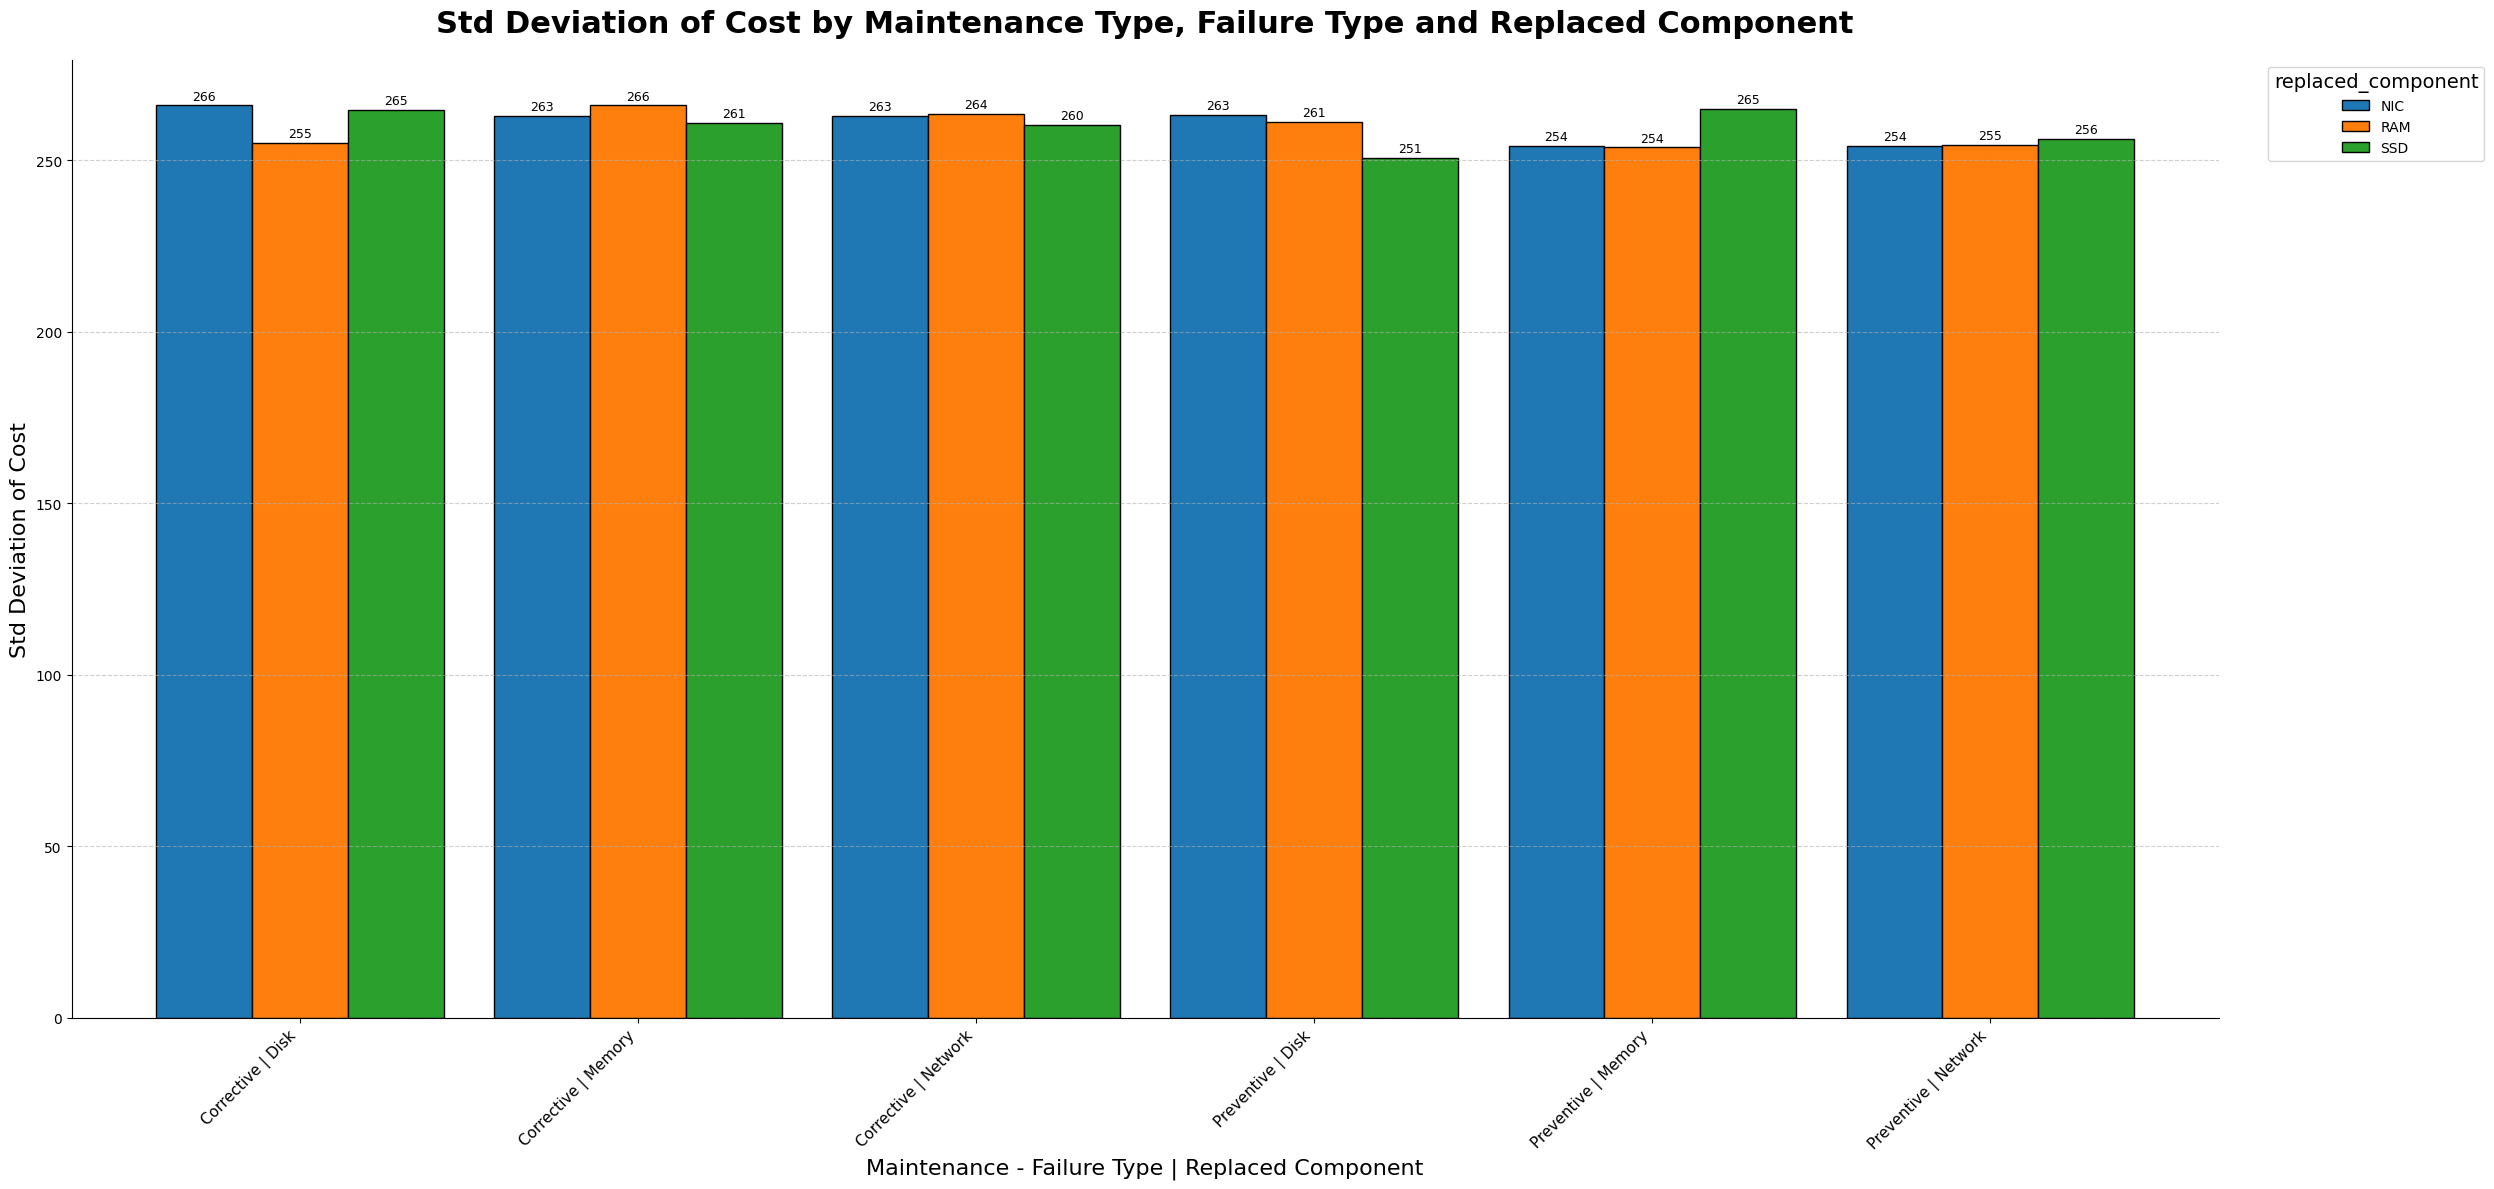

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Std Deviation of Cost by Maintenance Type, Failure Type and Replaced Component'}, xlabel='Maintenance - Failure Type | Replaced Component', ylabel='Std Deviation of Cost'>)

In [43]:
plot_grouped_bar(
    df = maintenance,
    group_cols = ['maintenance_type', 'failure_type', 'replaced_component'],
    agg_col = 'cost',
    agg_func='std',
    figsize=(25, 12),
    title='Std Deviation of Cost by Maintenance Type, Failure Type and Replaced Component',
    xlabel='Maintenance - Failure Type | Replaced Component',
    ylabel='Std Deviation of Cost',
    rotation=45,
    annotate=True
)

In [44]:
dm = maintenance.groupby(
    ['maintenance_type', 'failure_type', 'replaced_component']
)['downtime_minutes'].std().reset_index()

dm.groupby(
    ['maintenance_type', 'failure_type', 'replaced_component']
)['downtime_minutes'].mean().unstack()

replaced_component                   NIC        RAM        SSD
maintenance_type failure_type                                 
Corrective       Disk          65.972911  67.262618  65.715406
                 Memory        66.977060  66.455728  67.504065
                 Network       67.859119  67.628177  66.705260
Preventive       Disk          64.995858  65.438614  67.141191
                 Memory        66.337995  66.593676  66.886673
                 Network       66.851601  66.969575  66.213595

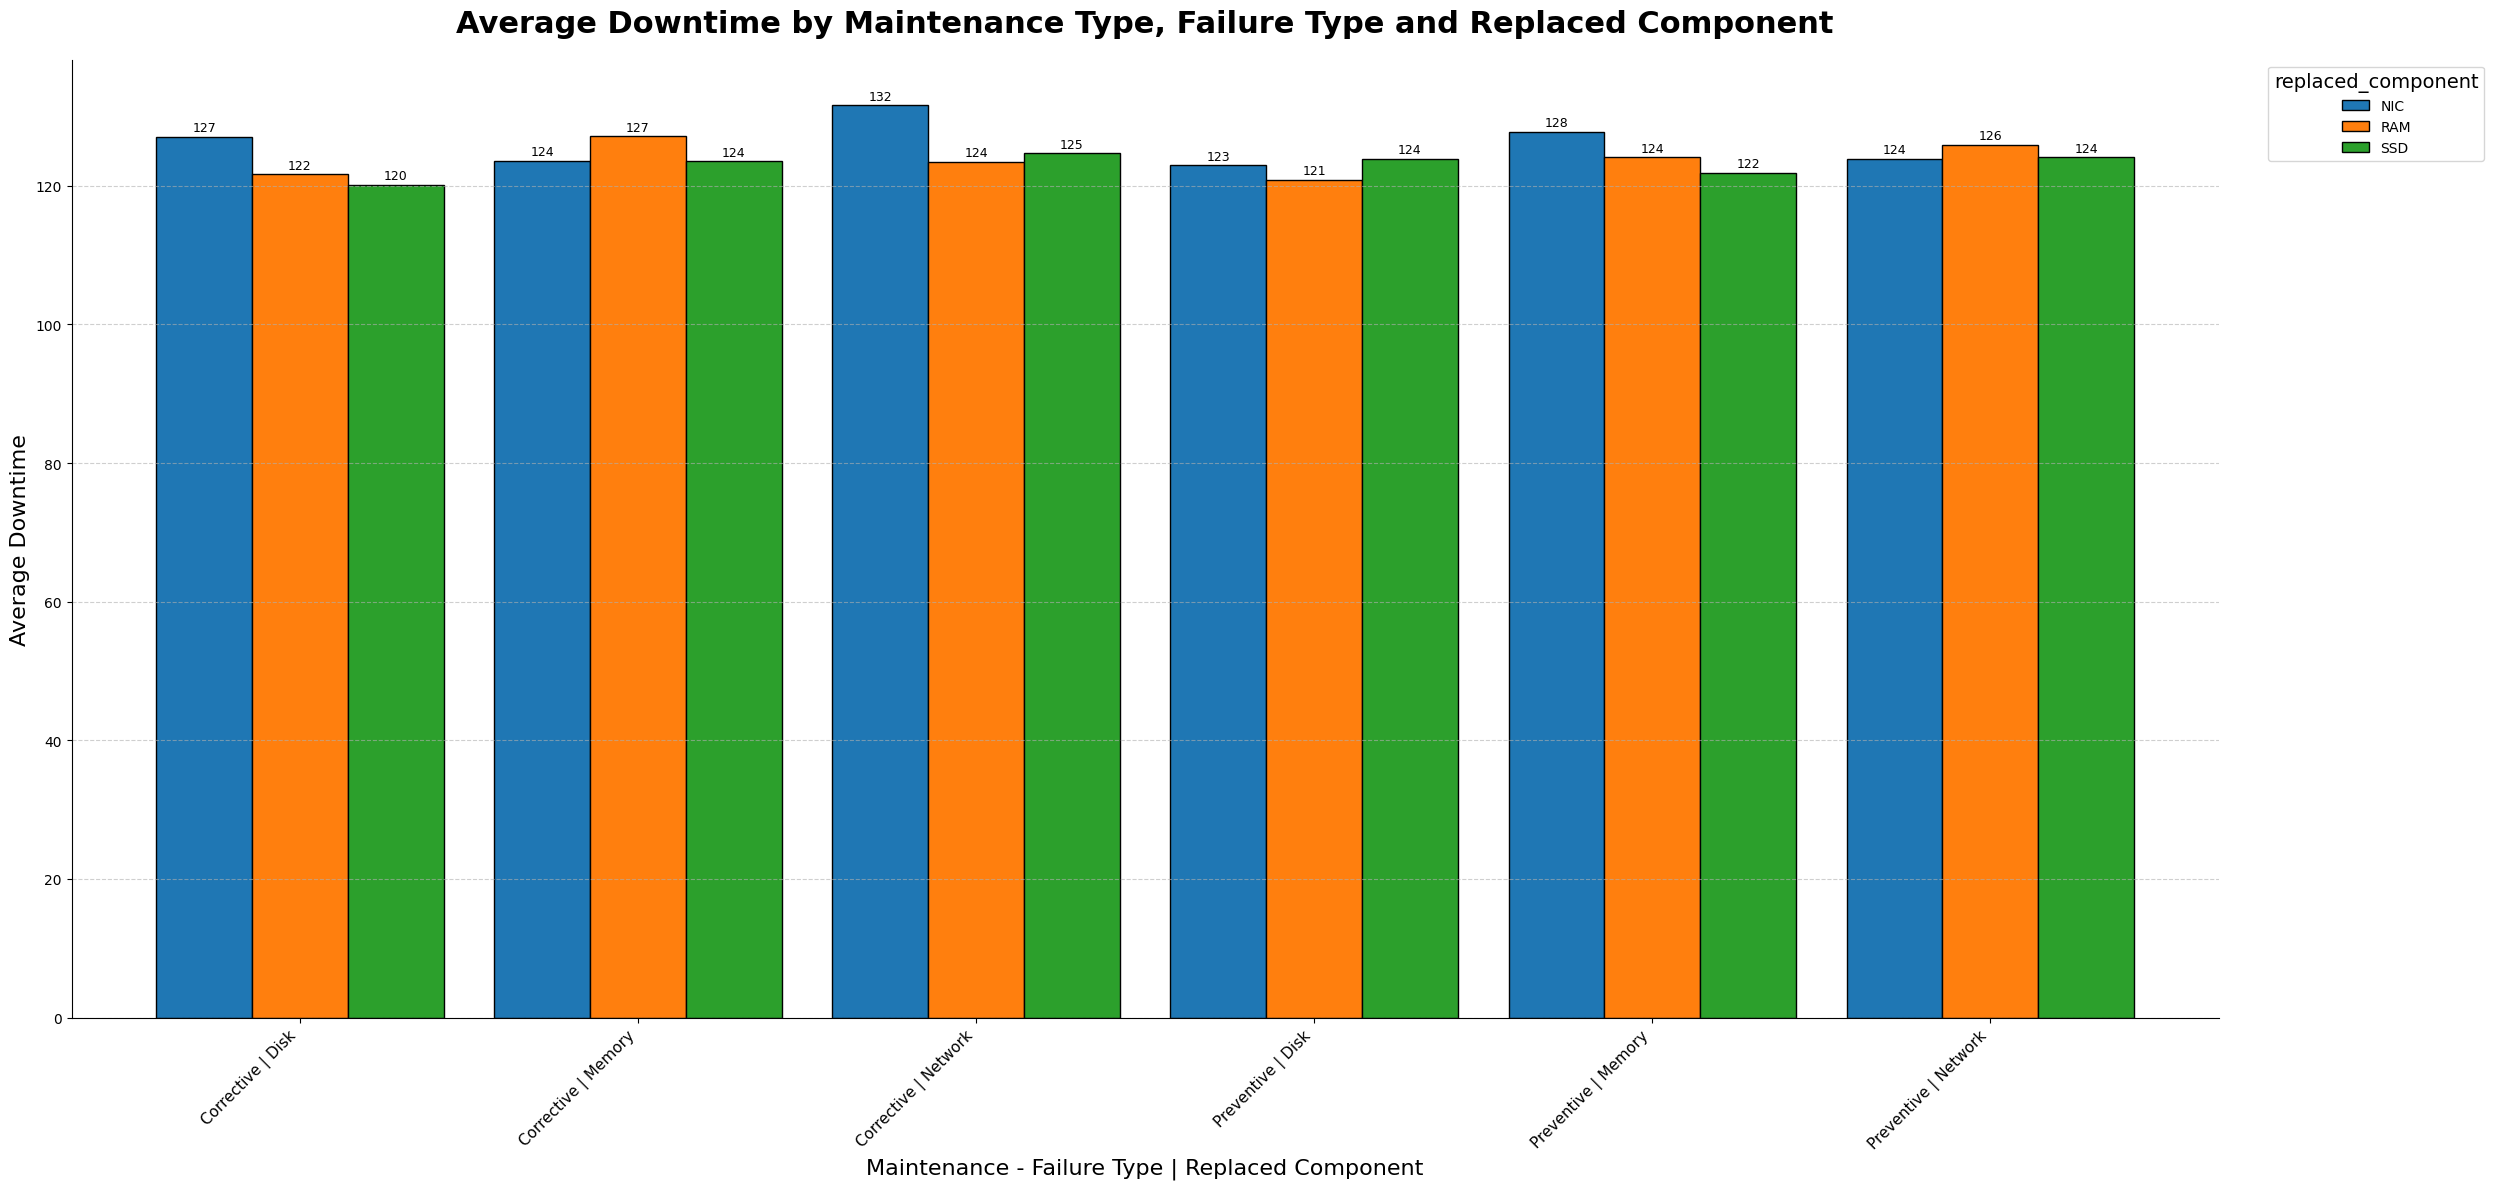

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Average Downtime by Maintenance Type, Failure Type and Replaced Component'}, xlabel='Maintenance - Failure Type | Replaced Component', ylabel='Average Downtime'>)

In [45]:
plot_grouped_bar(
    df = maintenance,
    group_cols = ['maintenance_type', 'failure_type', 'replaced_component'],
    agg_col = 'downtime_minutes',
    agg_func='mean',
    figsize=(25, 12),
    title='Average Downtime by Maintenance Type, Failure Type and Replaced Component',
    xlabel='Maintenance - Failure Type | Replaced Component',
    ylabel='Average Downtime',
    rotation=45,
    annotate=True
)

### Tickets EDA

In [46]:
tickets.head()

,ticket_id,client_id,asset_id,engineer_id,ticket_created_timestamp,ticket_close_timestamp,ticket_category,issue_type,ticket_priority,ticket_channel,escalation_flag,ticket_reopen_flag,first_response_time_minutes,resolution_time_minutes,sla_breach_flag,ticket_description,resolution_notes,file_year,cnt
0,T0000001,C011,AID_063,E003,2023-08-10 23:20:38,2023-08-11 11:19:55,Hardware,Failure,P1,Email,0.0,0.0,53.0,719.28,0.0,Server 04 failing to POST.,Motherboard replaced.,2023,1
1,T0000002,C004,AID_055,E006,2023-03-31 15:33:41,2023-04-02 14:59:28,Hardware,Access,P3,Portal,0.0,1.0,10.0,2845.78,0.0,Server 04 failing to POST.,Motherboard replaced.,2023,1
2,T0000003,C008,AID_033,E014,2023-06-20 10:42:06,2023-06-22 04:39:09,Network,Access,P4,Portal,0.0,1.0,47.0,2517.05,0.0,Total loss of connectivity in Sector B.,Replaced faulty NIC and patched firmware.,2023,1
3,T0000004,C008,AID_049,E011,2023-10-09 01:29:05,2023-10-11 06:36:37,Hardware,Access,P4,Email,1.0,1.0,60.0,3187.53,1.0,Server 04 failing to POST.,Motherboard replaced.,2023,1
4,T0000005,C004,AID_055,E020,2023-10-05 14:26:03,2023-10-06 02:46:48,Network,Access,P1,Portal,1.0,1.0,53.0,740.75,1.0,Total loss of connectivity in Sector B.,Replaced faulty NIC and patched firmware.,2023,1


In [47]:
frtm = tickets.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['first_response_time_minutes'].mean().reset_index()

frtm.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['first_response_time_minutes'].mean().unstack()

issue_type                                         Access      Crash    Failure       Slow
ticket_category ticket_priority ticket_channel                                            
Hardware        P1              Email           33.108883  33.008403  31.704478  31.848765
                                Portal          31.048518  33.116216  32.265583  31.747692
                P2              Email           32.779614  32.923913  31.972010  31.426426
                                Portal          33.292899  32.316216  30.596045  31.110448
                P3              Email           32.287834  32.366154  31.178161  32.847645
                                Portal          31.519288  32.761765  32.495702  32.217877
                P4              Email           33.642857  30.306785  33.981383  31.842857
                                Portal          32.421538  32.757062  32.670360  32.231429
Network         P1              Email           33.960606  31.495845  31.169054  33.259259
                                Portal          34.099715  32.372340  33.288889  32.090634
                P2              Email           33.108280  33.431818  32.991045  31.577836
                                Portal          33.231638  31.552147  31.436364  32.834239
                P3              Email           33.670330  32.326975  32.361516  32.869969
                                Portal          33.276730  34.200549  31.972973  32.336336
                P4              Email           31.755435  33.070588  32.892045  31.163205
                                Portal          32.947368  32.210826  31.752841  31.300000

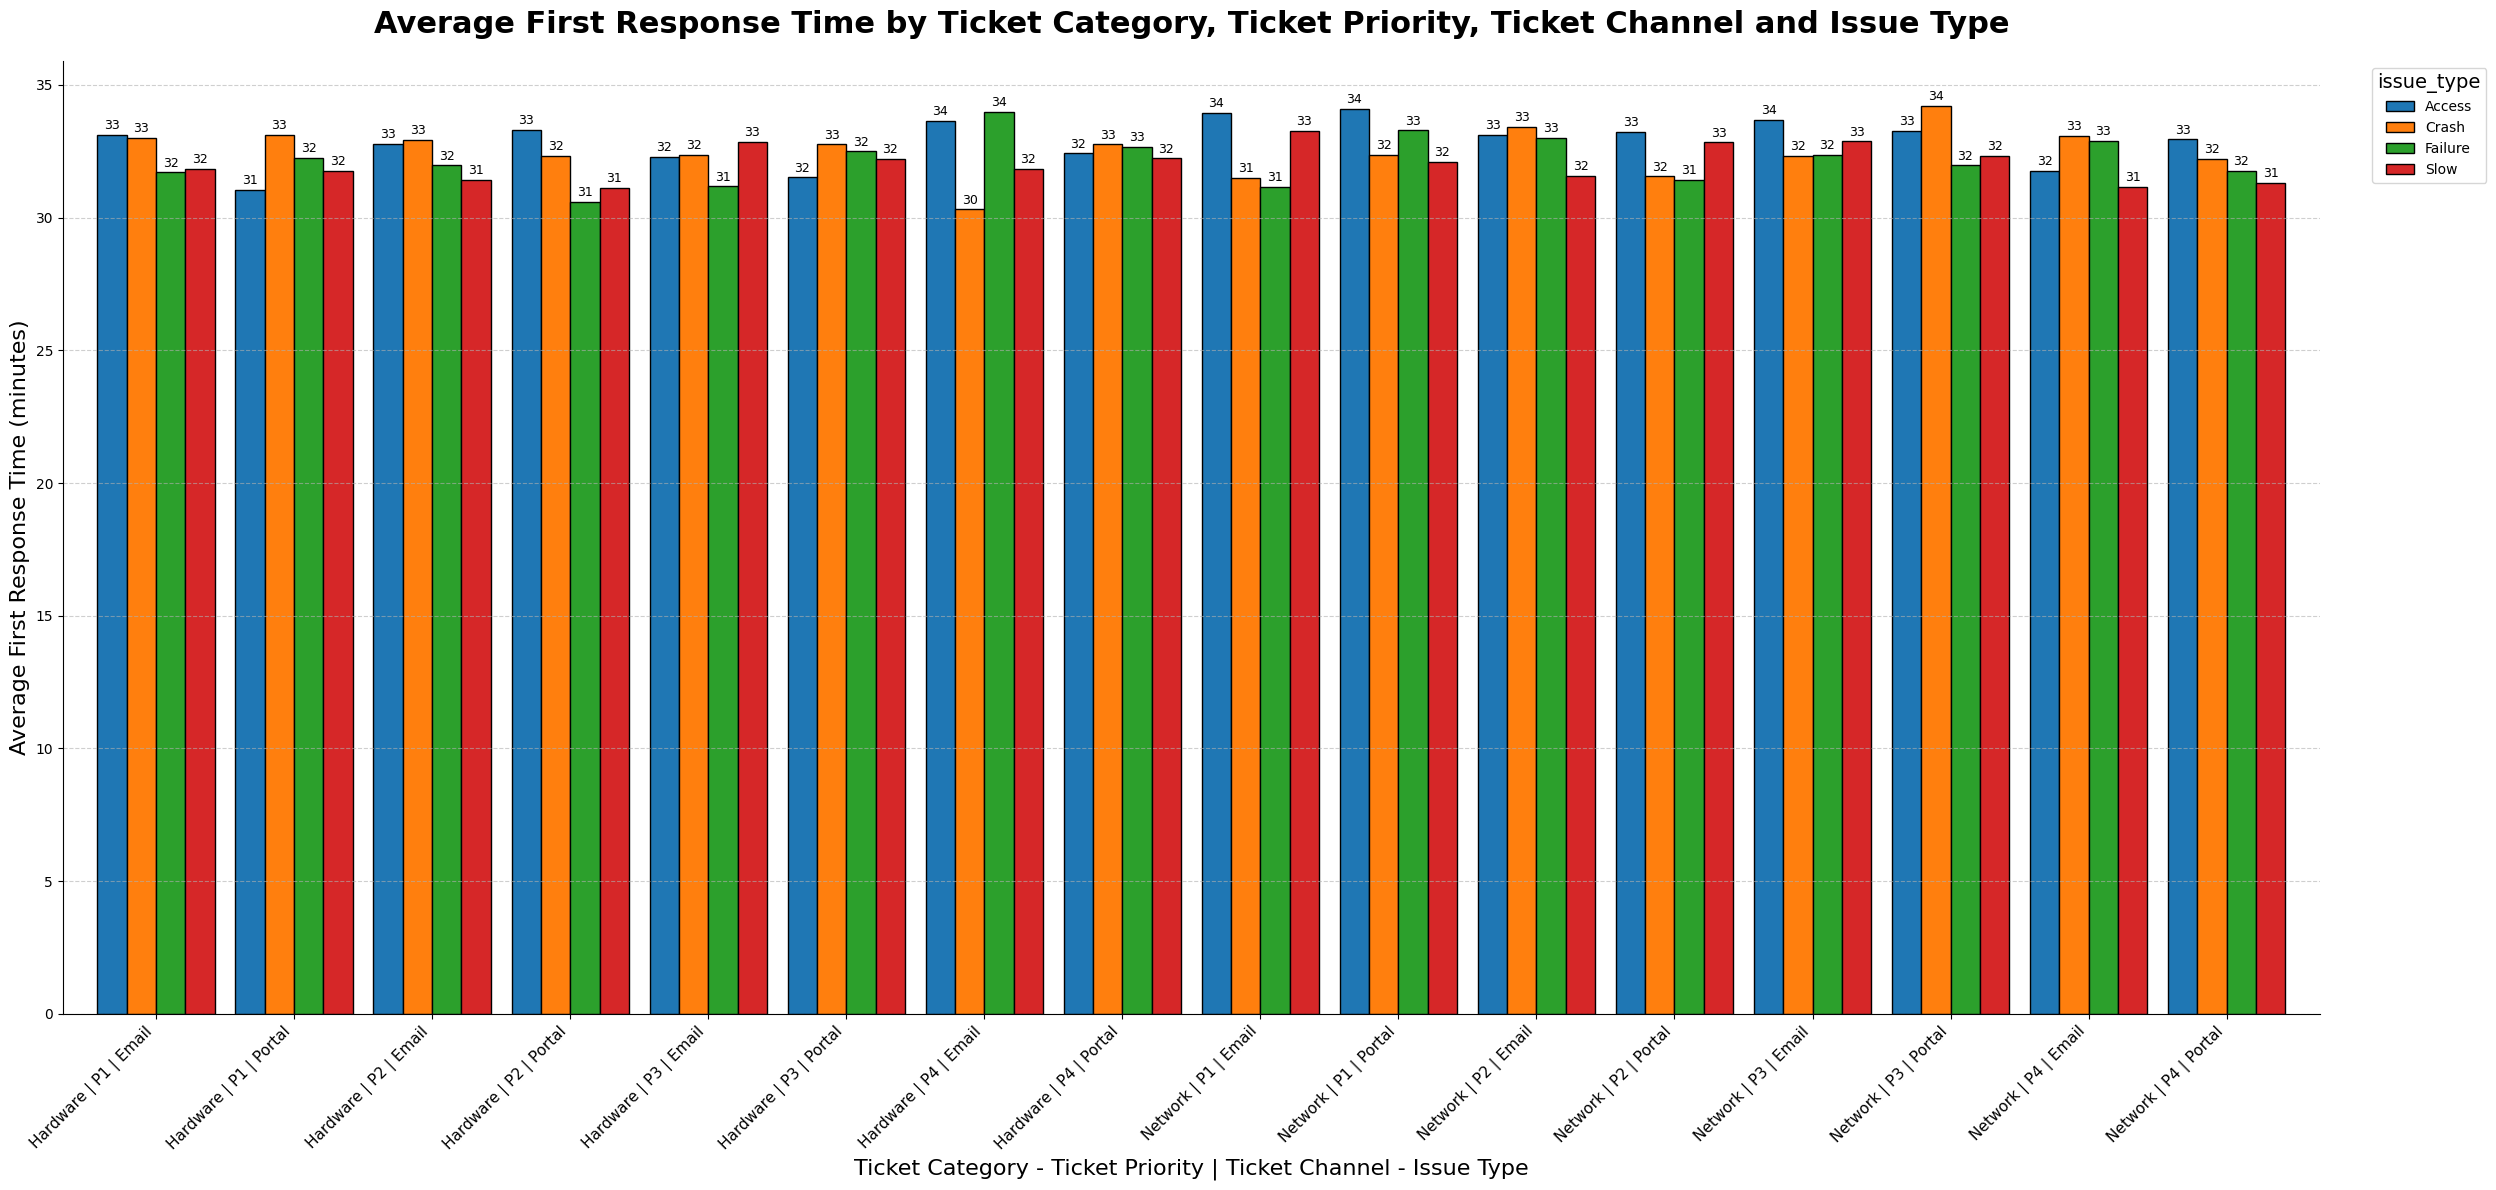

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Average First Response Time by Ticket Category, Ticket Priority, Ticket Channel and Issue Type'}, xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type', ylabel='Average First Response Time (minutes)'>)

In [48]:
plot_grouped_bar(
    df = tickets,
    group_cols = ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type'],
    agg_col = 'first_response_time_minutes',
    agg_func='mean',
    figsize=(25, 12),
    title='Average First Response Time by Ticket Category, Ticket Priority, Ticket Channel and Issue Type',
    xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type',
    ylabel='Average First Response Time (minutes)',
    rotation=45,
    annotate=True
)

In [49]:
rtm = tickets.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['resolution_time_minutes'].mean().reset_index()

rtm.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['resolution_time_minutes'].mean().unstack()

issue_type                                           Access        Crash      Failure         Slow
ticket_category ticket_priority ticket_channel                                                    
Hardware        P1              Email            452.005759   473.426275   473.311104   462.049012
                                Portal           441.911671   464.337027   441.016640   479.547354
                P2              Email            822.289201   880.258804   853.634351   896.731622
                                Portal           911.740414   867.096270   834.670452   844.863910
                P3              Email           1885.603887  1919.313969  1857.080374  1841.382105
                                Portal          1835.464599  1921.822235  1904.457650  1913.444665
                P4              Email           3264.161543  3189.578997  3218.011197  3334.648771
                                Portal          3289.258400  3209.635847  3294.509030  3263.591371
Network         P1              Email            468.956333   466.597618   460.714642   438.341852
                                Portal           437.896467   459.841064   440.896361   447.579456
                P2              Email            852.772516   864.711039   845.437104   861.420792
                                Portal           860.459181   831.222362   879.373429   847.978207
                P3              Email           1892.851016  1856.333379  1937.216939  1893.044087
                                Portal          1873.708805  1863.540989  1969.772583  1897.841682
                P4              Email           3279.685109  3315.463735  3226.931960  3332.061365
                                Portal          3278.867461  3248.474046  3216.794034  3212.642971

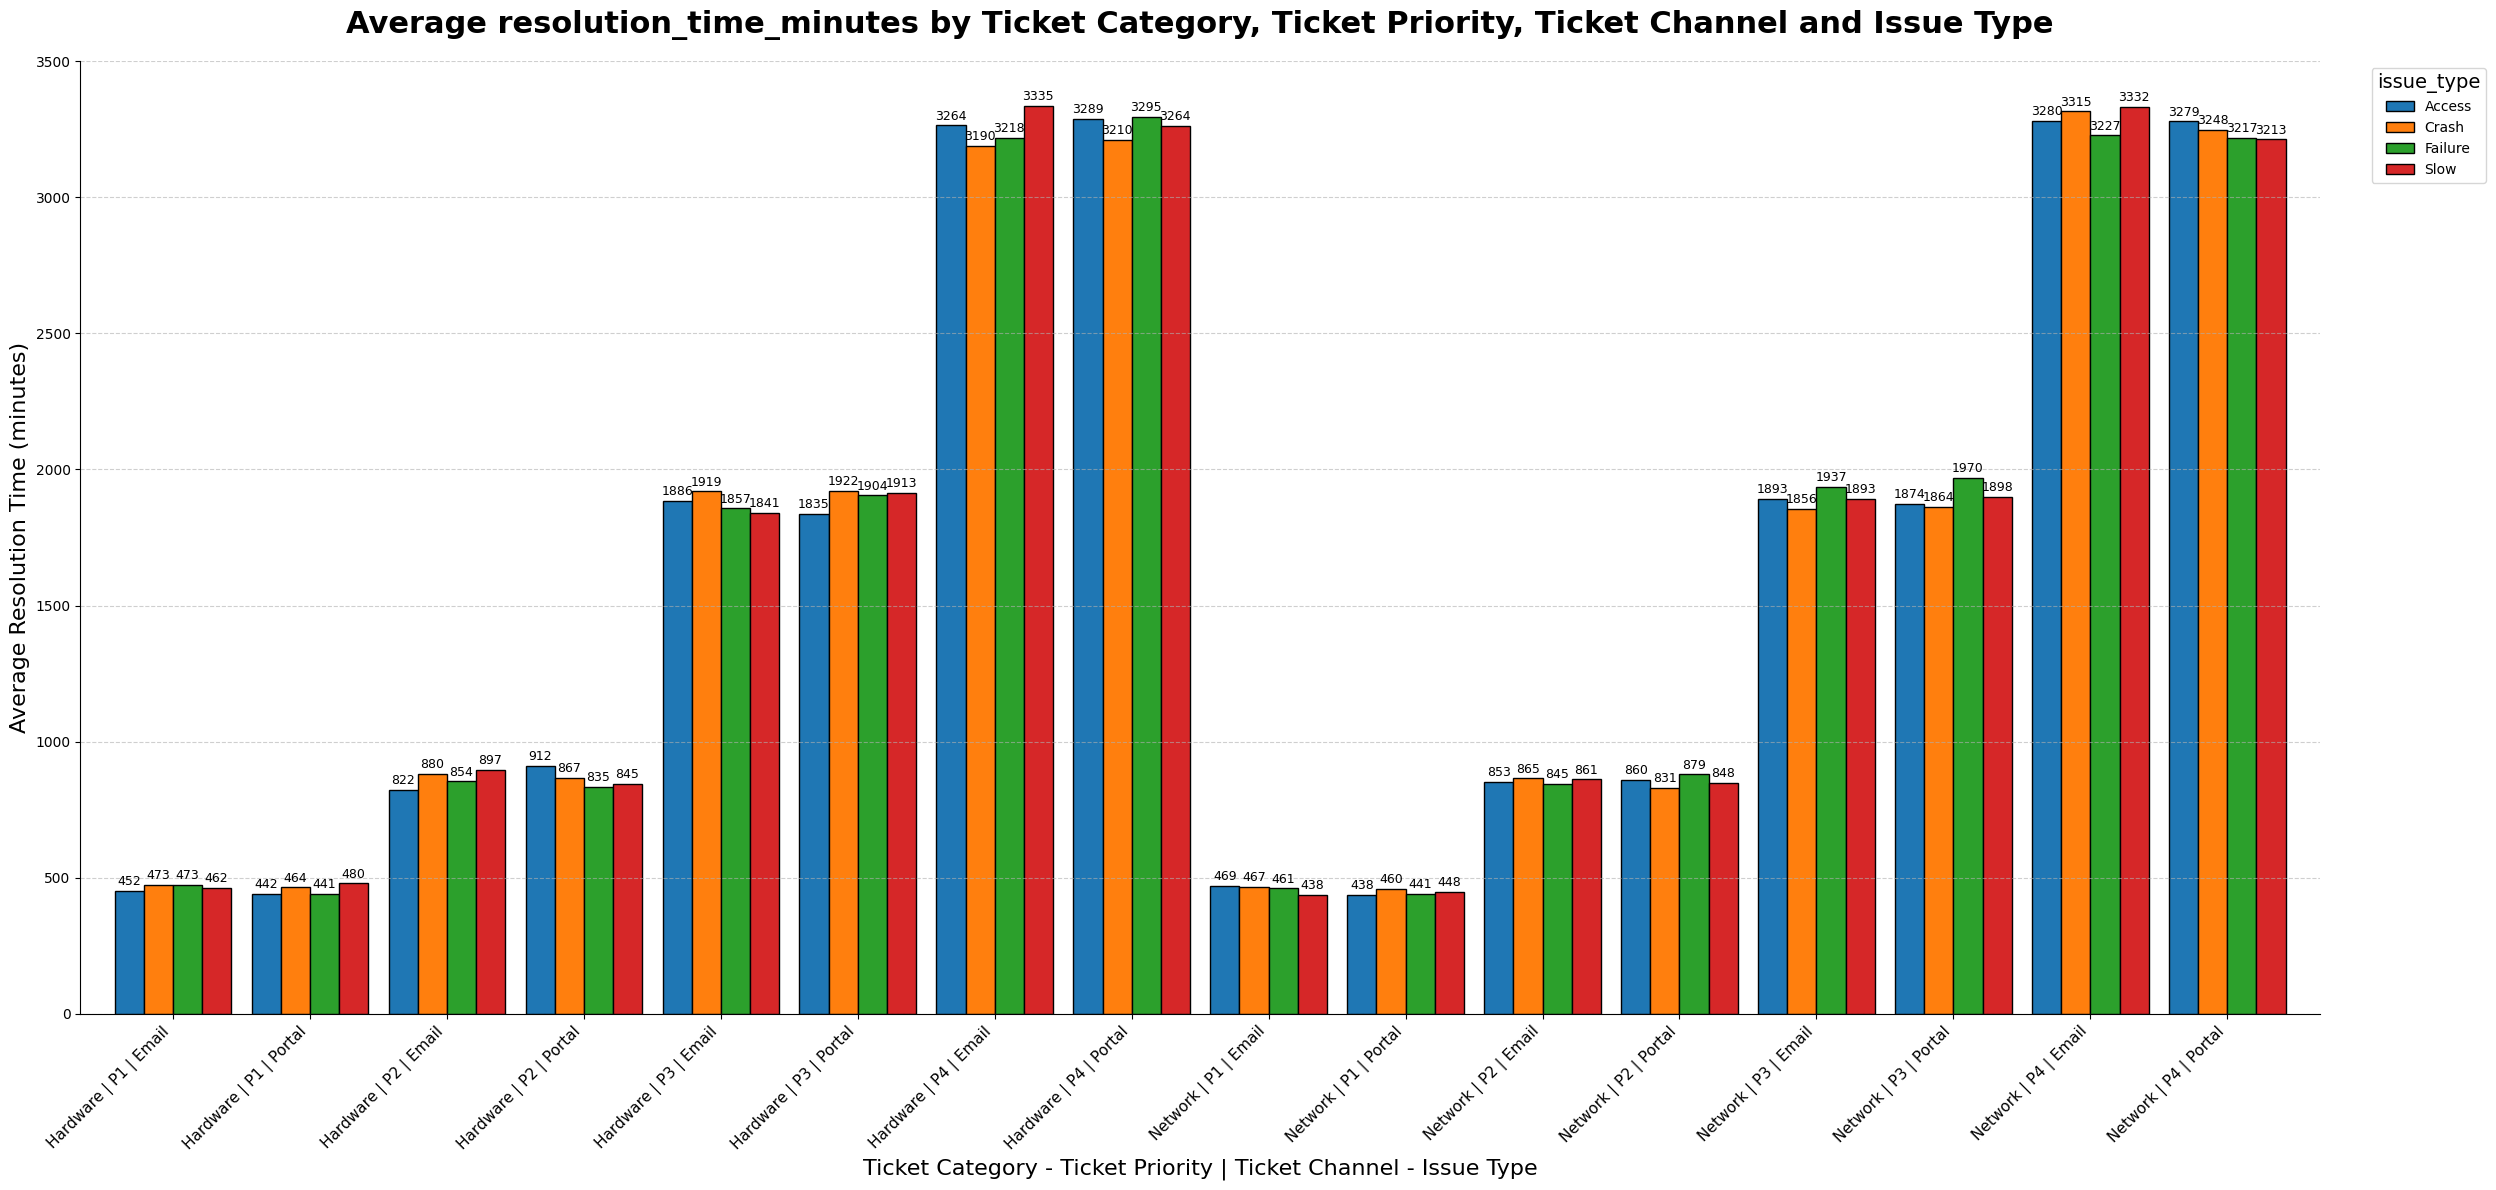

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Average resolution_time_minutes by Ticket Category, Ticket Priority, Ticket Channel and Issue Type'}, xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type', ylabel='Average Resolution Time (minutes)'>)

In [50]:
plot_grouped_bar(
    df = tickets,
    group_cols = ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type'],
    agg_col = 'resolution_time_minutes',
    agg_func='mean',
    figsize=(25, 12),
    title='Average resolution_time_minutes by Ticket Category, Ticket Priority, Ticket Channel and Issue Type',
    xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type',
    ylabel='Average Resolution Time (minutes)',
    rotation=45,
    annotate=True
)

There is lot of scope for improvement in resolution time for P3 and P4 issues. Adding a Reccomendation System to Auto guide can help in fastening the resolution time here.

In [51]:
asset_count = tickets.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['asset_id'].count().reset_index()

asset_count.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['asset_id'].sum().unstack()

issue_type                                      Access  Crash  Failure  Slow
ticket_category ticket_priority ticket_channel                              
Hardware        P1              Email              349    357      335   324
                                Portal             371    370      369   325
                P2              Email              363    368      393   333
                                Portal             338    370      354   335
                P3              Email              337    325      348   361
                                Portal             337    340      349   358
                P4              Email              350    339      376   350
                                Portal             325    354      361   350
Network         P1              Email              330    361      349   324
                                Portal             351    376      360   331
                P2              Email              314    308      335   379
                                Portal             354    326      385   368
                P3              Email              364    367      343   323
                                Portal             318    364      333   333
                P4              Email              368    340      352   337
                                Portal             323    351      352   350

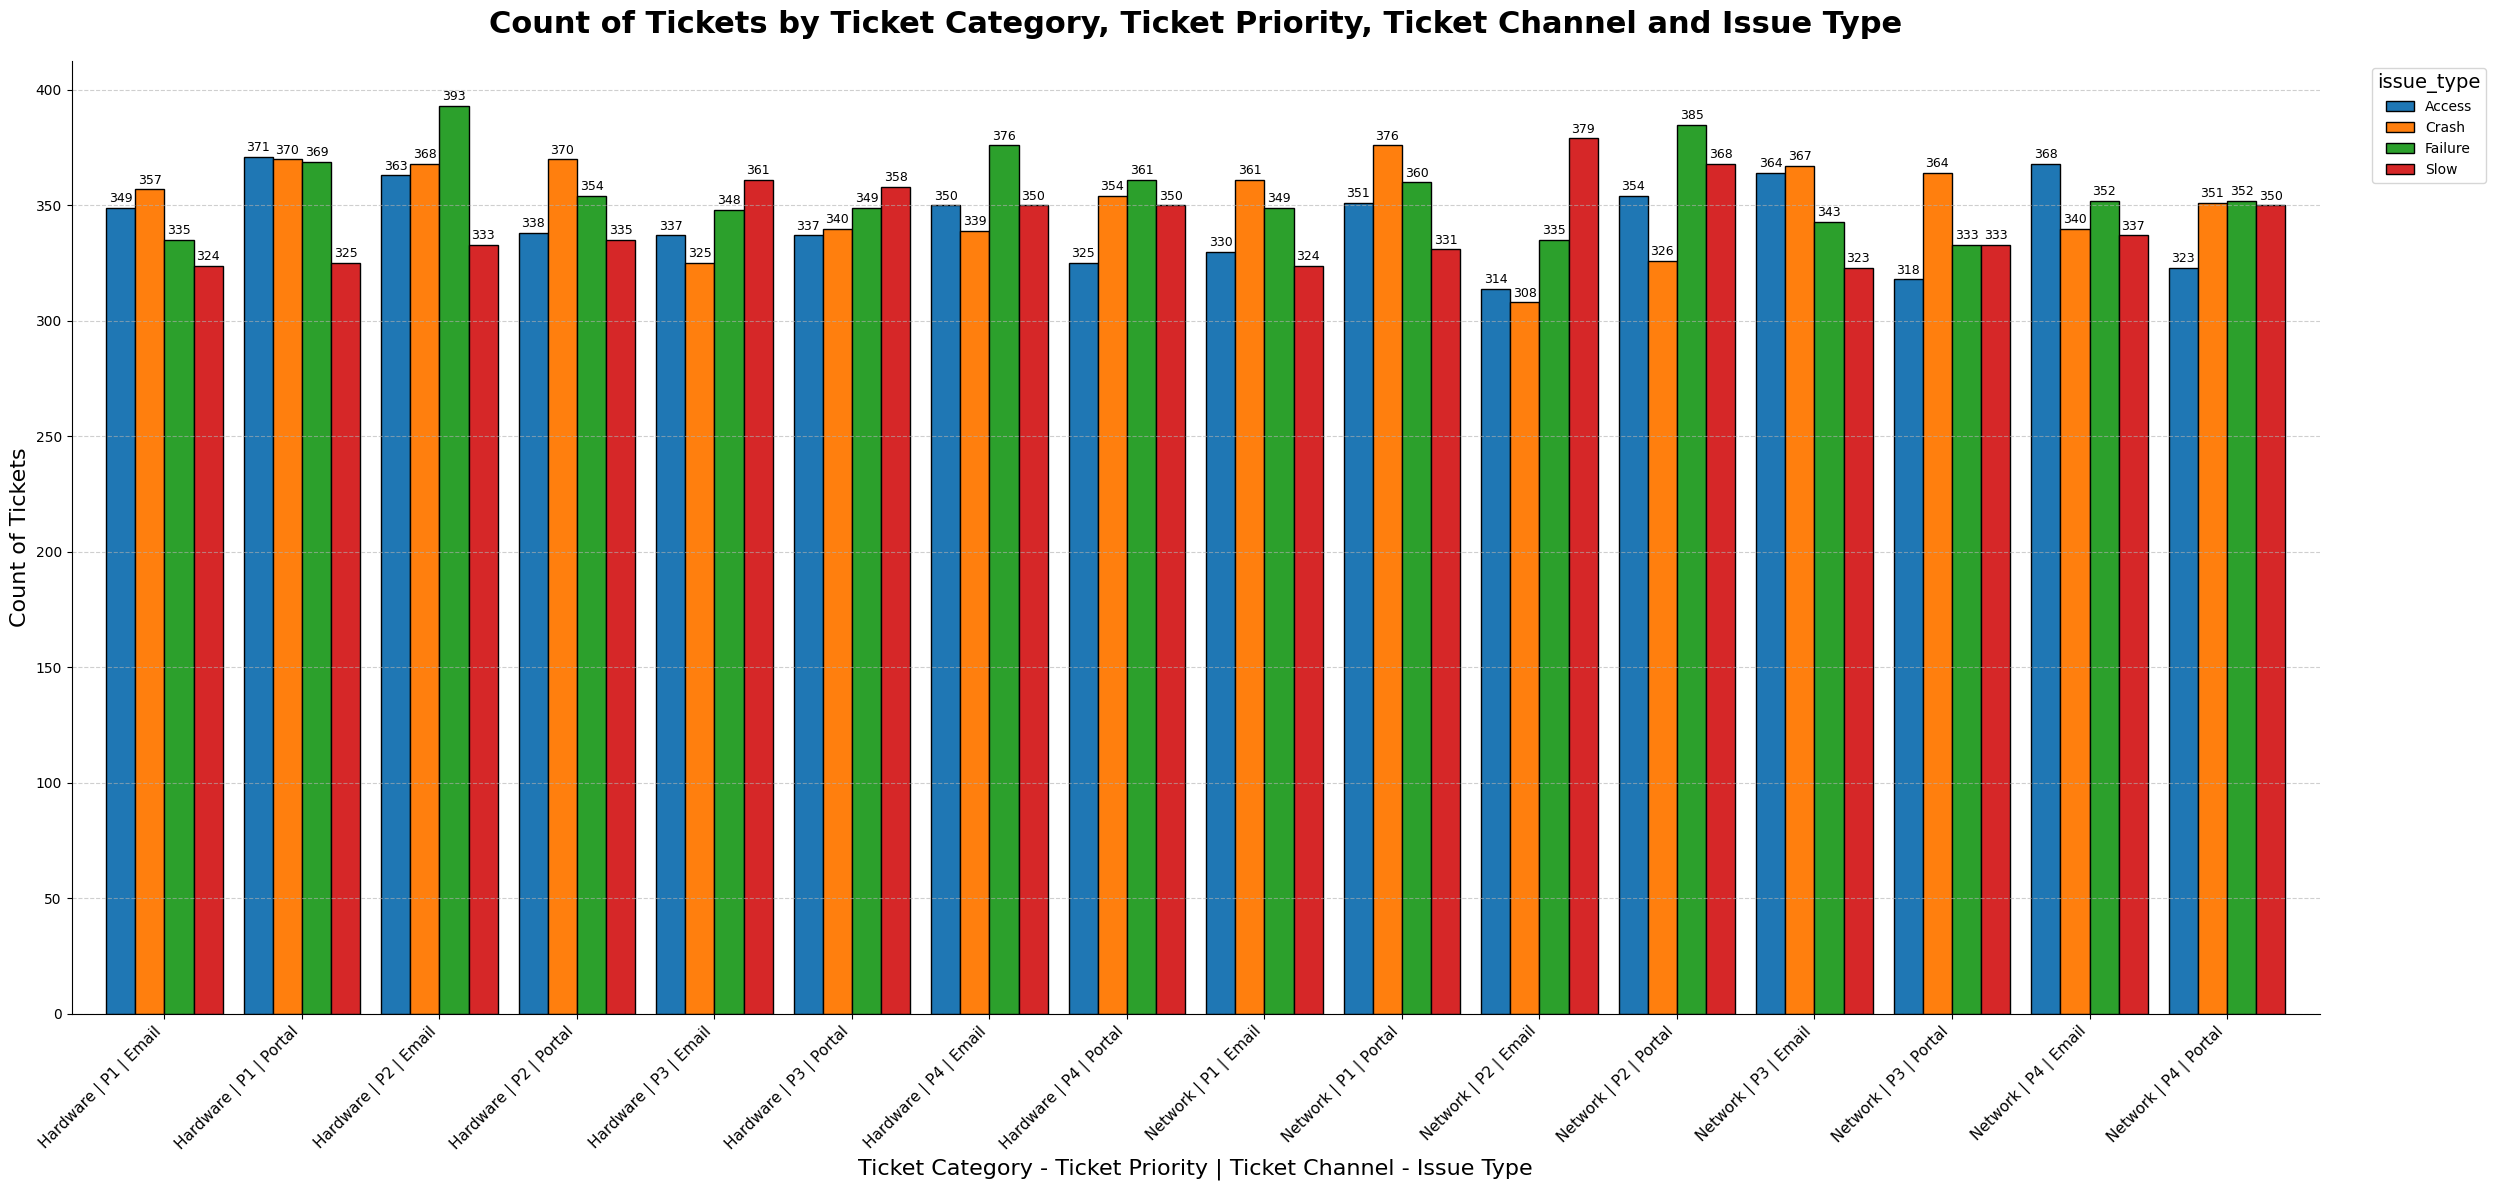

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Count of Tickets by Ticket Category, Ticket Priority, Ticket Channel and Issue Type'}, xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type', ylabel='Count of Tickets'>)

In [52]:
plot_grouped_bar(
    df = tickets,
    group_cols = ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type'],
    agg_col = 'asset_id',
    agg_func='count',
    figsize=(25, 12),
    title='Count of Tickets by Ticket Category, Ticket Priority, Ticket Channel and Issue Type',
    xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type',
    ylabel='Count of Tickets',
    rotation=45,
    annotate=True
)

In [53]:
tof = tickets.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['ticket_reopen_flag'].sum().reset_index()

tof.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['ticket_reopen_flag'].sum().unstack()

issue_type                                      Access  Crash  Failure   Slow
ticket_category ticket_priority ticket_channel                               
Hardware        P1              Email            186.0  189.0    160.0  157.0
                                Portal           178.0  181.0    196.0  158.0
                P2              Email            177.0  189.0    218.0  186.0
                                Portal           173.0  176.0    179.0  183.0
                P3              Email            176.0  156.0    162.0  198.0
                                Portal           164.0  168.0    178.0  169.0
                P4              Email            181.0  183.0    197.0  174.0
                                Portal           165.0  173.0    186.0  160.0
Network         P1              Email            150.0  175.0    186.0  176.0
                                Portal           166.0  198.0    170.0  153.0
                P2              Email            148.0  155.0    167.0  175.0
                                Portal           177.0  163.0    193.0  173.0
                P3              Email            195.0  181.0    171.0  191.0
                                Portal           159.0  179.0    168.0  168.0
                P4              Email            178.0  162.0    180.0  152.0
                                Portal           152.0  149.0    168.0  169.0

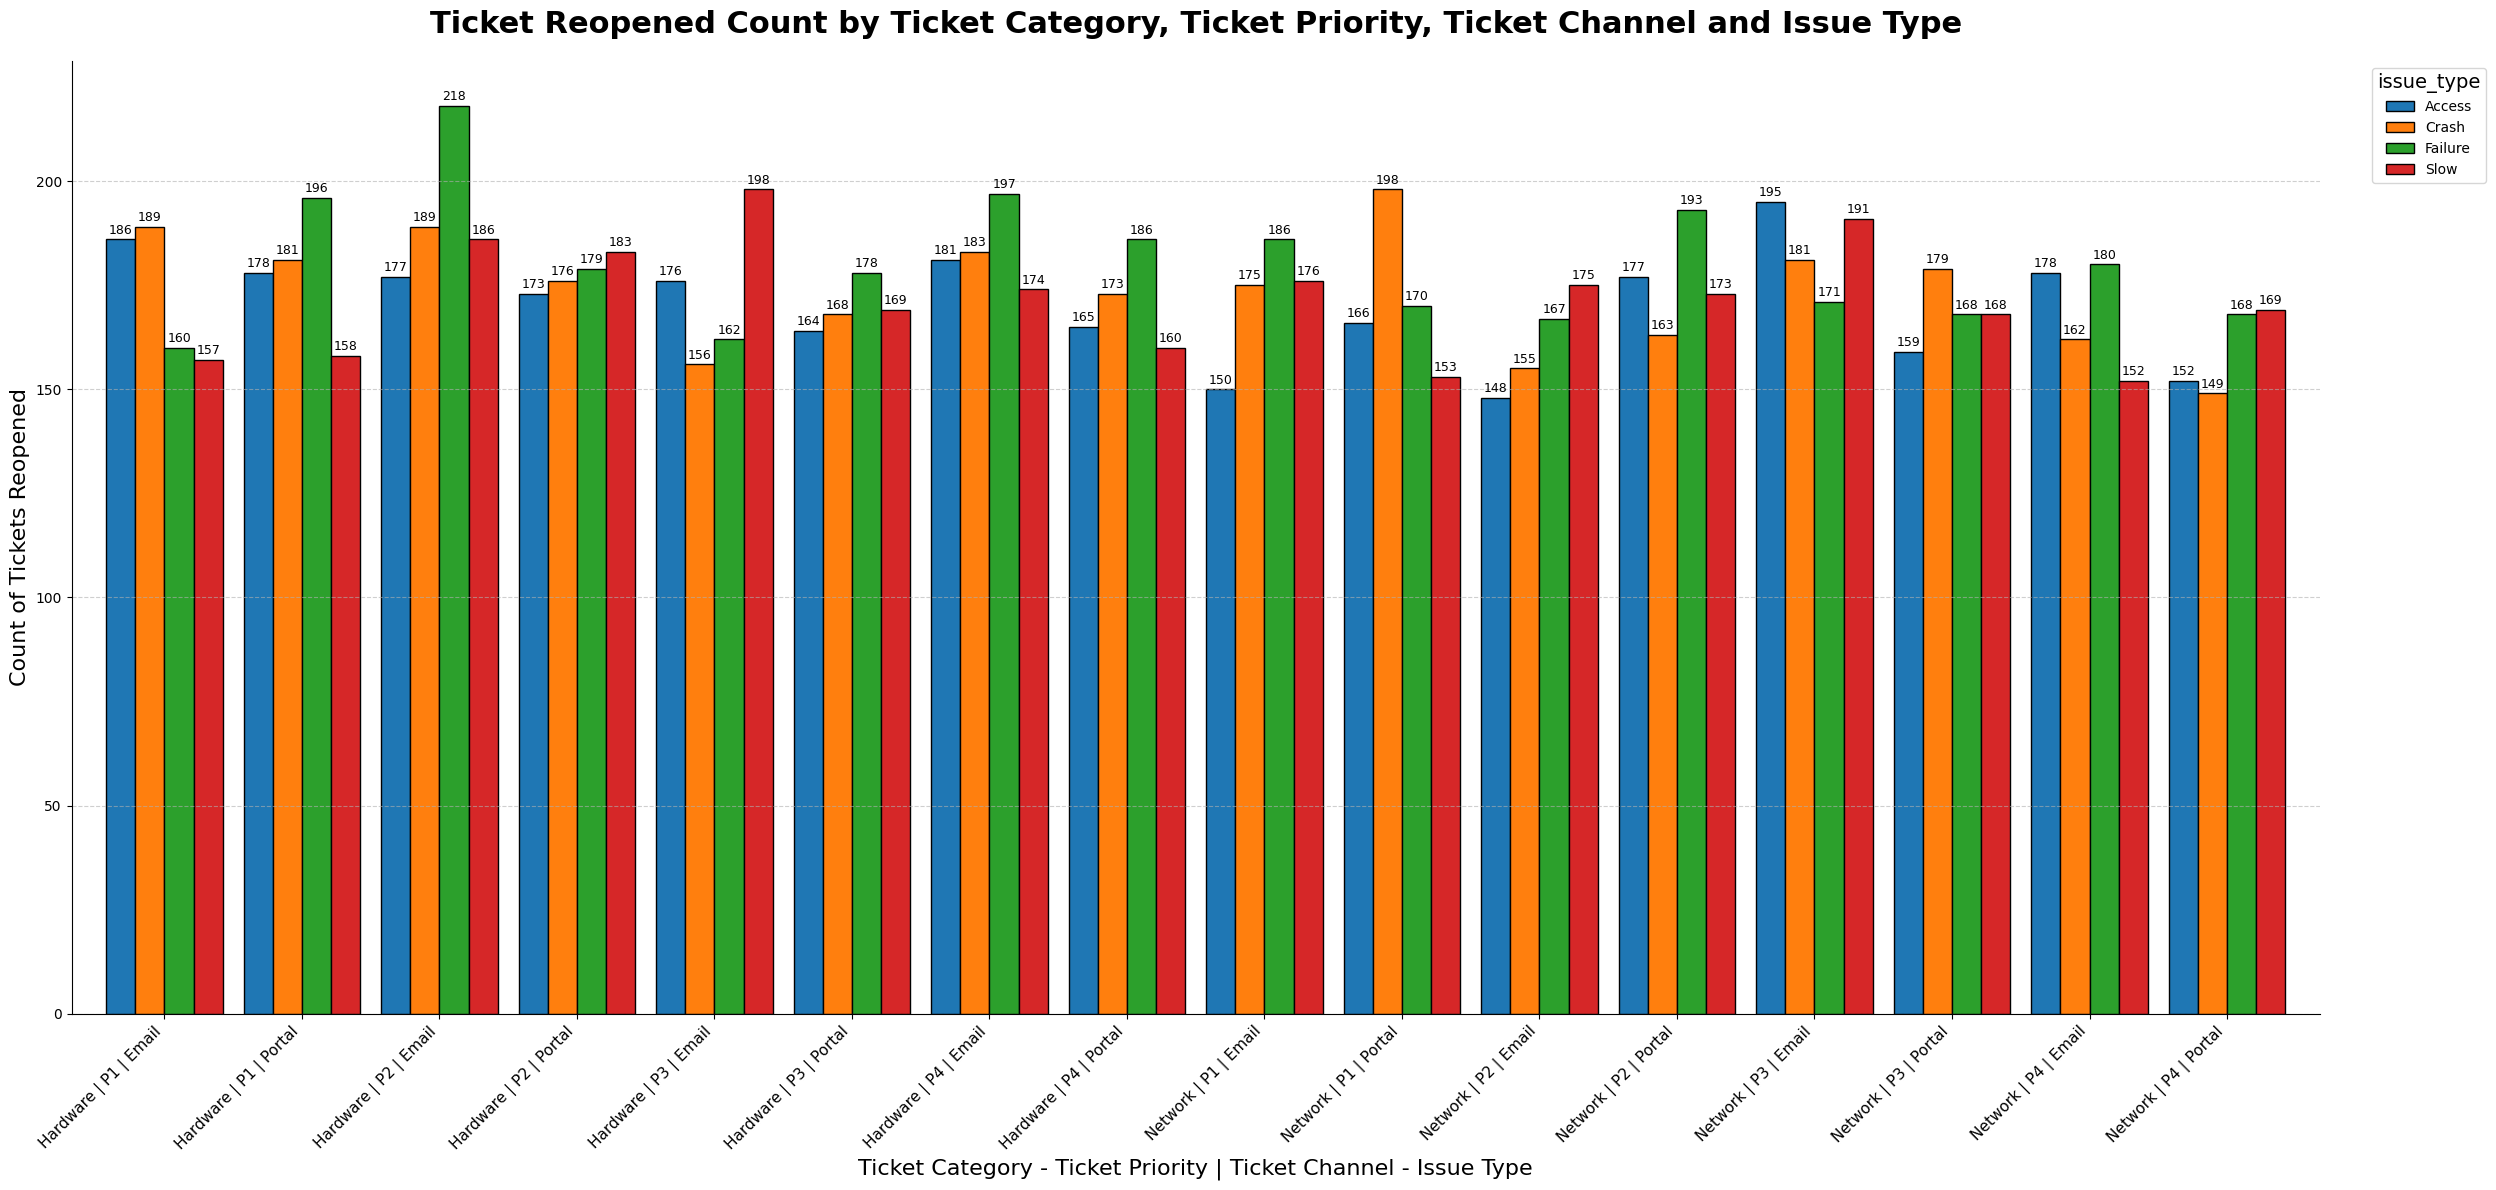

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Ticket Reopened Count by Ticket Category, Ticket Priority, Ticket Channel and Issue Type'}, xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type', ylabel='Count of Tickets Reopened'>)

In [54]:
plot_grouped_bar(
    df = tickets,
    group_cols = ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type'],
    agg_col = 'ticket_reopen_flag',
    agg_func='sum',
    figsize=(25, 12),
    title='Ticket Reopened Count by Ticket Category, Ticket Priority, Ticket Channel and Issue Type',
    xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type',
    ylabel='Count of Tickets Reopened',
    rotation=45,
    annotate=True
)

In [55]:
ef = tickets.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['escalation_flag'].sum().reset_index()

ef.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['escalation_flag'].sum().unstack()

issue_type                                      Access  Crash  Failure   Slow
ticket_category ticket_priority ticket_channel                               
Hardware        P1              Email            143.0  148.0    129.0  128.0
                                Portal           144.0  159.0    140.0  131.0
                P2              Email            140.0  127.0    159.0  134.0
                                Portal           128.0  160.0    150.0  145.0
                P3              Email            120.0  153.0    136.0  148.0
                                Portal           118.0  138.0    142.0  147.0
                P4              Email            138.0  114.0    144.0  159.0
                                Portal           121.0  131.0    134.0  129.0
Network         P1              Email            141.0  153.0    132.0  126.0
                                Portal           129.0  154.0    137.0  127.0
                P2              Email            116.0  119.0    123.0  153.0
                                Portal           144.0  129.0    145.0  136.0
                P3              Email            139.0  134.0    143.0  131.0
                                Portal           130.0  142.0    133.0  127.0
                P4              Email            152.0  137.0    141.0  152.0
                                Portal           140.0  140.0    138.0  136.0

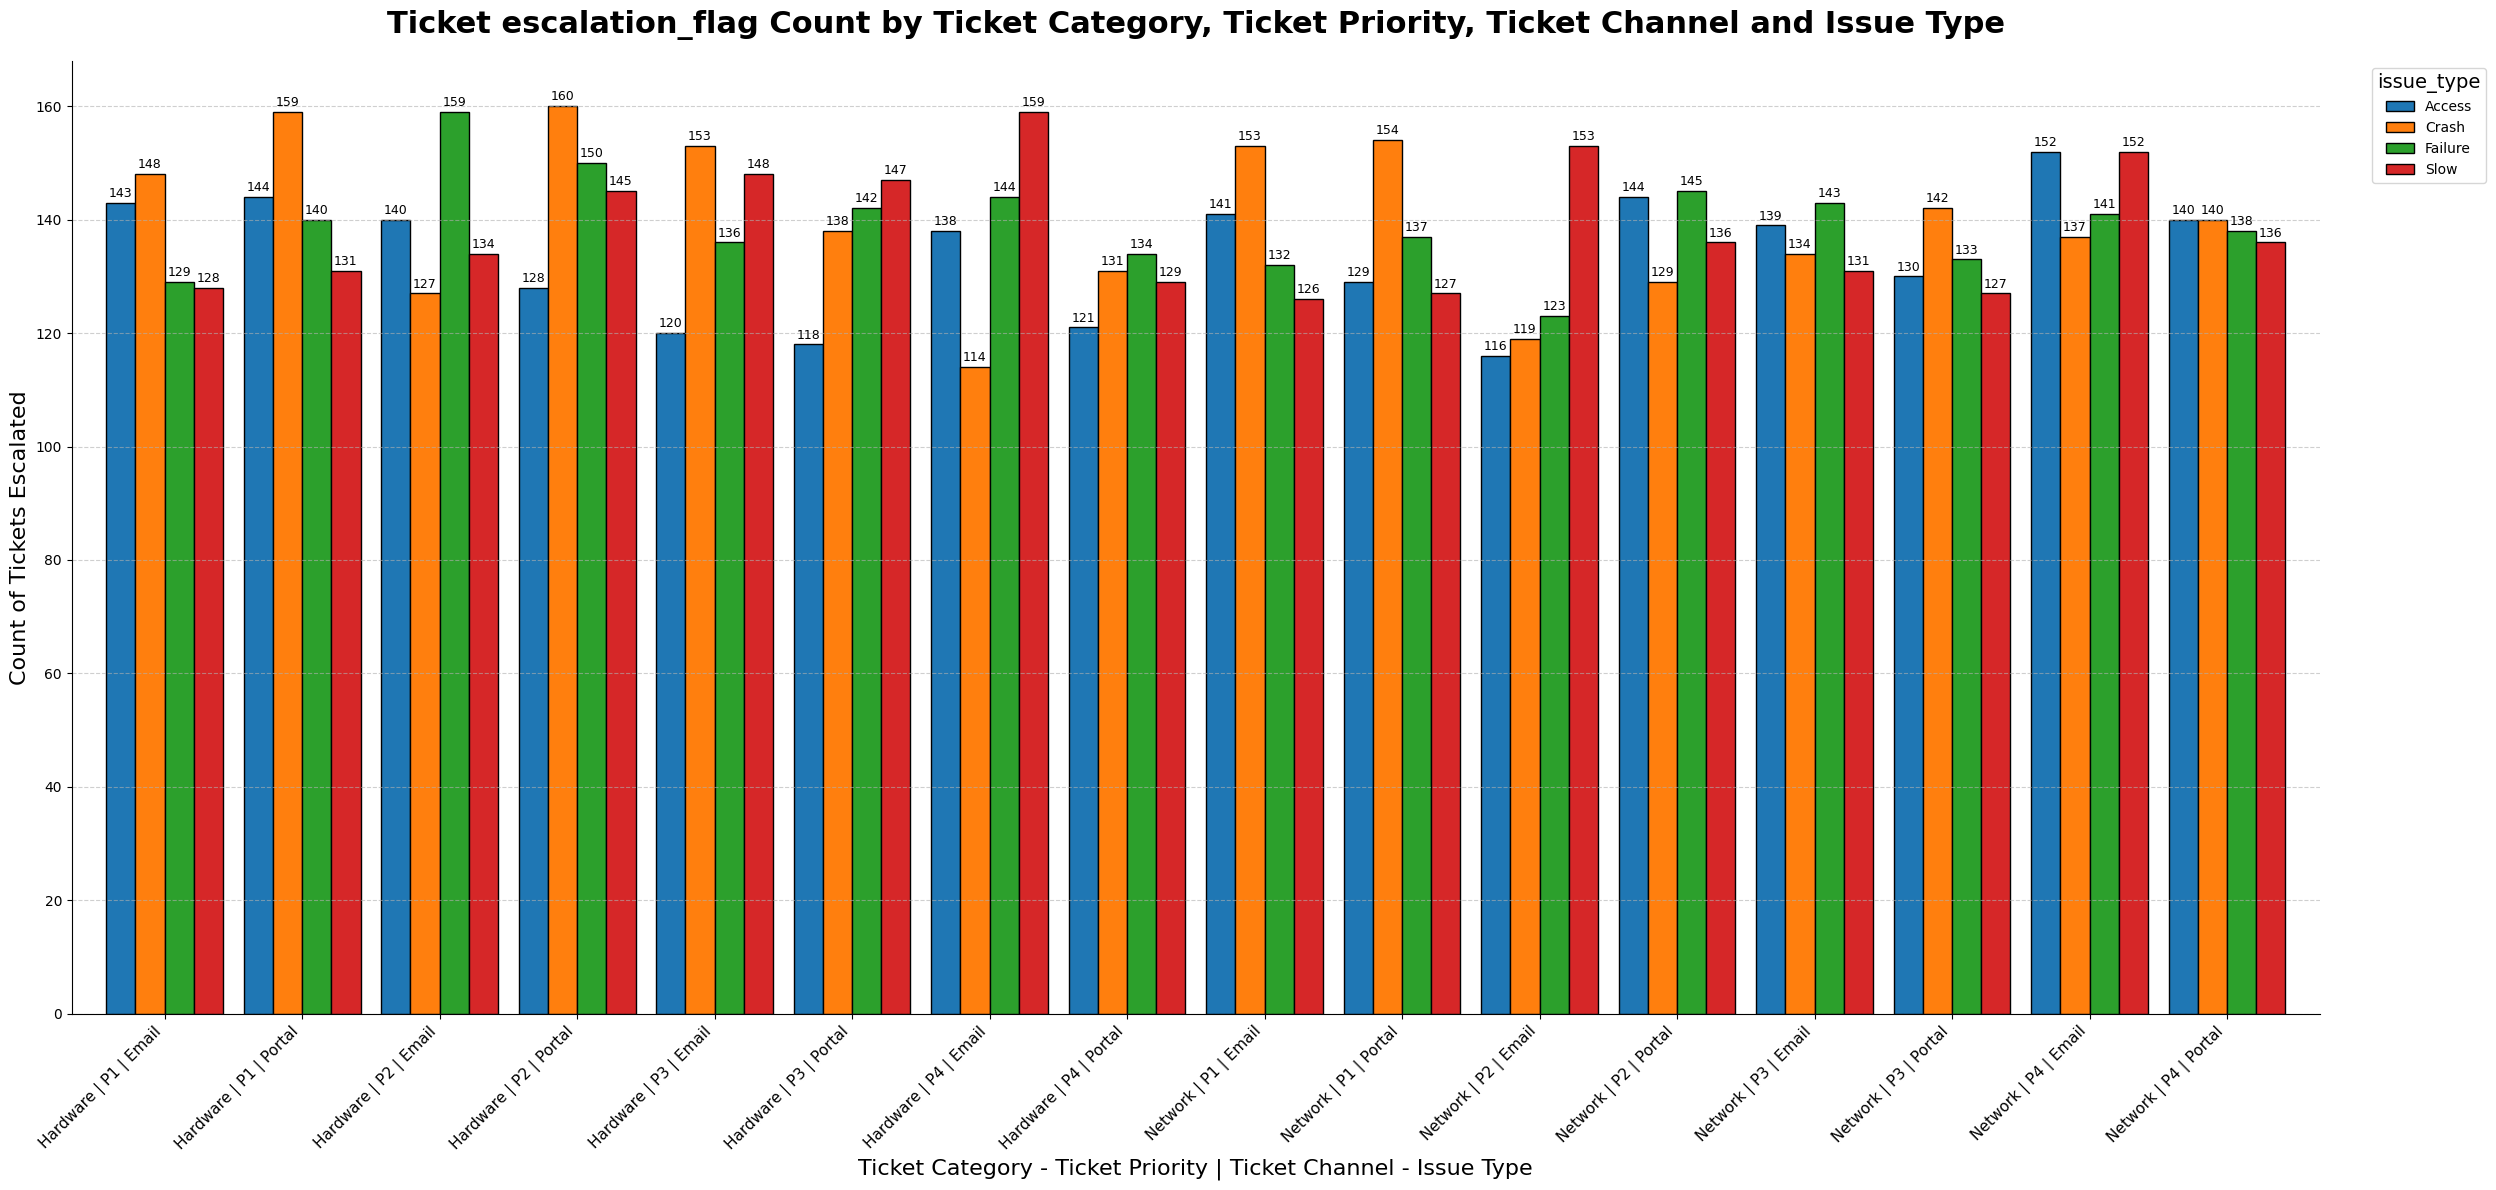

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Ticket escalation_flag Count by Ticket Category, Ticket Priority, Ticket Channel and Issue Type'}, xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type', ylabel='Count of Tickets Escalated'>)

In [56]:
plot_grouped_bar(
    df = tickets,
    group_cols = ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type'],
    agg_col = 'escalation_flag',
    agg_func='sum',
    figsize=(25, 12),
    title='Ticket escalation_flag Count by Ticket Category, Ticket Priority, Ticket Channel and Issue Type',
    xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type',
    ylabel='Count of Tickets Escalated',
    rotation=45,
    annotate=True
)

In [57]:
sbf = tickets.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['sla_breach_flag'].sum().reset_index()

sbf.groupby(
    ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type']
)['sla_breach_flag'].sum().unstack()

issue_type                                      Access  Crash  Failure   Slow
ticket_category ticket_priority ticket_channel                               
Hardware        P1              Email            143.0  148.0    129.0  128.0
                                Portal           144.0  159.0    140.0  131.0
                P2              Email            140.0  127.0    159.0  134.0
                                Portal           128.0  160.0    150.0  145.0
                P3              Email            120.0  153.0    136.0  148.0
                                Portal           118.0  138.0    142.0  147.0
                P4              Email            138.0  114.0    144.0  159.0
                                Portal           121.0  131.0    134.0  129.0
Network         P1              Email            141.0  153.0    132.0  126.0
                                Portal           129.0  154.0    137.0  127.0
                P2              Email            116.0  119.0    123.0  153.0
                                Portal           144.0  129.0    145.0  136.0
                P3              Email            139.0  134.0    143.0  131.0
                                Portal           130.0  142.0    133.0  127.0
                P4              Email            152.0  137.0    141.0  152.0
                                Portal           140.0  140.0    138.0  136.0

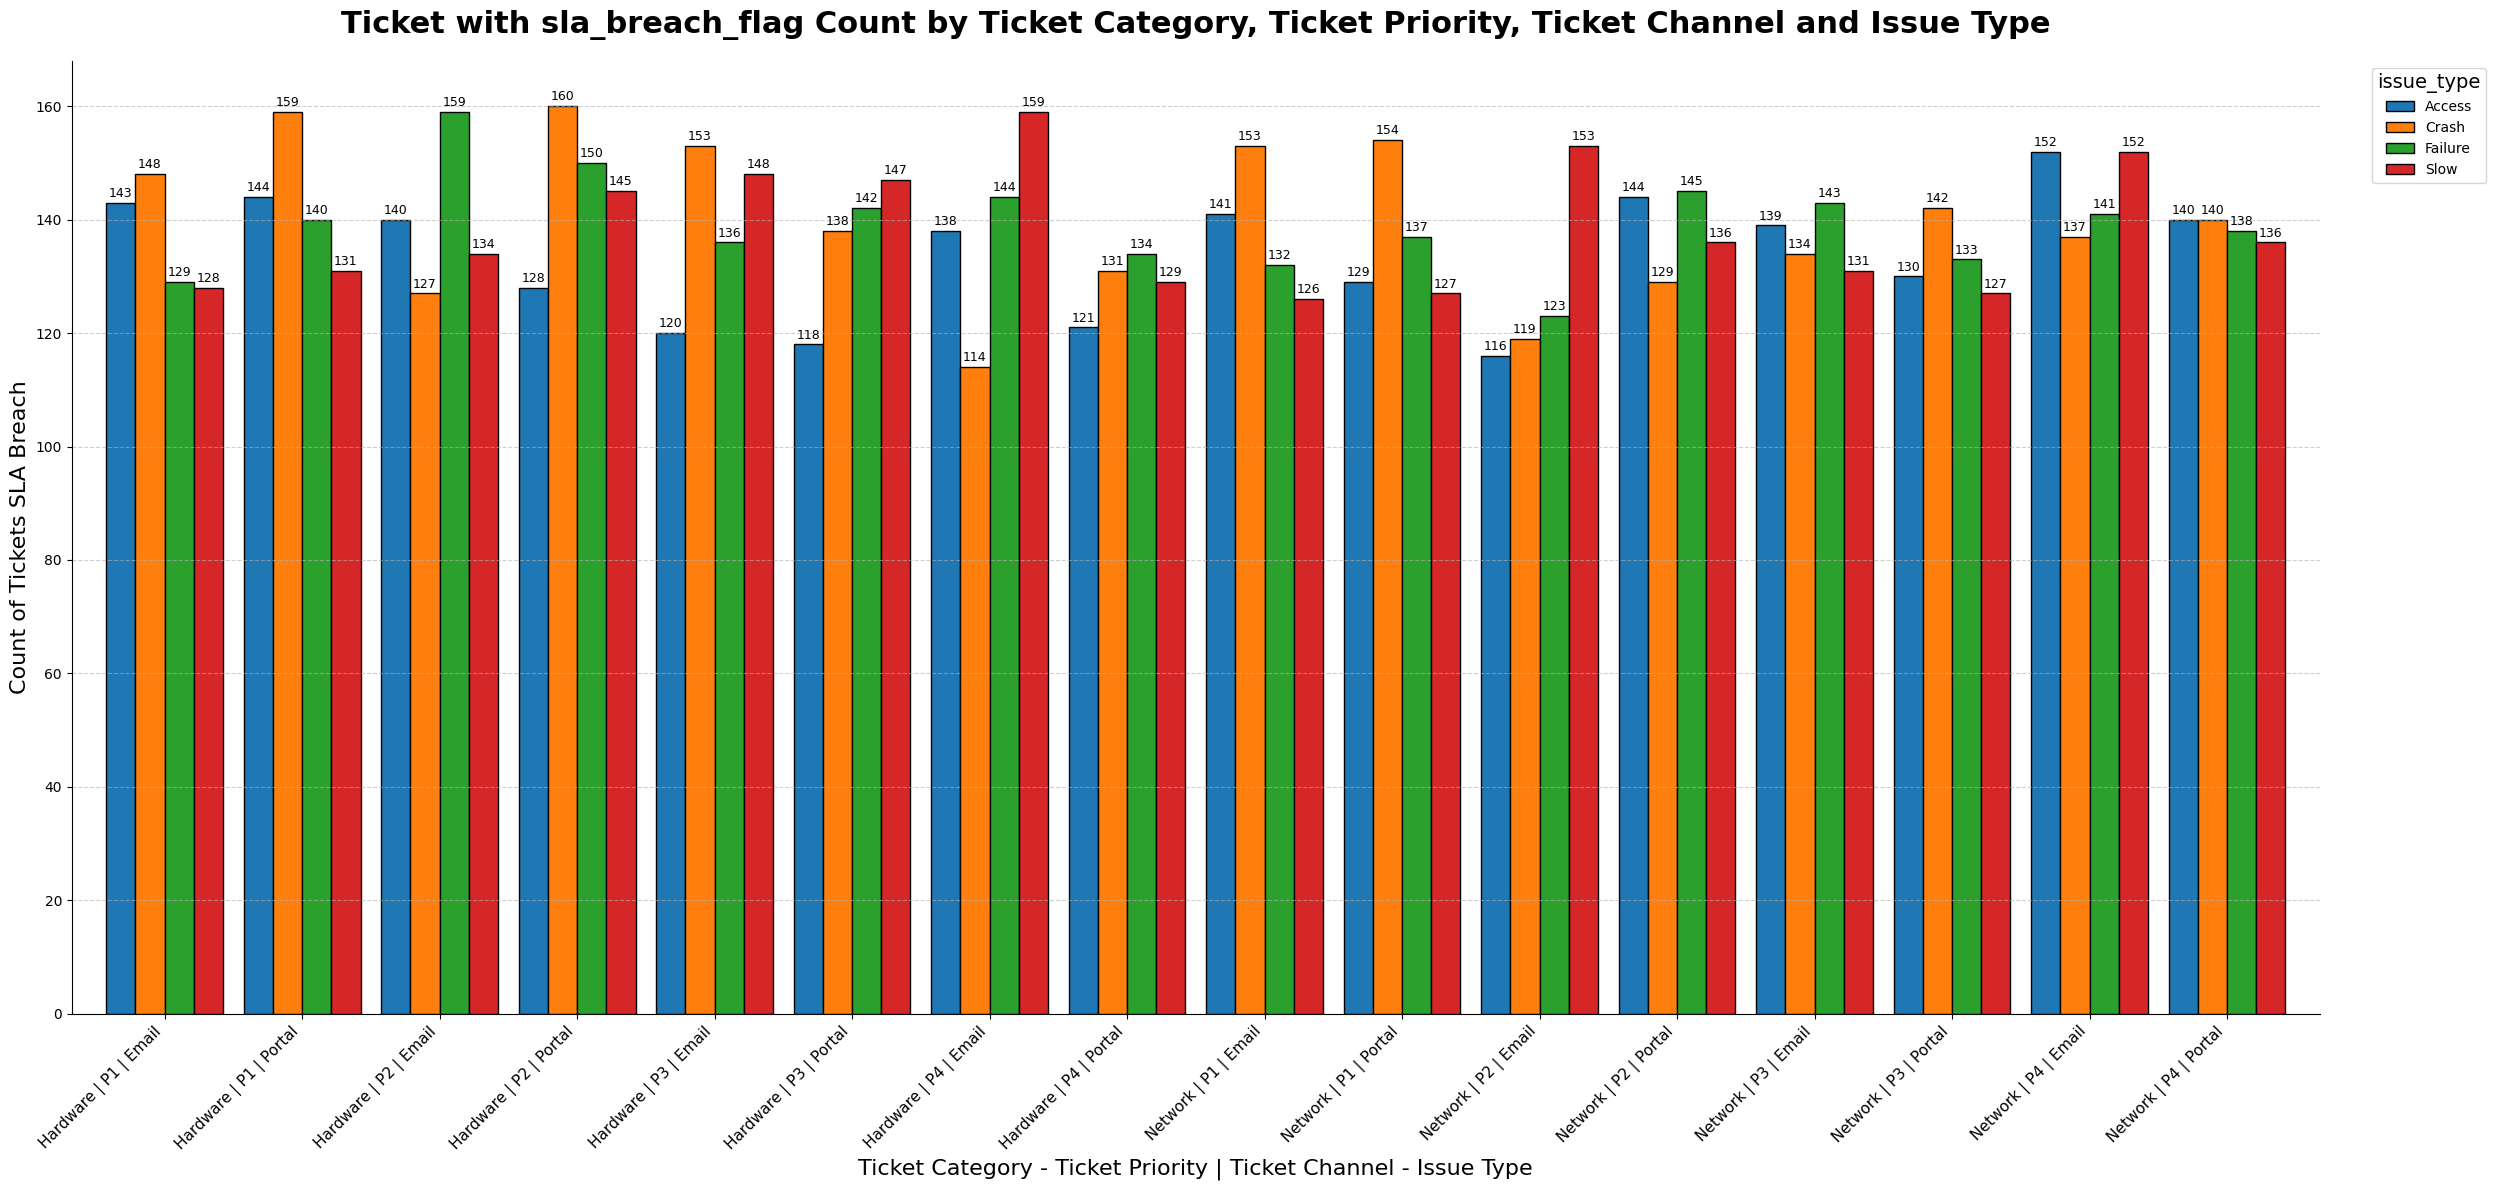

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Ticket with sla_breach_flag Count by Ticket Category, Ticket Priority, Ticket Channel and Issue Type'}, xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type', ylabel='Count of Tickets SLA Breach'>)

In [58]:
plot_grouped_bar(
    df = tickets,
    group_cols = ['ticket_category', 'ticket_priority', 'ticket_channel', 'issue_type'],
    agg_col = 'sla_breach_flag',
    agg_func='sum',
    figsize=(25, 12),
    title='Ticket with sla_breach_flag Count by Ticket Category, Ticket Priority, Ticket Channel and Issue Type',
    xlabel='Ticket Category - Ticket Priority | Ticket Channel - Issue Type',
    ylabel='Count of Tickets SLA Breach',
    rotation=45,
    annotate=True
)

### Assets EDA

In [59]:
assets.head()

,asset_id,device_type,manufacturer,model_number,client_id,installation_date,warranty_expiry_date,criticality_level,active_year,file_year
0,AID_053,Switch,Cisco,M001,C013,2022-11-07,2025-11-06,Medium,2023,2023
1,AID_027,Router,HP,M003,C003,2022-05-28,2025-05-27,Medium,2023,2023
2,AID_028,Router,HP,M004,C017,2022-06-21,2025-06-20,Medium,2023,2023
3,AID_031,Router,Fortinet,M003,C018,2022-11-27,2025-11-26,Medium,2023,2023
4,AID_034,Firewall,Dell,M002,C009,2022-01-04,2025-01-03,High,2023,2023


In [60]:
client_count = assets.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['client_id'].count().reset_index()

client_count.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['client_id'].sum().unstack()

model_number              M001  M002  M003  M004
device_type manufacturer                        
Firewall    Cisco            6     7    11     3
            Dell            14     5    12     5
            Fortinet         6     4     5     8
            HP              12     9     7     5
Router      Cisco            6     9     9    10
            Dell             4    10     8     3
            Fortinet         5     7     7    11
            HP               5    10     7     9
Server      Cisco            7    11     8     8
            Dell             5     8     4     5
            Fortinet         9     8     9     9
            HP              10    10     6     4
Switch      Cisco            8     2     6     9
            Dell             4    10     4     1
            Fortinet         5     5     7     2
            HP               7     3     7     7

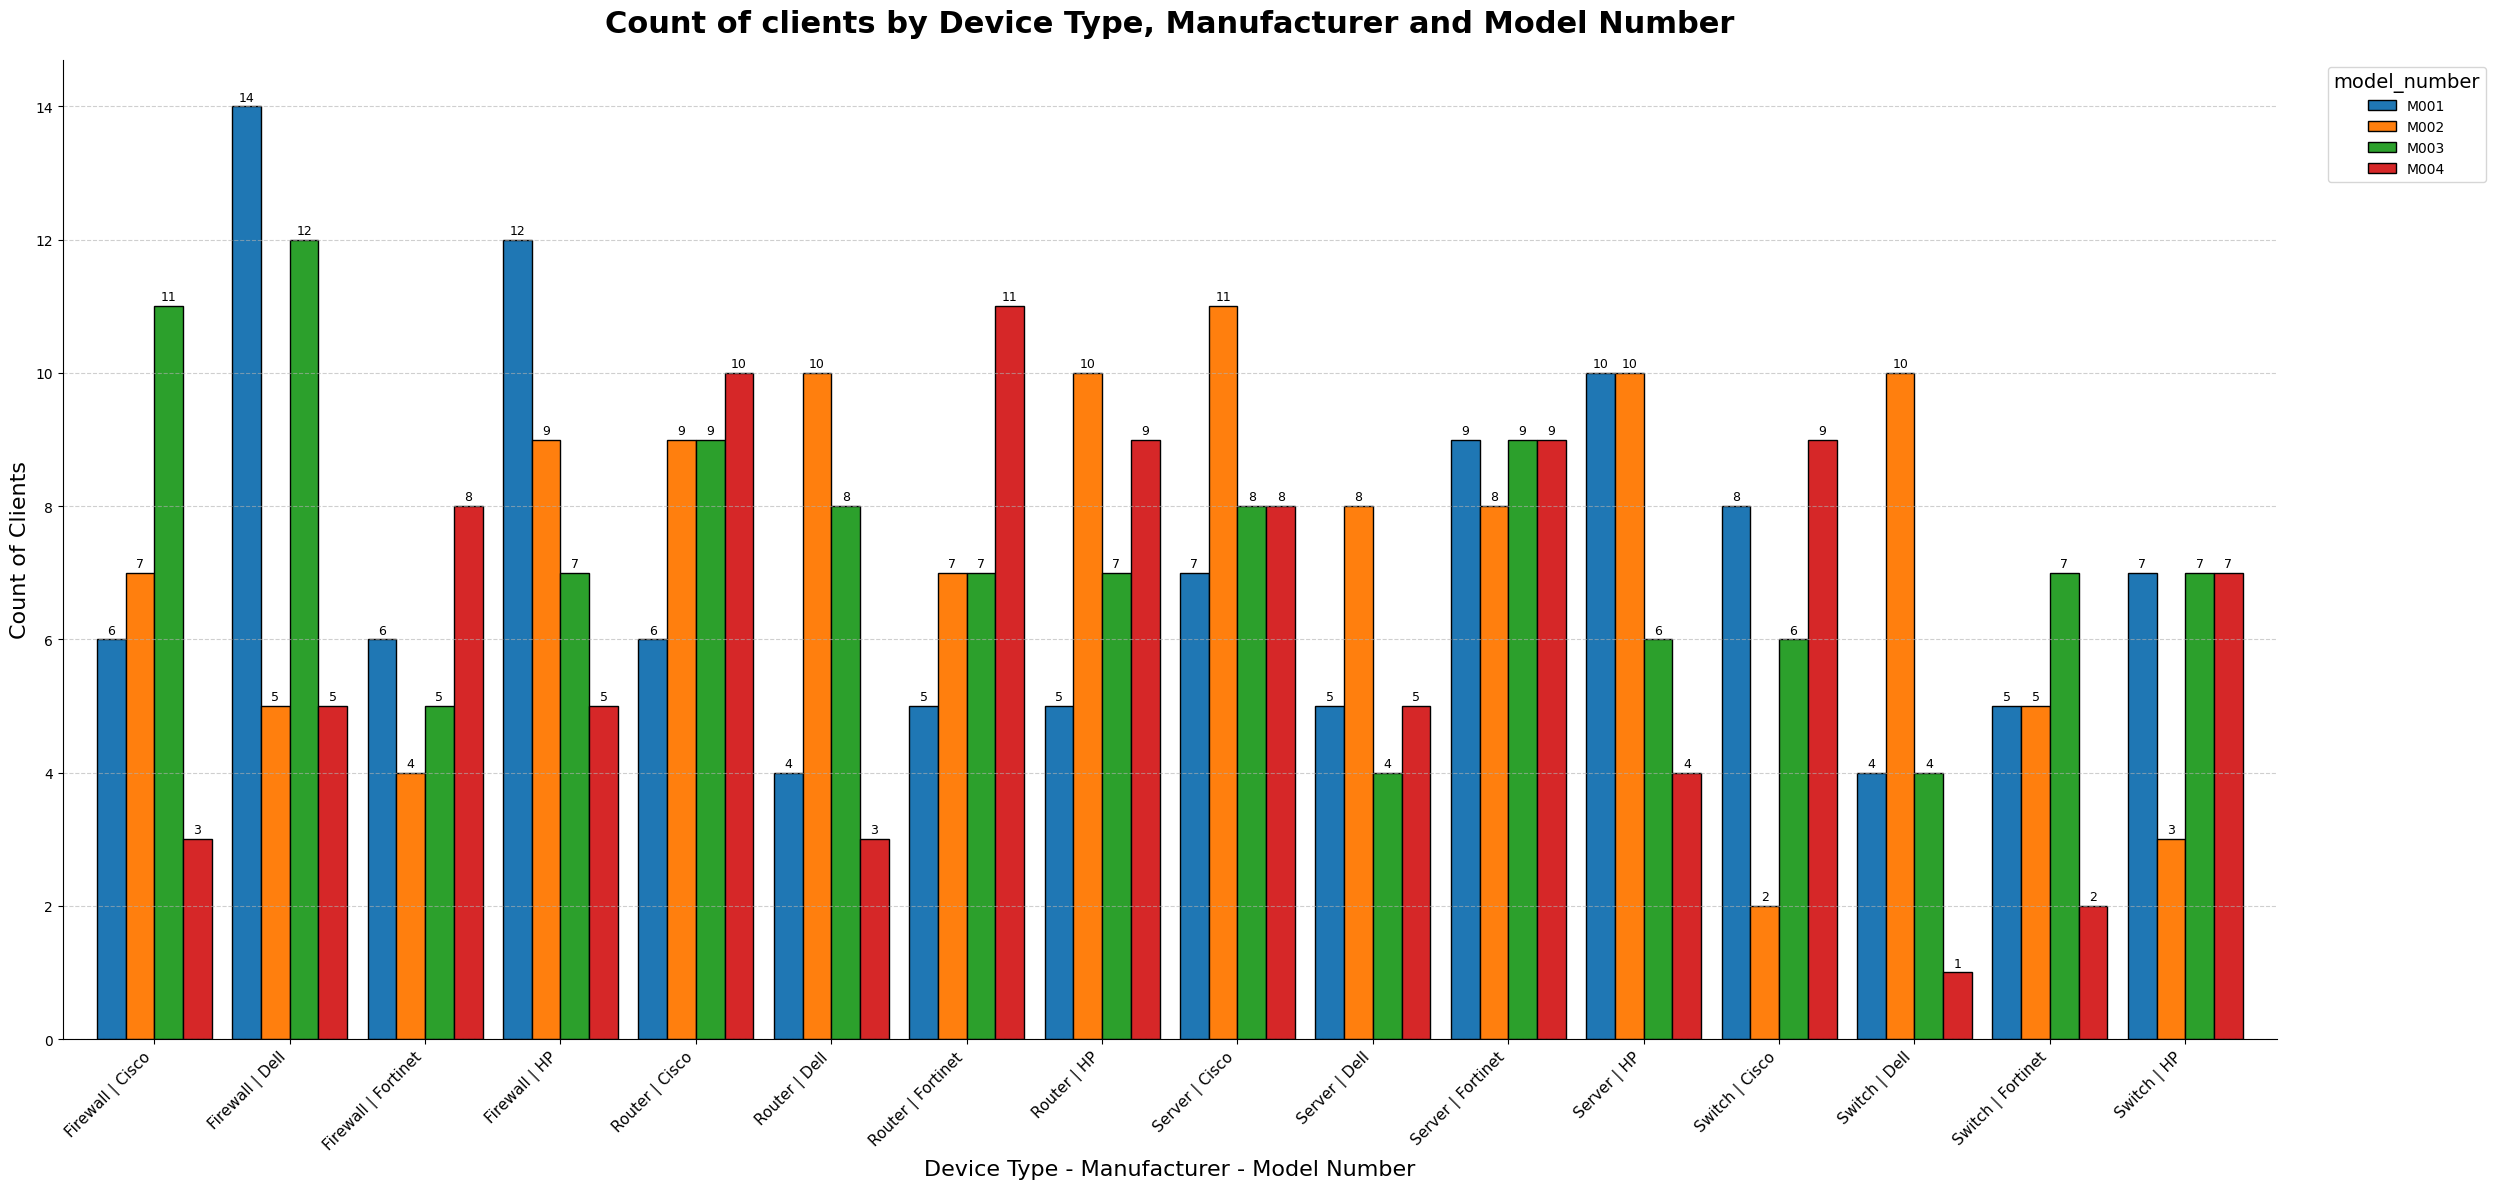

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Count of clients by Device Type, Manufacturer and Model Number'}, xlabel='Device Type - Manufacturer - Model Number', ylabel='Count of Clients'>)

In [61]:
plot_grouped_bar(
    df = assets,
    group_cols = ['device_type', 'manufacturer', 'model_number'],
    agg_col = 'client_id',
    agg_func='count',
    figsize=(25, 12),
    title='Count of clients by Device Type, Manufacturer and Model Number',
    xlabel='Device Type - Manufacturer - Model Number',
    ylabel='Count of Clients',
    rotation=45,
    annotate=True
)

In [62]:
client_count = assets.groupby(
    ['device_type', 'manufacturer', 'active_year']
)['client_id'].count().reset_index()

client_count.groupby(
    ['device_type', 'manufacturer', 'active_year']
)['client_id'].sum().unstack()

active_year               2023  2024  2025
device_type manufacturer                  
Firewall    Cisco           12     8     7
            Dell            14    12    10
            Fortinet         9     6     8
            HP              16    11     6
Router      Cisco           10     8    16
            Dell            10     8     7
            Fortinet        10    12     8
            HP               7    12    12
Server      Cisco           16     9     9
            Dell             6    11     5
            Fortinet         6    12    17
            HP               7    13    10
Switch      Cisco           12     7     6
            Dell             4     6     9
            Fortinet         7     5     7
            HP               3     9    12

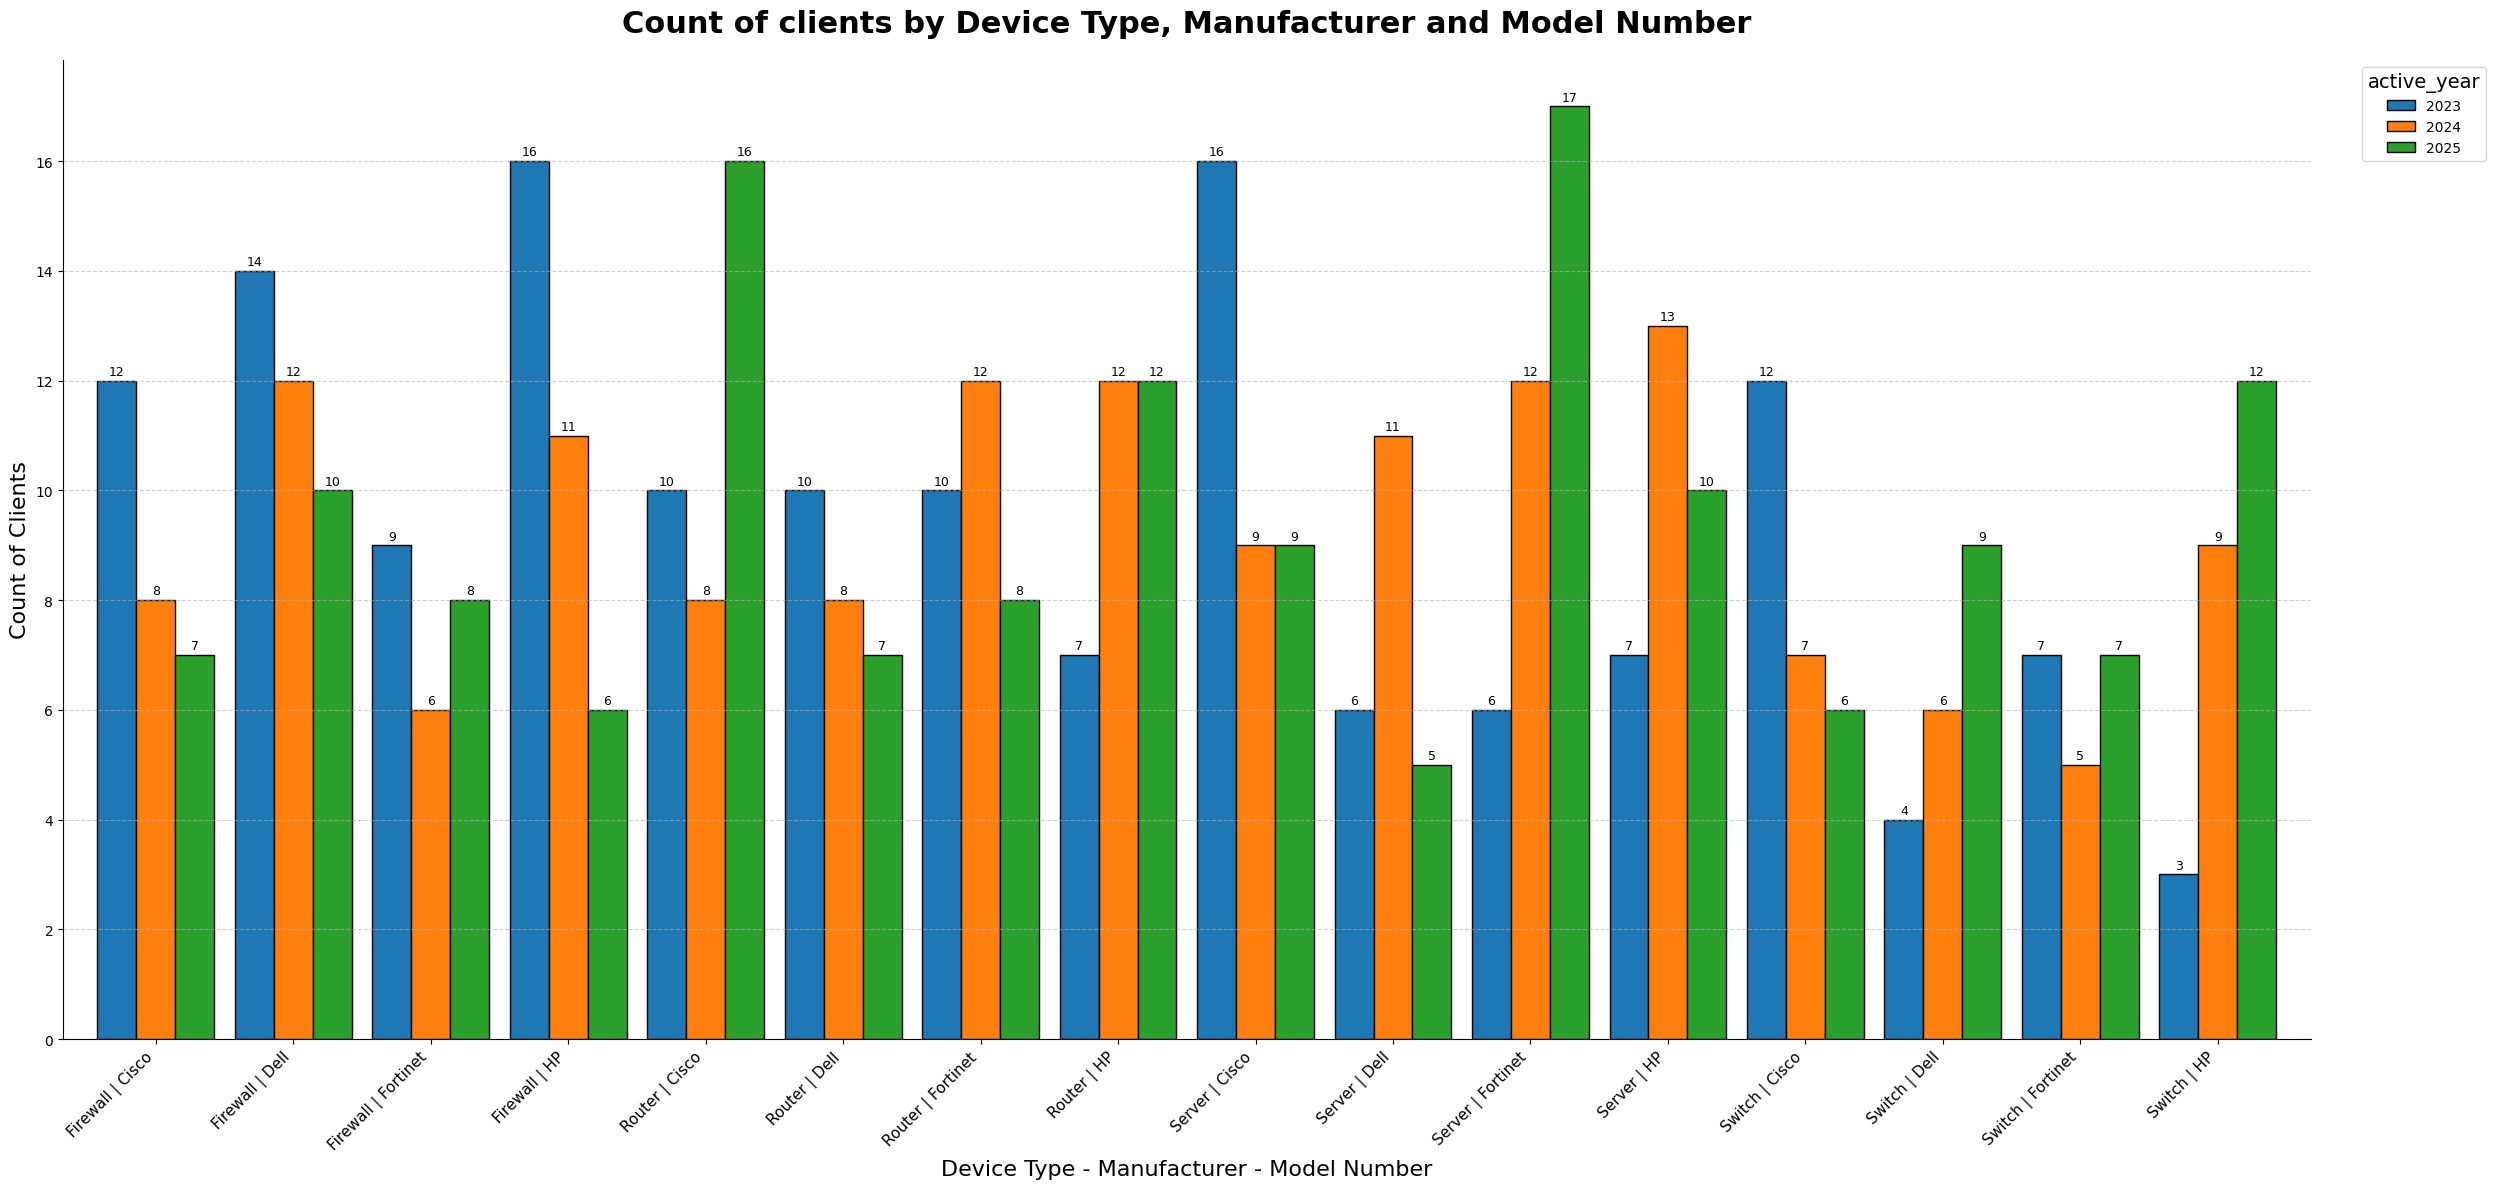

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Count of clients by Device Type, Manufacturer and Model Number'}, xlabel='Device Type - Manufacturer - Model Number', ylabel='Count of Clients'>)

In [63]:
plot_grouped_bar(
    df = assets,
    group_cols = ['device_type', 'manufacturer', 'active_year'],
    agg_col = 'client_id',
    agg_func='count',
    figsize=(25, 12),
    title='Count of clients by Device Type, Manufacturer and Model Number',
    xlabel='Device Type - Manufacturer - Model Number',
    ylabel='Count of Clients',
    rotation=45,
    annotate=True
)

In [64]:
asset_count = assets.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['asset_id'].count().reset_index()

asset_count.groupby(
    ['device_type', 'manufacturer', 'model_number']
)['asset_id'].sum().unstack()

model_number              M001  M002  M003  M004
device_type manufacturer                        
Firewall    Cisco            6     7    11     3
            Dell            14     5    12     5
            Fortinet         6     4     5     8
            HP              12     9     7     5
Router      Cisco            6     9     9    10
            Dell             4    10     8     3
            Fortinet         5     7     7    11
            HP               5    10     7     9
Server      Cisco            7    11     8     8
            Dell             5     8     4     5
            Fortinet         9     8     9     9
            HP              10    10     6     4
Switch      Cisco            8     2     6     9
            Dell             4    10     4     1
            Fortinet         5     5     7     2
            HP               7     3     7     7

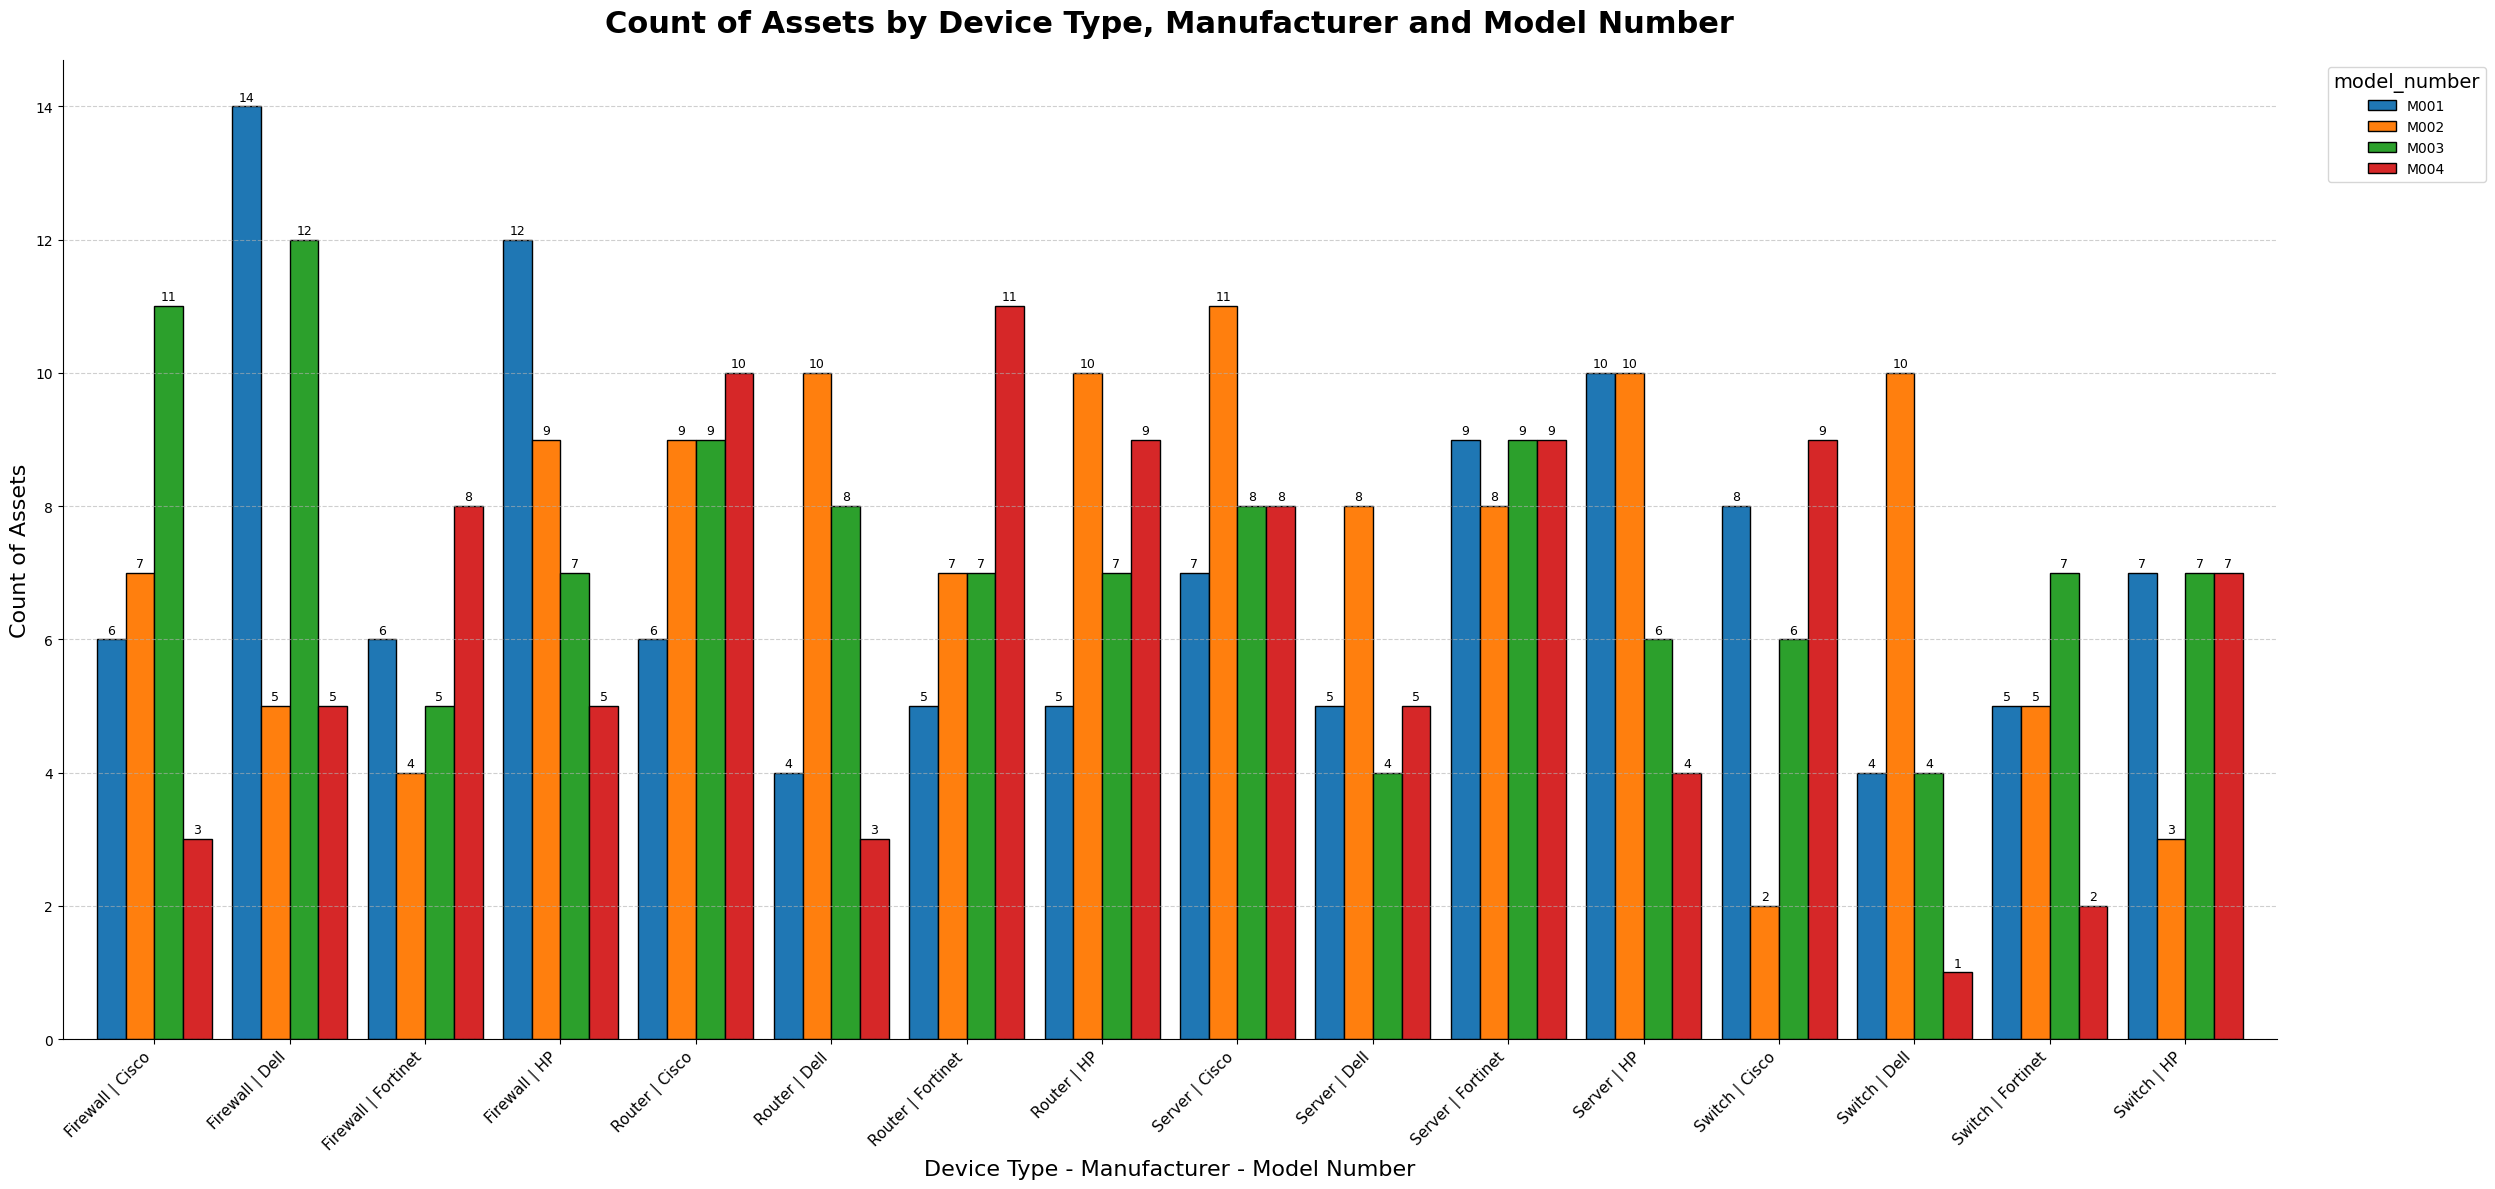

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Count of Assets by Device Type, Manufacturer and Model Number'}, xlabel='Device Type - Manufacturer - Model Number', ylabel='Count of Assets'>)

In [65]:
plot_grouped_bar(
    df = assets,
    group_cols = ['device_type', 'manufacturer', 'model_number'],
    agg_col = 'asset_id',
    agg_func='count',
    figsize=(25, 12),
    title='Count of Assets by Device Type, Manufacturer and Model Number',
    xlabel='Device Type - Manufacturer - Model Number',
    ylabel='Count of Assets',
    rotation=45,
    annotate=True
)

In [66]:
asset_count = assets.groupby(
    ['device_type', 'manufacturer', 'active_year']
)['asset_id'].count().reset_index()

asset_count.groupby(
    ['device_type', 'manufacturer', 'active_year']
)['asset_id'].sum().unstack()

active_year               2023  2024  2025
device_type manufacturer                  
Firewall    Cisco           12     8     7
            Dell            14    12    10
            Fortinet         9     6     8
            HP              16    11     6
Router      Cisco           10     8    16
            Dell            10     8     7
            Fortinet        10    12     8
            HP               7    12    12
Server      Cisco           16     9     9
            Dell             6    11     5
            Fortinet         6    12    17
            HP               7    13    10
Switch      Cisco           12     7     6
            Dell             4     6     9
            Fortinet         7     5     7
            HP               3     9    12

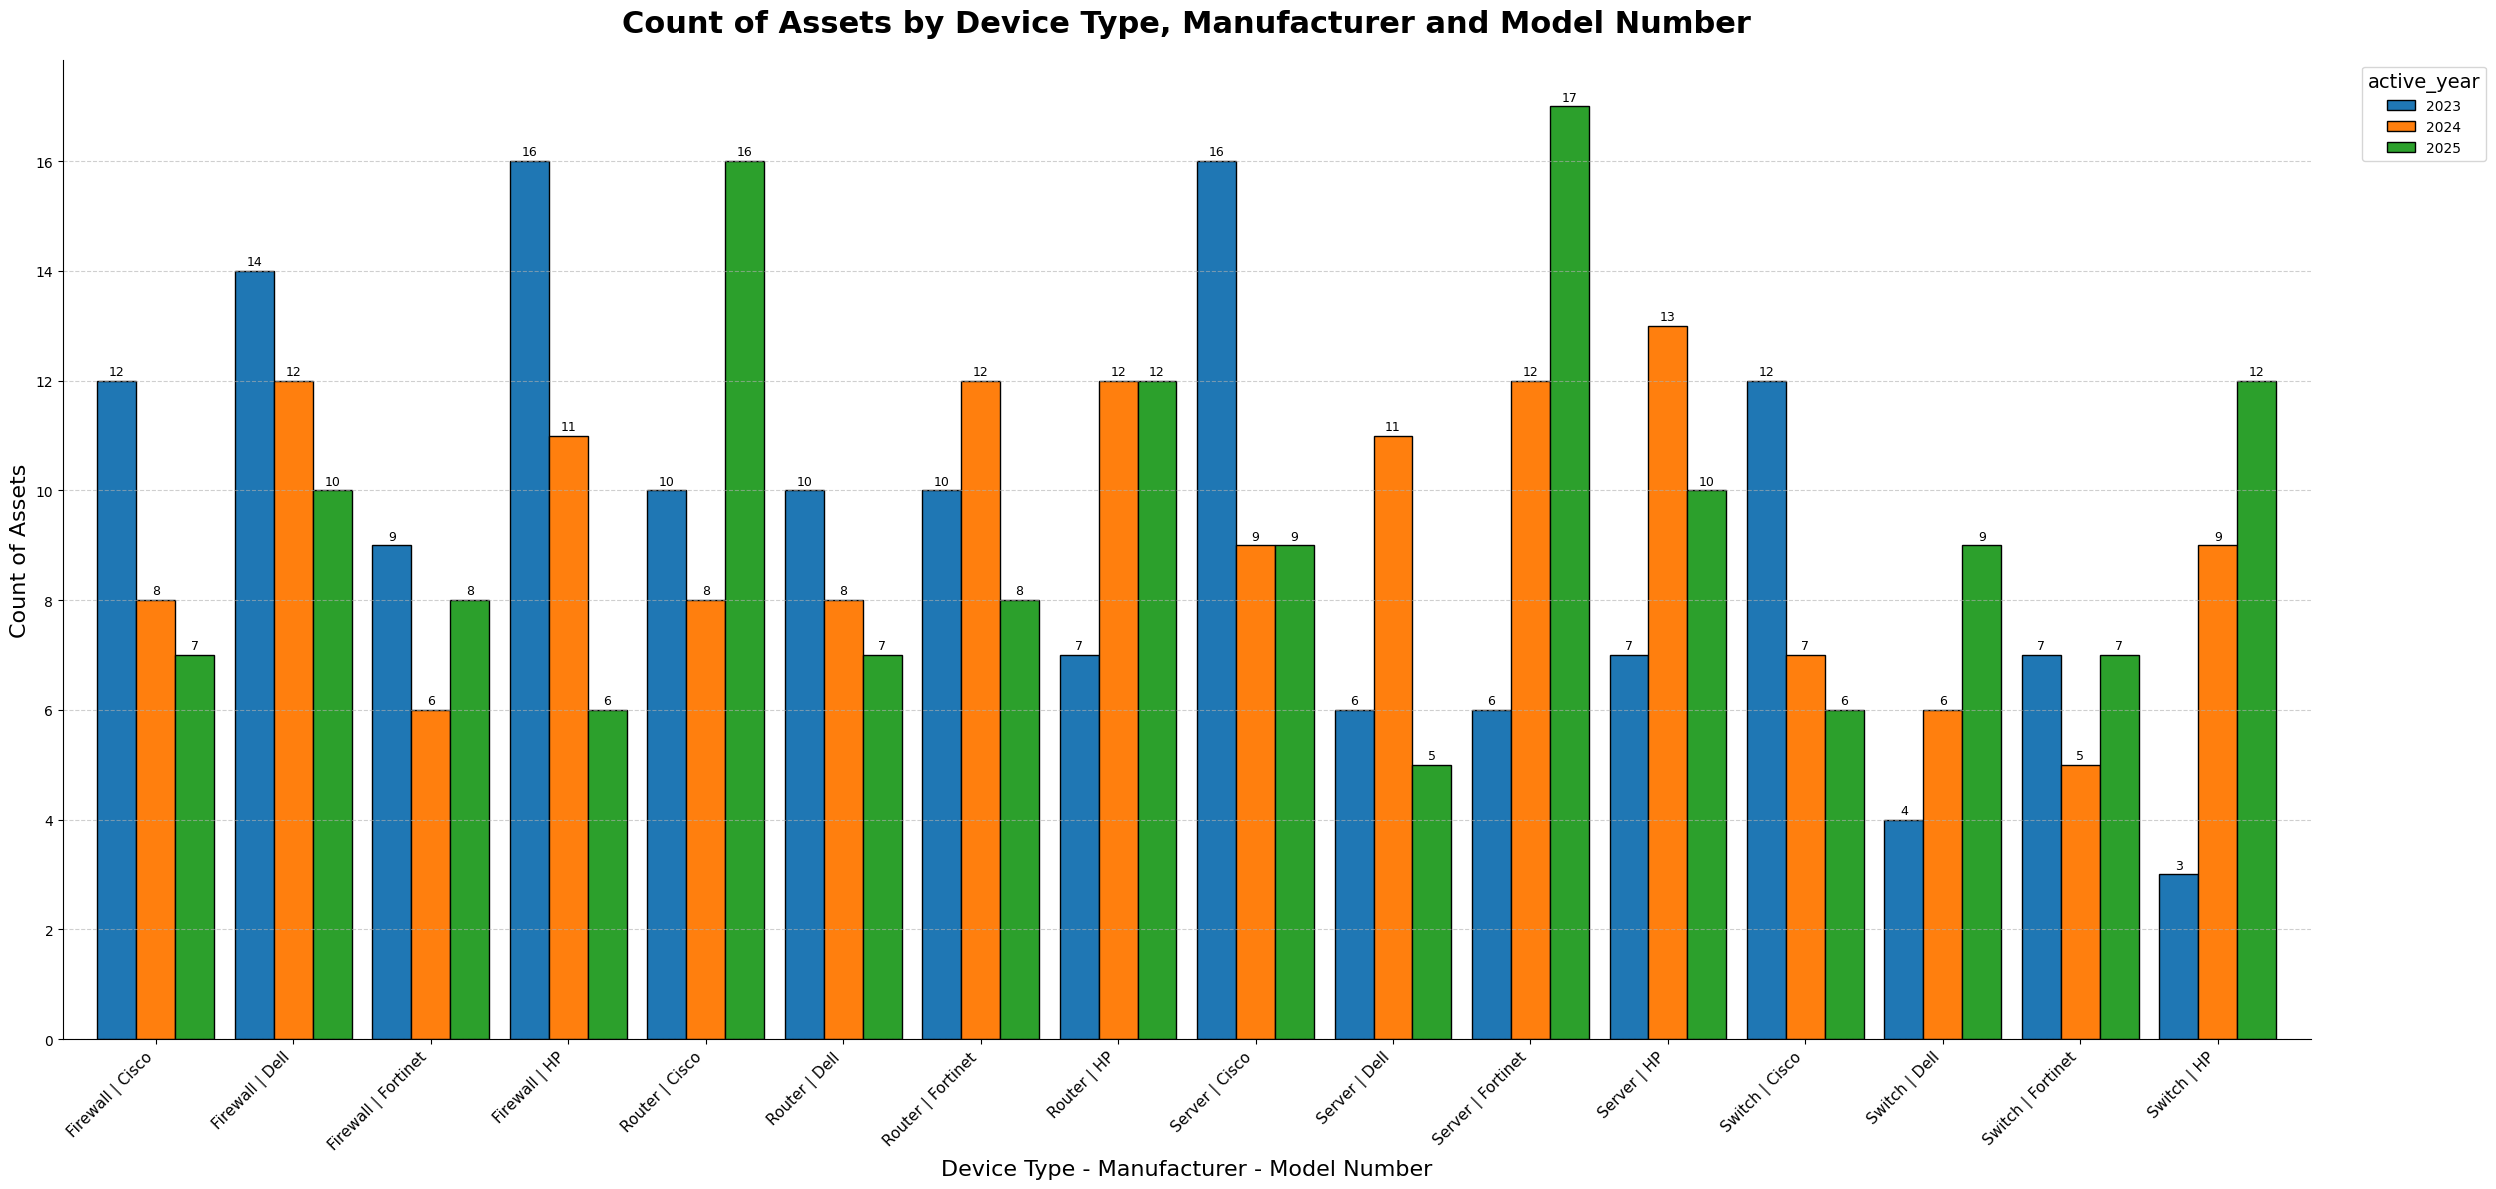

(<Figure size 2500x1200 with 1 Axes>,
 <Axes: title={'center': 'Count of Assets by Device Type, Manufacturer and Model Number'}, xlabel='Device Type - Manufacturer - Model Number', ylabel='Count of Assets'>)

In [67]:
plot_grouped_bar(
    df = assets,
    group_cols = ['device_type', 'manufacturer', 'active_year'],
    agg_col = 'asset_id',
    agg_func='count',
    figsize=(25, 12),
    title='Count of Assets by Device Type, Manufacturer and Model Number',
    xlabel='Device Type - Manufacturer - Model Number',
    ylabel='Count of Assets',
    rotation=45,
    annotate=True
)

In [68]:
assets.head()

,asset_id,device_type,manufacturer,model_number,client_id,installation_date,warranty_expiry_date,criticality_level,active_year,file_year
0,AID_053,Switch,Cisco,M001,C013,2022-11-07,2025-11-06,Medium,2023,2023
1,AID_027,Router,HP,M003,C003,2022-05-28,2025-05-27,Medium,2023,2023
2,AID_028,Router,HP,M004,C017,2022-06-21,2025-06-20,Medium,2023,2023
3,AID_031,Router,Fortinet,M003,C018,2022-11-27,2025-11-26,Medium,2023,2023
4,AID_034,Firewall,Dell,M002,C009,2022-01-04,2025-01-03,High,2023,2023


In [69]:
assets['warranty_window'] = (
    pd.to_datetime(assets['warranty_expiry_date']) -
    pd.to_datetime(assets['installation_date'])
).dt.days

asset_count = assets.groupby(
    ['device_type', 'manufacturer', 'active_year']
)['warranty_window'].mean().reset_index()

asset_count.groupby(
    ['device_type', 'manufacturer', 'active_year']
)['warranty_window'].sum().unstack()


active_year                 2023    2024    2025
device_type manufacturer                        
Firewall    Cisco         1095.0  1095.0  1095.0
            Dell          1095.0  1095.0  1095.0
            Fortinet      1095.0  1095.0  1095.0
            HP            1095.0  1095.0  1095.0
Router      Cisco         1095.0  1095.0  1095.0
            Dell          1095.0  1095.0  1095.0
            Fortinet      1095.0  1095.0  1095.0
            HP            1095.0  1095.0  1095.0
Server      Cisco         1095.0  1095.0  1095.0
            Dell          1095.0  1095.0  1095.0
            Fortinet      1095.0  1095.0  1095.0
            HP            1095.0  1095.0  1095.0
Switch      Cisco         1095.0  1095.0  1095.0
            Dell          1095.0  1095.0  1095.0
            Fortinet      1095.0  1095.0  1095.0
            HP            1095.0  1095.0  1095.0

Across Devices the Warrenty Window is set at 1095 days

### Telemetry EDA

In [70]:
telemetry.head()

,asset_id,client_id,timestamp,cpu_utilization_percent,memory_utilization_percent,disk_utilization_percent,temperature_celsius,network_latency_ms,packet_loss_percent,error_count,failure_flag,file_year
0,AID_053,C021,2023-01-01 05:00:36,81.222113,32.889289,90.954855,47.190867,107.243675,1.716625,19.0,0,2023
1,AID_053,C013,2023-01-15 07:00:55,76.506526,94.357196,57.836093,65.796344,64.770704,1.829021,20.0,0,2023
2,AID_053,C025,2023-01-29 12:00:54,64.638071,61.901368,21.172431,52.624278,78.287573,3.400515,8.0,0,2023
3,AID_053,C025,2023-02-12 20:00:39,56.193088,28.998333,70.657003,63.177061,90.775041,4.631593,3.0,0,2023
4,AID_053,C025,2023-02-26 05:00:03,91.559545,34.936086,82.476840,53.348832,43.042522,3.967257,2.0,1,2023


In [71]:
telemetry.columns

Index(['asset_id', 'client_id', 'timestamp', 'cpu_utilization_percent', 'memory_utilization_percent', 'disk_utilization_percent', 'temperature_celsius', 'network_latency_ms', 'packet_loss_percent', 'error_count', 'failure_flag', 'file_year'], dtype='object')

In [72]:
agg_metric = { 'cpu_utilization_percent':'mean'
, 'memory_utilization_percent':'mean'
, 'disk_utilization_percent':'mean'
, 'temperature_celsius':'mean'
, 'network_latency_ms':'mean'
, 'packet_loss_percent':'mean'
, 'error_count':'sum'
}
err = telemetry.groupby(['failure_flag']).agg(agg_metric).reset_index()
err['error_percentage'] = (err['error_count'] / err['error_count'].sum()) * 100
err

,failure_flag,cpu_utilization_percent,memory_utilization_percent,disk_utilization_percent,temperature_celsius,network_latency_ms,packet_loss_percent,error_count,error_percentage
0,0,61.530106,57.570209,57.414090,62.498595,79.869222,2.486028,394267.0,87.417132
1,1,89.291346,57.364632,57.497806,62.506265,79.770813,2.496802,56751.0,12.582868


In [73]:
agg_metric = { 'cpu_utilization_percent':'std'
, 'memory_utilization_percent':'std'
, 'disk_utilization_percent':'std'
, 'temperature_celsius':'std'
, 'network_latency_ms':'std'
, 'packet_loss_percent':'std'
}
err = telemetry.groupby(['failure_flag']).agg(agg_metric).reset_index()
err

,failure_flag,cpu_utilization_percent,memory_utilization_percent,disk_utilization_percent,temperature_celsius,network_latency_ms,packet_loss_percent
0,0,12.310880,21.638869,21.713199,15.844209,40.411109,1.439185
1,1,5.402488,21.680454,21.749197,15.776972,40.015465,1.441123


NOTE : The CPU Utilization for the failed cases is very tightly bound with Sample mean 89.291346 and Sample std dev 5.402488. We can use this as a Threshold calculation for failure event with higher confident and low variablity. All other metric are centered and variable about the same for both non failure and failure cases

In [74]:
agg_metric = {
    'cpu_utilization_percent': lambda x: x.quantile(0.75),
    'memory_utilization_percent': lambda x: x.quantile(0.75),
    'disk_utilization_percent': lambda x: x.quantile(0.75),
    'temperature_celsius': lambda x: x.quantile(0.75),
    'network_latency_ms': lambda x: x.quantile(0.75),
    'packet_loss_percent': lambda x: x.quantile(0.75),
}

err = telemetry.groupby(['failure_flag']).agg(agg_metric).reset_index()
err

,failure_flag,cpu_utilization_percent,memory_utilization_percent,disk_utilization_percent,temperature_celsius,network_latency_ms,packet_loss_percent
0,0,71.103069,76.410978,76.254660,76.269576,114.789880,3.719234
1,1,92.826090,76.072181,76.302806,76.244848,114.367531,3.755346


In [75]:
agg_metric = {
    'cpu_utilization_percent': lambda x: x.quantile(0.25),
    'memory_utilization_percent': lambda x: x.quantile(0.25),
    'disk_utilization_percent': lambda x: x.quantile(0.25),
    'temperature_celsius': lambda x: x.quantile(0.25),
    'network_latency_ms': lambda x: x.quantile(0.25),
    'packet_loss_percent': lambda x: x.quantile(0.25),
}

err = telemetry.groupby(['failure_flag']).agg(agg_metric).reset_index()
err

,failure_flag,cpu_utilization_percent,memory_utilization_percent,disk_utilization_percent,temperature_celsius,network_latency_ms,packet_loss_percent
0,0,53.441538,38.760855,38.570237,48.818614,44.588834,1.252675
1,1,84.736577,38.935652,38.698298,48.898283,45.750459,1.237222


## Save DeDuplicated data

In [76]:
import os
import pickle

# Create directory if it doesn't exist
os.makedirs('base_data', exist_ok=True)

# Save inventory dataframe
with open('base_data/inventory.pkl', 'wb') as f:
    pickle.dump(inventory, f)
print("Final shape of the inventory dataset is : ", inventory.shape)

# Save telemetry dataframe
with open('base_data/telemetry.pkl', 'wb') as f:
    pickle.dump(telemetry, f)
print("Final shape of the telemetry dataset is : ", telemetry.shape)

# Save assets dataframe
with open('base_data/assets.pkl', 'wb') as f:
    pickle.dump(assets, f)
print("Final shape of the assets dataset is : ", assets.shape)

# Save tickets dataframe
with open('base_data/tickets.pkl', 'wb') as f:
    pickle.dump(tickets, f)
print("Final shape of the tickets dataset is : ", tickets.shape)

Final shape of the inventory dataset is :  (192, 11)
Final shape of the telemetry dataset is :  (45109, 12)
Final shape of the assets dataset is :  (447, 11)
Final shape of the tickets dataset is :  (22283, 19)
